<a href="https://colab.research.google.com/github/vedantikanade/Data_Mining_Colabs_Assignment2/blob/main/final_matplotlib_zero_to_hero.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 matplotlib: Zero to Hero
## Ten parts, one dataset, and a plot that gets better in every one

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com)
![Python](https://img.shields.io/badge/Python-3.10+-blue.svg)
![No installs](https://img.shields.io/badge/installs-none%20needed-brightgreen.svg)
![CPU](https://img.shields.io/badge/runs%20on-CPU%20only-brightgreen.svg)
![Level](https://img.shields.io/badge/level-zero%20to%20hero-orange.svg)

---
<div style="background: linear-gradient(135deg, #4568DC 0%, #B06AB3 100%); padding: 28px; border-radius: 18px; color: white; margin: 12px 0;">


### Everyone can make a matplotlib plot. Almost nobody can fix one.

You type `plt.plot(x, y)`, a chart appears, and it is *fine*. Then someone asks why the axis starts at 12, what the orange line is, why two of the four series are invisible, and whether the reader who is red-green colourblind can use it at all — and the honest answer is that you do not know, because you never chose any of it. matplotlib chose it.

This notebook is about **choosing**. Not memorising a gallery: understanding the object model well enough that when a figure looks wrong you can name the object that is wrong and the one line that fixes it.

We use **one** dataset the whole way through — a year of daily temperatures from four weather stations, with real seasonality, a small warming trend, three sensor gaps and two impossible spikes. You will plot it badly in Part 0 and keep re-plotting it, better, for nine more parts.


</div>

<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📖 How this notebook teaches

**Every figure has a caption** underneath saying what you should actually see in it, ending with the most common way people misread that kind of chart.

**Traps are marked ⚠️ and shown as failures first.** You will see the broken plot before the explanation, because the broken plot is the thing you will recognise later in your own work.

**Improvements are shown side by side** — the same data, before and after one specific change, so you can see what that one line bought.

**Nothing here is styled for you.** We start from `rcParamsDefault` deliberately. Knowing exactly what matplotlib gives you for free is how you learn what every later part is changing.

</div>

## 🎯 What you will be able to do

1. **Name the objects** — Figure, Axes, Axis, Artist — and say which one owns the thing you want to change.
2. **Choose between the two APIs** (`plt.*` and `fig, ax = plt.subplots()`) and explain why the second is the one to write.
3. **Pick the right chart** for a comparison, a distribution, a relationship, or a time series — and say what each one hides.
4. **Control every axis**: limits, ticks, tick labels, log scales, spines, date formatting.
5. **Annotate** so a reader gets the point without your narration.
6. **Lay out multi-panel figures** that share axes and align properly.
7. **Use colour deliberately** — sequential vs diverging vs categorical, and check your figure for colourblind safety.
8. **Save output that survives** a journal, a slide, and a dark-mode screenshot.
9. **Diagnose a bad plot on sight** and name the fix.

---
## 🗺️ The Ten Parts

Each part fixes a problem the previous part's plots still have. By the end you will be able to take a default matplotlib figure and say exactly what is wrong with it and which line of code fixes it.

| Part | What it covers | |
|---|---|---|
| **0** | Why plots go wrong, and the data we use |  &larr; **you are here**
| **1** | Figure, Axes, and the two APIs |
| **2** | The core plot types, and choosing between them |
| **3** | Styling: colour, line, marker, alpha |
| **4** | Axes control: limits, ticks, scales, spines |
| **5** | Labels, legends, annotation, and text |
| **6** | Layouts: subplots, gridspec, shared axes |
| **7** | Colour done properly: colormaps and colourblind safety |
| **8** | Saving, sizing, DPI, and publication output |
| **9** | Redesign clinic: five bad plots fixed, and a capstone |


## ⚙️ Setup

Nothing to install.

In [1]:
# ============================================================
#  Setup -- no installs, no downloads, no network.
# ============================================================
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

# Deliberately DO NOT set a style yet. Part 0 shows what the raw default
# looks like, because knowing what matplotlib gives you for free is how you
# learn what every later part is actually changing.
plt.rcParams.update(plt.rcParamsDefault)

C_LINE, C_ALT, C_OK = "#2563EB", "#DC2626", "#059669"
C_WARN, C_ACC, C_GREY, C_SOFT = "#D97706", "#7C3AED", "#6B7280", "#E5E7EB"

print(f"matplotlib {matplotlib.__version__}   numpy {np.__version__}")
print(f"backend: {matplotlib.get_backend()}")


matplotlib 3.10.0   numpy 2.1.3
backend: module://matplotlib_inline.backend_inline


---

# 0️⃣ The data, and a plot that is technically correct

## Four weather stations, one year

Generated rather than downloaded, so this notebook works offline forever and
the flaws in it are reproducible. It has everything a real series has: a
seasonal cycle, a small upward trend, day-to-day noise, **three sensor gaps**,
and **two impossible readings** (a 61 °C and a −40 °C) left in on purpose.

Those flaws are not an accident of the generator. They are the reason the
default plot below is unreadable, and you will meet them again in Part 4
(axis limits), Part 5 (annotation) and Part 9 (the redesign clinic).


In [2]:
# ============================================================
#  The data -- generated, so the notebook works offline forever.
#  A year of daily readings from four weather stations, plus a
#  small table of station facts. Small enough to print, real
#  enough to have trend, seasonality, noise, outliers and gaps.
# ============================================================
import numpy as np
import pandas as pd

RNG = np.random.default_rng(11)

days = pd.date_range("2024-01-01", periods=365, freq="D")
t = np.arange(365)

STATIONS = {                       # name: (base temp, seasonal swing, noise)
    "Coastal":  (14.0,  5.0, 1.2),
    "Valley":   (17.0, 12.0, 2.1),
    "Foothill": (11.5,  9.0, 1.8),
    "Alpine":   ( 2.0, 11.0, 2.6),
}

frames = []
for name, (base, swing, noise) in STATIONS.items():
    seasonal = swing * np.sin(2 * np.pi * (t - 100) / 365)
    warming  = 0.0025 * t                      # a small real trend
    temp = base + seasonal + warming + RNG.normal(0, noise, 365)
    rain = np.clip(RNG.gamma(0.6, 4.0, 365) * (1.6 - 0.9 * np.sin(
        2 * np.pi * (t - 100) / 365)), 0, None)
    frames.append(pd.DataFrame({"date": days, "station": name,
                                "temp_c": temp, "rain_mm": rain}))

weather = pd.concat(frames, ignore_index=True)

# a few sensor faults: three short gaps and two impossible spikes
for st, lo, hi in [("Valley", 120, 127), ("Alpine", 300, 309), ("Coastal", 40, 44)]:
    m = (weather.station == st) & weather.date.between(days[lo], days[hi])
    weather.loc[m, "temp_c"] = np.nan
weather.loc[(weather.station == "Foothill") & (weather.date == days[200]), "temp_c"] = 61.0
weather.loc[(weather.station == "Valley")   & (weather.date == days[88]),  "temp_c"] = -40.0

stations = pd.DataFrame({
    "station":   list(STATIONS),
    "elevation": [12, 95, 640, 2310],
    "lat":       [36.6, 36.7, 37.2, 37.6],
    "sensors":   [3, 5, 2, 2],
})

wide = weather.pivot_table(index="date", columns="station", values="temp_c")

print(f"weather : {weather.shape[0]:,} rows x {weather.shape[1]} cols")
print(f"wide    : {wide.shape[0]} days x {wide.shape[1]} stations")
print(f"missing : {weather.temp_c.isna().sum()} temperature readings")
wide.head()


weather : 1,460 rows x 4 cols
wide    : 365 days x 4 stations
missing : 23 temperature readings


station,Alpine,Coastal,Foothill,Valley
date,,,,
2024-01-01,-8.963958,9.097643,1.525386,8.704761
2024-01-02,-9.475561,10.678627,6.192734,3.988893
2024-01-03,-7.755356,10.508381,2.725038,9.156020
2024-01-04,-6.752090,8.419605,3.060991,6.198953
2024-01-05,-12.949968,8.669142,0.537412,6.003171


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

The first five days of `wide` — one row per date, one column per station — plus the row counts and the number of missing temperature readings. This is the shape most plotting functions want: an index that becomes the x-axis, and one column per line you intend to draw.

**The common misread:** assuming the missing readings will simply be skipped. They will be — matplotlib breaks the line at a NaN — but that gap is invisible unless you know to look for it, and a reader will interpret a broken line as a real feature of the weather rather than a dead sensor.

</div>

## The plot you would write first

One line of code, four series, no arguments. It runs, it produces a chart, and
nothing about it is *wrong* — which is exactly the problem. Look at it and try
to answer: which station is which, what is the y-axis, what happened around day
200, and how much has the trend actually moved over the year.


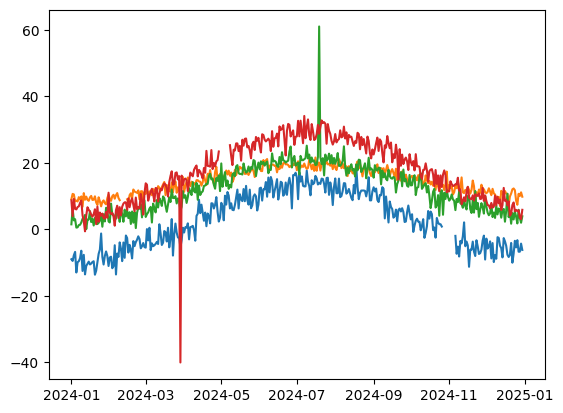

What matplotlib chose for you, without being asked:
  figure size   : [6.4 4.8]  inches
  dpi           : 100.0
  y-axis limits : (np.float64(-45.05), np.float64(66.05))
  colours       : ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
  line width    : 1.5

Every one of those is a decision. You made none of them.


In [3]:
# The default. No colours chosen, no labels, no limits, nothing.
fig, ax = plt.subplots()
ax.plot(wide.index, wide.values)
plt.show()

print("What matplotlib chose for you, without being asked:")
print(f"  figure size   : {fig.get_size_inches()}  inches")
print(f"  dpi           : {fig.get_dpi()}")
print(f"  y-axis limits : {ax.get_ylim()}")
print(f"  colours       : {[l.get_color() for l in ax.get_lines()]}")
print(f"  line width    : {ax.get_lines()[0].get_linewidth()}")
print()
print("Every one of those is a decision. You made none of them.")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Four temperature series drawn with every default matplotlib has. The seasonal cycle is visible, and that is genuinely all you can read off it. There is no legend, so the four colours are unidentifiable; no axis labels, so the units are a guess; and the y-axis has been stretched to roughly -40 to 61 by the two bad sensor readings, which compresses the entire real signal into the middle third of the figure.

The printed block underneath lists the choices matplotlib made silently — figure size, dpi, the colour cycle, line width, axis limits. Each one is something a later part of this notebook takes back.

**The common misread:** thinking this plot is a reasonable starting point that just needs decoration. It is not — the axis limits are actively lying about the data, and no amount of labelling fixes that. Part 4 is where it gets repaired.

</div>

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ The trap

`ax.plot(wide.index, wide.values)` draws four lines because `wide.values` is a 2-D array, and matplotlib quietly treats **each column as a separate series**. That is convenient until you pass an array that is accidentally transposed, at which point you get 365 lines of 4 points each, the figure takes a long time to draw, and it looks like a solid block of colour. If a plot ever renders as an unreadable smear, check the shape of what you passed before you change anything else.

</div>

### That figure has at least nine things wrong with it

Here is the list. Each one is a part of this notebook.

| # | What is wrong | Fixed in |
|---|---|---|
| 1 | You cannot tell which line is which station | Part 5 (legend) |
| 2 | No axis labels, no units | Part 5 |
| 3 | Two bad sensor readings own the y-axis | Part 4 (limits) |
| 4 | Default colours were not chosen for these four series | Part 3, Part 7 |
| 5 | Four overlapping lines is the wrong chart for four groups | Part 2, Part 6 |
| 6 | Nothing marks the sensor gaps | Part 5 (annotation) |
| 7 | The x-axis ticks are unformatted dates | Part 4 |
| 8 | The figure is the default 6.4 × 4.8 inches regardless of use | Part 8 |
| 9 | Nobody checked it in greyscale or for colourblind readers | Part 7 |

We will work through them in that order, and Part 9 puts the whole list back
together on five deliberately terrible plots.

---


# 1️⃣ Figure, Axes, and the two APIs

Part 0 ended with a figure that has nine things wrong with it. Before you can
fix any of them you need to know **which object owns the broken thing**.

That is what this part is: the object model. It is the least glamorous section
of the notebook and the one everything else stands on. Once you can look at a
chart and say *"that is the Axes' y-Axis, and the thing I want is a method on
it"*, the matplotlib documentation stops being a maze and becomes a lookup
table.

## The four nouns

| Object | What it is | You usually have | Owns |
|---|---|---|---|
| **Figure** | the whole canvas — the thing that gets saved to a file | one | size, dpi, background, the suptitle, all the Axes |
| **Axes** | one plotting box, with its own data area and coordinate system | one *per panel* | the data limits, the title, the legend, everything drawn inside it |
| **Axis** | the x or the y direction of one Axes: its scale, ticks and tick labels | two per Axes | tick locations, tick formatting, the axis label |
| **Artist** | anything that gets drawn: a line, a patch, a piece of text, a tick | hundreds | its own colour, width, visibility, z-order |

Two traps in that table:

- **Axes is not the plural of Axis.** An `Axes` is a *panel*; an `Axis` is a
  *direction*. Every Axes contains exactly two Axis objects (`ax.xaxis`,
  `ax.yaxis`). This naming is the single most common source of confusion in
  matplotlib and it never gets less annoying.
- **Everything is an Artist**, including the Figure and the Axes. That is why
  the same handful of verbs — `set_color`, `set_visible`, `set_zorder` — work
  on almost anything you can point at.

## The anatomy diagram

Rather than describe the layout, here is a real plot of the Valley station's
first sixty days that **labels its own parts**. Every label below is attached
with an arrow to the thing it names, and the dashed violet border is the Figure
itself.


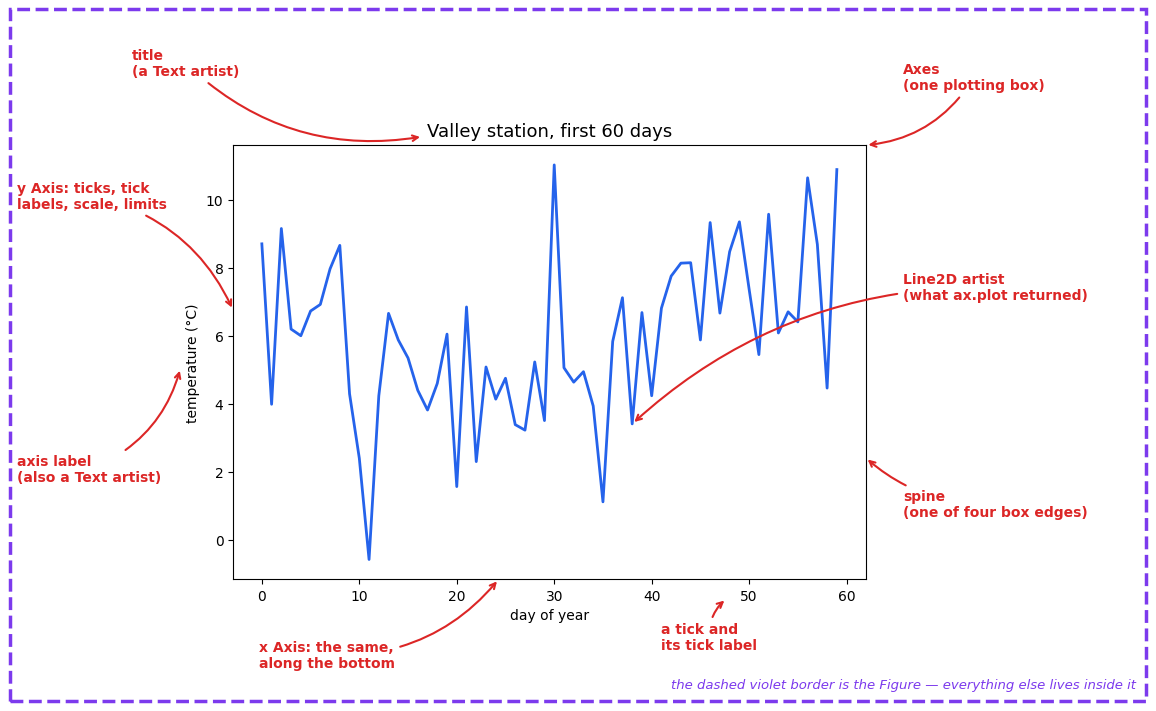

fig.axes            -> [<Axes: title={'center': 'Valley station, first 60 days'}, xlabel='day of year', ylabel='temperature (°C)'>]
ax.xaxis, ax.yaxis  -> XAxis YAxis
ax.spines           -> ['left', 'right', 'bottom', 'top']

Artists owned by this one Axes: 19
     8 x Annotation
     4 x Spine
     3 x Text
     1 x Line2D
     1 x XAxis
     1 x YAxis
     1 x Rectangle
(the Annotations are the labels we just added -- they are Artists too)


In [4]:
from matplotlib.patches import Rectangle

sub = wide["Valley"].iloc[:60]          # one clean stretch, no sensor gap
day = np.arange(len(sub))

fig = plt.figure(figsize=(11.5, 7.0))
fig.patch.set_facecolor("white")

# Draw the Figure's own rectangle so you can see where it ends.
fig.add_artist(Rectangle((0.006, 0.006), 0.988, 0.988, transform=fig.transFigure,
                         fill=False, ec=C_ACC, lw=2.5, ls="--", zorder=0))

# add_axes puts the Axes at an explicit [left, bottom, width, height] in
# figure coordinates, which leaves us wide margins to write in.
ax = fig.add_axes([0.20, 0.18, 0.55, 0.62])
line, = ax.plot(day, sub.values, color=C_LINE, lw=2.0)
ax.set_title("Valley station, first 60 days", fontsize=13)
ax.set_xlabel("day of year")
ax.set_ylabel("temperature (°C)")


def tag(text, xy, xycoords, xytext, rad=0.2):
    """Point an arrow at one part of the figure and name it."""
    ax.annotate(text, xy=xy, xycoords=xycoords,
                xytext=xytext, textcoords="figure fraction",
                ha="left", va="center", fontsize=10, fontweight="bold",
                color=C_ALT,
                arrowprops=dict(arrowstyle="->", lw=1.5, color=C_ALT,
                                connectionstyle="arc3,rad=%s" % rad))


tag("Axes\n(one plotting box)",         (1.00,  1.00), "axes fraction",   (0.785, 0.905), rad=-0.25)
tag("Line2D artist\n(what ax.plot returned)", (38, sub.values[38]), "data", (0.785, 0.605))
tag("spine\n(one of four box edges)",   (1.00,  0.28), "axes fraction",   (0.785, 0.295), rad=-0.20)
tag("title\n(a Text artist)",           (0.30,  1.02), "axes fraction",   (0.115, 0.925), rad=0.25)
tag("y Axis: ticks, tick\nlabels, scale, limits", (0.00, 0.62), "axes fraction", (0.015, 0.735), rad=-0.25)
tag("axis label\n(also a Text artist)", (0.157, 0.49), "figure fraction", (0.015, 0.345), rad=0.25)
tag("x Axis: the same,\nalong the bottom", (0.42, 0.00), "axes fraction", (0.225, 0.080), rad=0.25)
tag("a tick and\nits tick label",       (0.78, -0.045), "axes fraction",  (0.575, 0.105), rad=-0.25)

fig.text(0.985, 0.020,
         "the dashed violet border is the Figure — everything else lives inside it",
         ha="right", va="bottom", fontsize=9.5, color=C_ACC, style="italic")
plt.show()

from collections import Counter

print("fig.axes            ->", fig.axes)
print("ax.xaxis, ax.yaxis  ->", type(ax.xaxis).__name__, type(ax.yaxis).__name__)
print("ax.spines           ->", list(ax.spines))
print()
print("Artists owned by this one Axes:", len(ax.get_children()))
for kind, n in Counter(type(c).__name__ for c in ax.get_children()).most_common():
    print(f"   {n:3d} x {kind}")
print("(the Annotations are the labels we just added -- they are Artists too)")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

One Axes inside one Figure, with its parts labelled by arrows drawn on the figure itself. Read it once slowly: the **Figure** is the dashed border, the **Axes** is the white box with the data in it, the two **Axis** objects are the tick-bearing edges on the left and the bottom, and the blue line, the title, the axis labels and every individual tick are **Artists**.

The printed block underneath is the same statement in code: `fig.axes` is a list containing exactly one Axes, `ax.xaxis` and `ax.yaxis` are real objects with their own types, `ax.spines` names the four box edges individually, and the tally shows how many Artists this one modest panel is actually made of — including the labels we added, because those are Artists too.

**The common misread:** taking the labels for decorations on a picture of matplotlib. They are not — this is a live plot annotating itself, and every arrow was positioned in either data coordinates, axes-fraction coordinates or figure-fraction coordinates. Those three coordinate systems are what Part 5 uses to put annotations exactly where you want them.

</div>

## The two APIs

matplotlib gives you two ways to say the same thing, and essentially every
confusing StackOverflow answer you have ever read is confusing because it mixes
them.

**The implicit (pyplot, MATLAB-style) API.** You never name an object.
`plt.plot(...)` means *draw on the current Axes of the current Figure*, and if
there is no current Figure matplotlib silently makes one.

**The explicit (object-oriented) API.** `fig, ax = plt.subplots()` hands you
the two objects, and every subsequent call has a receiver: `ax.plot(...)`,
`ax.set_title(...)`, `fig.savefig(...)`.

Here is the same plot both ways.


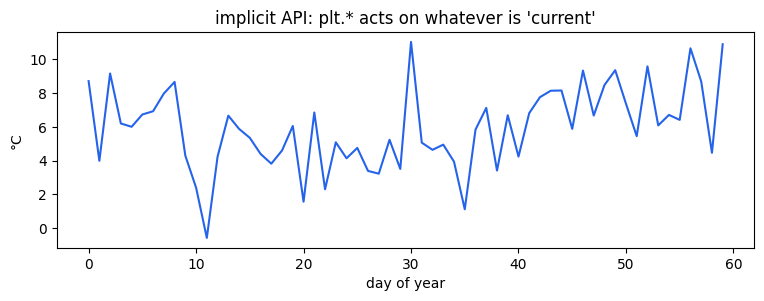

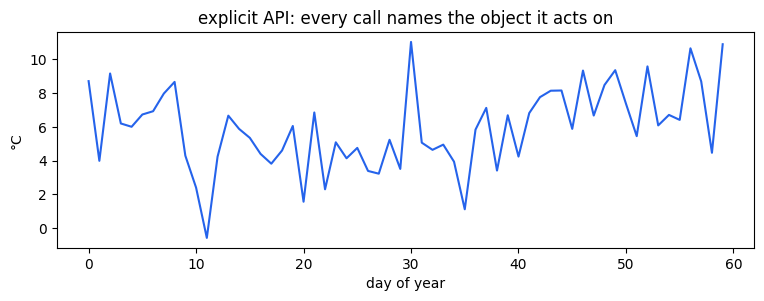

The translation is almost mechanical:

   plt.plot(x, y)      ->   ax.plot(x, y)
   plt.title(s)        ->   ax.set_title(s)
   plt.xlabel(s)       ->   ax.set_xlabel(s)
   plt.ylim(a, b)      ->   ax.set_ylim(a, b)
   plt.xticks(v)       ->   ax.set_xticks(v)
   plt.legend()        ->   ax.legend()
   plt.savefig(p)      ->   fig.savefig(p)   # note: fig, not ax

Mostly it is a 'set_' prefix. savefig is the exception: it belongs to the Figure.


In [5]:
day = np.arange(60)
valley = wide["Valley"].iloc[:60].values

# ---- API 1: implicit. Nothing is named. Every call means "the current one".
plt.figure(figsize=(9, 2.8))
plt.plot(day, valley, color=C_LINE)
plt.title("implicit API: plt.* acts on whatever is 'current'")
plt.ylabel("°C")
plt.xlabel("day of year")
plt.show()

# ---- API 2: explicit. The same picture, with the objects in hand.
fig, ax = plt.subplots(figsize=(9, 2.8))
ax.plot(day, valley, color=C_LINE)
ax.set_title("explicit API: every call names the object it acts on")
ax.set_ylabel("°C")
ax.set_xlabel("day of year")
plt.show()

print("The translation is almost mechanical:\n")
for a, b in [("plt.plot(x, y)",  "ax.plot(x, y)"),
             ("plt.title(s)",    "ax.set_title(s)"),
             ("plt.xlabel(s)",   "ax.set_xlabel(s)"),
             ("plt.ylim(a, b)",  "ax.set_ylim(a, b)"),
             ("plt.xticks(v)",   "ax.set_xticks(v)"),
             ("plt.legend()",    "ax.legend()"),
             ("plt.savefig(p)",  "fig.savefig(p)   # note: fig, not ax")]:
    print(f"   {a:18s}  ->   {b}")
print("\nMostly it is a 'set_' prefix. savefig is the exception: it belongs to the Figure.")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Two visually identical panels. That is the point — for a single plot the implicit API is genuinely shorter, and pretending otherwise would be dishonest. The printed table shows the translation between them, which is almost always just adding a `set_` prefix.

The one asymmetry worth memorising is the last row: `plt.savefig` becomes `fig.savefig`, not `ax.savefig`, because saving is something you do to a whole canvas, not to one panel.

**The common misread:** concluding from this that the two APIs are interchangeable. They are, right up to the moment a second Figure exists — which is the next cell, and is where the implicit API stops being shorthand and starts being a bug.

</div>

### What "current" actually means

`plt` keeps a module-level pointer to the current Figure and the current Axes.
`plt.gcf()` and `plt.gca()` return them ("get current figure", "get current
axes"). Creating a figure moves that pointer. So does clicking one in an
interactive window. So does a function you called three cells ago.

Below we build two figures and then add a horizontal reference line "to the
first one". Watch where it lands.


plt.gcf() is fig_a ? False
plt.gcf() is fig_b ? True
plt.gca() is ax_a  ? False
plt.gca() is ax_b  ? True

lines on ax_a: 1    lines on ax_b: 2


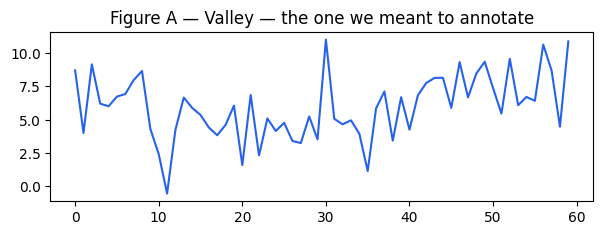

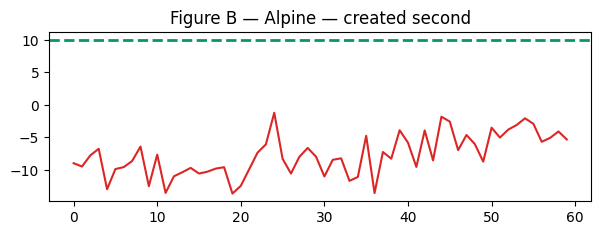

In [6]:
alpine = wide["Alpine"].iloc[:60].values

fig_a, ax_a = plt.subplots(figsize=(7, 2.2))
ax_a.plot(day, valley, color=C_LINE)
ax_a.set_title("Figure A — Valley — the one we meant to annotate")

fig_b, ax_b = plt.subplots(figsize=(7, 2.2))
ax_b.plot(day, alpine, color=C_ALT)
ax_b.set_title("Figure B — Alpine — created second")

# We want a reference line on Figure A. We wrote it the pyplot way.
plt.axhline(10.0, color=C_OK, lw=2, ls="--")

print("plt.gcf() is fig_a ?", plt.gcf() is fig_a)
print("plt.gcf() is fig_b ?", plt.gcf() is fig_b)
print("plt.gca() is ax_a  ?", plt.gca() is ax_a)
print("plt.gca() is ax_b  ?", plt.gca() is ax_b)
print()
print("lines on ax_a:", len(ax_a.lines), "   lines on ax_b:", len(ax_b.lines))
plt.show()


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Two figures and one reference line, on the wrong one of them. Figure A (blue, Valley) is exactly as we drew it. Figure B (red, Alpine) has gained a green dashed rule, and its y-axis has stretched upward to make room for a value no Alpine reading comes anywhere near — which is why the Alpine curve is now squashed into the lower part of its panel.

The four printed `is` checks name the culprit, and the two line counts say the same thing in numbers: one Axes gained an artist, and it was not the one we were thinking about.

**The common misread:** blaming the ordering of the code. Moving the `plt.axhline` call up above `fig_b` would fix this one case and teach you nothing — the pointer would still be invisible, and the next person to insert a figure above yours would break it again.

</div>

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ The trap

**The failure, above.** Nothing raised and nothing warned. `plt.axhline` resolved to `ax_b` because creating `fig_b` moved the current-figure pointer, and every `plt.*` drawing call follows that pointer.

This is the whole case against the implicit API. It is not that `plt.*` is bad style — it is that **`plt.*` silently resolves to whatever was created most recently**, and "most recently" is a property of the entire session, not of the code you are looking at. In a notebook, where cells get re-run out of order, that pointer is genuinely unpredictable.

The fix is not `plt.figure(fig_a.number)` to switch back. The fix is to stop relying on a pointer you cannot see: name the Axes and call the method on it, as the next cell does.

</div>

lines on ax_a: 2    lines on ax_b: 2
no ambiguity — we never asked matplotlib to guess.


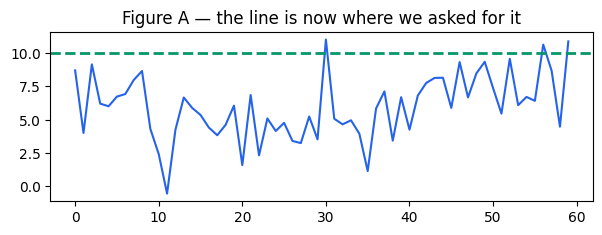

In [7]:
# The explicit version cannot land on the wrong object, because there is no
# "current" anything involved.
ax_a.axhline(10.0, color=C_OK, lw=2, ls="--")
ax_a.set_title("Figure A — the line is now where we asked for it")

print("lines on ax_a:", len(ax_a.lines), "   lines on ax_b:", len(ax_b.lines))
print("no ambiguity — we never asked matplotlib to guess.")

fig_a        # naming a Figure is also how you re-display it later


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Figure A redisplayed, with the reference line on it this time. The line counts printed above confirm it: one Axes gained an artist, the other did not.

The last line of the cell is worth noticing on its own. Because we kept `fig_a`, we could redraw a figure created in an *earlier cell* just by evaluating its name. With the implicit API that figure would have been unreachable the moment the next one was created.

**The common misread:** thinking the explicit API is about tidiness. It is about **reachability** — keeping a handle is what makes a figure editable, inspectable and re-displayable after the fact.

</div>

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ The rule this notebook follows

Start every figure with `fig, ax = plt.subplots(...)` and use `ax.` and `fig.` from then on. Keep `plt.` for the three things that are genuinely module-level: `plt.subplots`, `plt.show`, and `plt.close`.

This is not a purity argument. Single-panel throwaway plots in a REPL are fine with `plt.plot`, and everyone writes them. But the moment a figure has two panels, gets built inside a function, or is created in one cell and touched in another, the implicit API costs more than it saves.

</div>

## Everything is an object you can interrogate

The reason the explicit API pays off is that matplotlib's plotting functions
**return the Artists they created**. If you keep them, you can change the
drawing later without redrawing anything.


ax.plot returned a list of length 2
its contents: ['Line2D', 'Line2D']

BEFORE we touch anything, matplotlib had already chosen:
   raw form of line 1's colour: #1f77b4
   line 1 colour  #1f77b4   width 1.5   label '_child0'
   line 2 colour  #ff7f0e   width 1.5   label '_child1'
   x-limits       (np.float64(-2.95), np.float64(61.95))
   y-limits       (np.float64(-14.85349622475082), np.float64(12.257327249540872))
   figure size    [9.5 3.4] inches at 100.0 dpi
   ax.get_lines() <a list of 2 Line2D objects>

AFTER:
   line 1 colour  #2563eb   label 'Valley'
   line 2 colour  #dc2626   label 'Alpine'   alpha 0.7


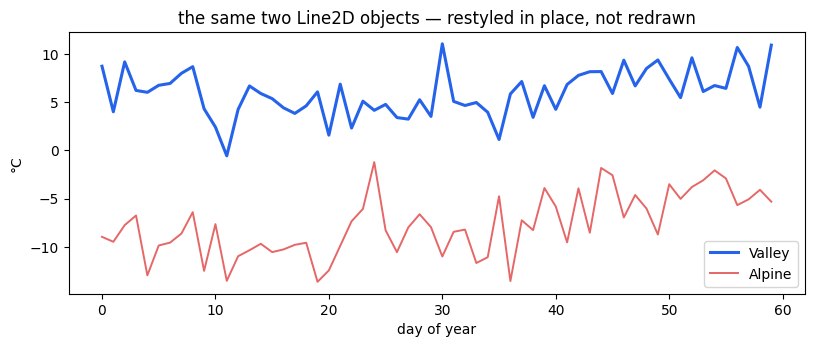

In [8]:
fig, ax = plt.subplots(figsize=(9.5, 3.4))

returned = ax.plot(day, valley, day, alpine)   # two series in one call
print("ax.plot returned a", type(returned).__name__, "of length", len(returned))
print("its contents:", [type(o).__name__ for o in returned])
print()

first, second = returned

# get_color() hands back matplotlib's internal form, which for a cycled colour
# is a tuple of floats. to_hex just makes it readable here; nothing is changed.
from matplotlib.colors import to_hex

print("BEFORE we touch anything, matplotlib had already chosen:")
print(f"   raw form of line 1's colour: {first.get_color()}")
print(f"   line 1 colour  {to_hex(first.get_color())}   width {first.get_linewidth()}   label {first.get_label()!r}")
print(f"   line 2 colour  {to_hex(second.get_color())}   width {second.get_linewidth()}   label {second.get_label()!r}")
print(f"   x-limits       {ax.get_xlim()}")
print(f"   y-limits       {ax.get_ylim()}")
print(f"   figure size    {fig.get_size_inches()} inches at {fig.get_dpi()} dpi")
print(f"   ax.get_lines() {ax.get_lines()}")
print()

# Now change the drawing through the handles. Nothing is re-plotted.
first.set_color(C_LINE);  first.set_linewidth(2.2);  first.set_label("Valley")
second.set_color(C_ALT);  second.set_linewidth(1.4); second.set_alpha(0.7)
second.set_label("Alpine")
ax.set_title("the same two Line2D objects — restyled in place, not redrawn")
ax.set_ylabel("°C")
ax.set_xlabel("day of year")
ax.legend()

print("AFTER:")
print(f"   line 1 colour  {to_hex(first.get_color())}   label {first.get_label()!r}")
print(f"   line 2 colour  {to_hex(second.get_color())}   label {second.get_label()!r}   alpha {second.get_alpha()}")
plt.show()


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Two restyled lines with a working legend — and, more importantly, the printed before/after showing that nothing was re-plotted. The same two `Line2D` objects that `ax.plot` created were mutated in place.

Note where the legend text came from: `set_label` on each line, not a list passed to `ax.legend()`. That is the durable way to do it, because the label then lives on the artist instead of depending on drawing order.

**The common misread:** assuming you must get the styling right inside the `plot()` call. You do not. Every keyword argument to `plot` has a matching `set_*` method, which is what makes it possible to write one function that draws a plot and a *separate* function that themes it.

</div>

AttributeError: 'list' object has no attribute 'set_color'
what ax.plot actually returned: list of length 1


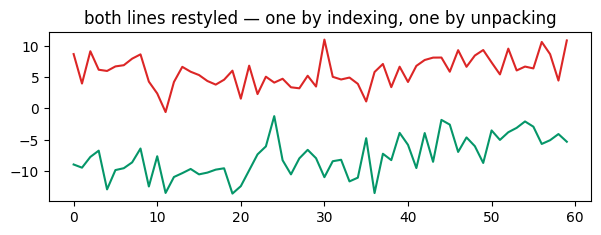

In [9]:
# The failure, first.
fig, ax = plt.subplots(figsize=(7, 2.2))

line = ax.plot(day, valley)          # looks singular. is not.
try:
    line.set_color(C_ALT)
except AttributeError as err:
    print("AttributeError:", err)

print("what ax.plot actually returned:", type(line).__name__,
      "of length", len(line))

# Two correct ways:
line[0].set_color(C_ALT)             # index it ...
(only_line,) = ax.plot(day, alpine)  # ... or unpack it at the call site
only_line.set_color(C_OK)
ax.set_title("both lines restyled — one by indexing, one by unpacking")
plt.show()


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

One panel with two lines: the Valley series recoloured red by *indexing* into the list that `ax.plot` returned, and the Alpine series recoloured green by *unpacking* it at the call site. Both routes reach the same kind of object.

Above the figure is the `AttributeError`, caught and printed rather than allowed to stop the notebook, followed by the actual type and length of what `ax.plot` handed back.

**The common misread:** reading that error as "my line is broken". The line is fine — it drew, and you can see it. The name `line` is simply bound to a *container*, and the message says so if you read it literally: a list has no `set_color`.

</div>

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ The trap

`ax.plot()` **always returns a list**, even when it drew exactly one line, because a single call is allowed to draw many. So `line = ax.plot(x, y)` binds a list, and `line.set_color(...)` raises the `AttributeError` printed above.

The idiomatic fix is the trailing comma — `line, = ax.plot(x, y)` — which unpacks the one-element list at the call site. It looks like a typo. It is not, and you will see it in every matplotlib codebase.

Not every plotting function behaves this way, which is the deeper trap: `ax.scatter` returns a single `PathCollection`, `ax.bar` returns a `BarContainer`, `ax.hist` returns a *tuple* of three things, and `ax.imshow` returns one `AxesImage`. When you are unsure, print the type before you assume it.

</div>

## More than one Axes: `plt.subplots(rows, cols)`

`plt.subplots` takes a grid shape and returns the Figure plus **an array of
Axes**. The shape of that array depends on the arguments, which trips people up
more often than it should — so the cell below prints all three cases before it
draws anything.


   subplots(1, 1)  ->  Axes      shape -- not an array --
   subplots(1, 3)  ->  ndarray   shape (3,)
   subplots(2, 2)  ->  ndarray   shape (2, 2)

A single Axes gets squeezed down to a bare object, and a single row to a
1-D array. Pass squeeze=False to always get a 2-D array, which is what you
want inside a function that must not care how many panels it was given.

axes is a ndarray with shape (2, 2)
axes[0, 1] is list(axes.flat)[1] ? True
axes.flat walks the grid row by row: ['Alpine', 'Coastal', 'Foothill', 'Valley']


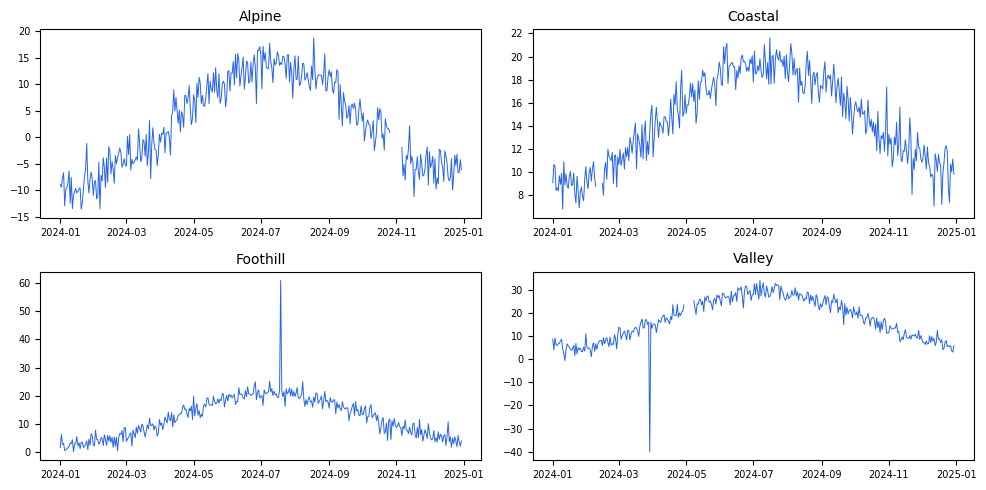

In [10]:
# What plt.subplots hands back, for three different grid shapes.
probe = {}
for label, shape in [("subplots(1, 1)", (1, 1)),
                     ("subplots(1, 3)", (1, 3)),
                     ("subplots(2, 2)", (2, 2))]:
    _f, _a = plt.subplots(*shape)
    probe[label] = (type(_a).__name__, getattr(_a, "shape", "-- not an array --"))
    plt.close(_f)                      # throwaway: close it so it is not displayed

for label, (kind, shp) in probe.items():
    print(f"   {label}  ->  {kind:8s}  shape {shp}")
print("\nA single Axes gets squeezed down to a bare object, and a single row to a")
print("1-D array. Pass squeeze=False to always get a 2-D array, which is what you")
print("want inside a function that must not care how many panels it was given.\n")

# The real 2x2 grid, one station per panel.
fig, axes = plt.subplots(2, 2, figsize=(10, 5))
print("axes is a", type(axes).__name__, "with shape", axes.shape)

for ax_, name in zip(axes.flat, wide.columns):
    ax_.plot(wide.index, wide[name], lw=0.7, color=C_LINE)
    ax_.set_title(name, fontsize=10)
    ax_.tick_params(labelsize=7)

print("axes[0, 1] is list(axes.flat)[1] ?", axes[0, 1] is list(axes.flat)[1])
print("axes.flat walks the grid row by row:", [a.get_title() for a in axes.flat])

fig.tight_layout()
plt.show()


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Four panels, one station each, and the printed shapes that explain how to reach them. `axes[0, 1]` and `axes.flat` are two views of the same objects — the identity check above proves it — and `axes.flat` is what you want whenever you are zipping panels against a list of things to draw.

Splitting the series apart already buys something the Part 0 overlay could not: the two impossible sensor readings are now unmissable — one spike in the Foothill panel, one in the Valley panel — because each is confined to the station it belongs to instead of distorting all four at once.

**The common misread:** comparing the four panels by eye as though they shared a scale. They do not. Each Axes computed its own limits from its own data, so the Valley panel's range is set by its bad reading and Coastal's is not — and the curves look alike mainly because each one was stretched to fill its own box. Part 6 fixes that with `sharey`.

</div>

## What `plt.show()` actually does

`plt.show()` does not "print the plot". It hands the open figures to the
**backend** and asks it to display them — and the three environments you will
meet do genuinely different things with that request:

- **A script with a GUI backend** — `show()` opens a window and *blocks* until
  you close it. This is why a script that loops over `show()` calls feels
  broken.
- **A notebook with the inline backend** — each cell's figures are rendered
  into the output area and then closed. `show()` is largely redundant here,
  which is why so much notebook code omits it.
- **A non-interactive backend such as Agg** — there is no window to open, so
  `show()` does nothing and emits a `UserWarning`. That is the normal state on
  a server, and it is why `fig.savefig` — not `show` — is the correct verb in
  any automated pipeline.

Part 0 printed which backend you are on. The cell below shows the consequence.


backend                : module://matplotlib_inline.backend_inline
interactive mode       : False
open figure numbers    : []
after creating one more: [1]


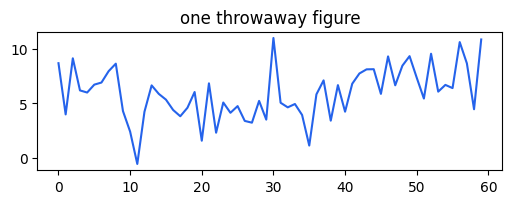

after plt.show()       : []
after plt.close('all') : []   <- always empty


In [11]:
print("backend                :", matplotlib.get_backend())
print("interactive mode       :", plt.isinteractive())
print("open figure numbers    :", plt.get_fignums())

fig, ax = plt.subplots(figsize=(6, 1.8))
ax.plot(day, valley, color=C_LINE)
ax.set_title("one throwaway figure")
print("after creating one more:", plt.get_fignums())

plt.show()
print("after plt.show()       :", plt.get_fignums())

plt.close("all")
print("after plt.close('all') :", plt.get_fignums(), "  <- always empty")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

A live trace of the figure registry. `plt.get_fignums()` lists every figure `plt` is still holding open, and the three readings around `plt.show()` tell you which of the three worlds above you are in: if the list empties, the inline backend rendered the figure and closed it; if it does not, `show()` was a no-op on a non-interactive backend.

`plt.close("all")` is the only line guaranteed to empty that list everywhere. In a long notebook, or a loop that generates a figure per iteration, the registry is a real memory leak — matplotlib eventually warns you that too many figures are open.

**The common misread:** believing `plt.show()` is what draws the plot. The drawing already happened; `show()` only asks the backend to put it on a screen. On a server there is no screen, and the figure is still perfectly real — `fig.savefig(...)` writes it out regardless, which is Part 8.

</div>

## Back to Part 0's figure, with every object named

Same data, same defaults, same four lines — but this time nothing is anonymous.
Every line has a handle and a label, and the Figure and the Axes are in
variables. Nothing about the *appearance* is fixed yet; that starts in Part 2.
What has changed is that the figure is now **addressable**.


the handles we kept:
   Alpine    colour #1f77b4   width 1.0
   Coastal   colour #ff7f0e   width 1.0
   Foothill  colour #2ca02c   width 1.0
   Valley    colour #d62728   width 1.0

still chosen for us, and still wrong:
   y-limits    -45.0 to 66.0 °C   <- the two bad sensor readings own this
   real range  -40.0 to 61.0 °C, of which the
               honest readings only span -13.6 to 33.6
   figure size [10.  4.] inches
   colours     ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

But every one of those is now reachable through a name, which is the
only thing Part 1 was ever trying to buy you.


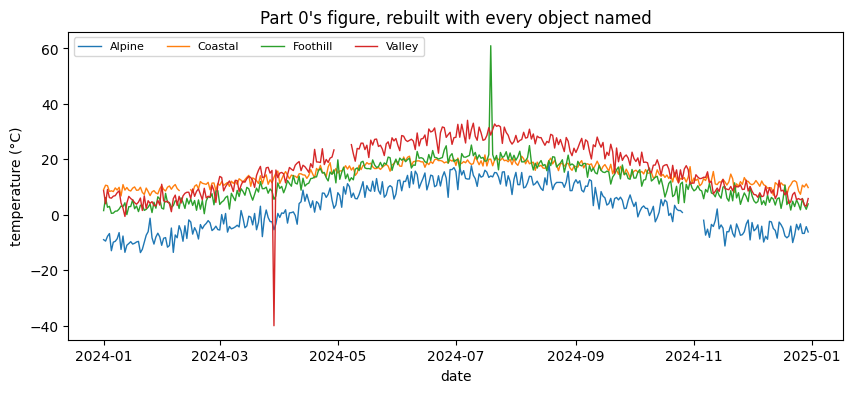

In [12]:
fig, ax = plt.subplots(figsize=(10, 4))

lines = ax.plot(wide.index, wide.values, lw=1.0)   # still a list, still 2-D input
for ln, name in zip(lines, wide.columns):
    ln.set_label(name)                              # one handle per station

ax.set_title("Part 0's figure, rebuilt with every object named")
ax.set_xlabel("date")
ax.set_ylabel("temperature (°C)")
ax.legend(fontsize=8, ncol=4)

from matplotlib.colors import to_hex

print("the handles we kept:")
for ln in lines:
    print(f"   {ln.get_label():9s} colour {to_hex(ln.get_color())}   width {ln.get_linewidth()}")
print()
print("still chosen for us, and still wrong:")
lo, hi = ax.get_ylim()
print(f"   y-limits    {lo:.1f} to {hi:.1f} °C   <- the two bad sensor readings own this")
print(f"   real range  {wide.min().min():.1f} to {wide.max().max():.1f} °C, of which the")
print(f"               honest readings only span {wide.stack().quantile(0.001):.1f} to "
      f"{wide.stack().quantile(0.999):.1f}")
print(f"   figure size {fig.get_size_inches()} inches")
print(f"   colours     {[to_hex(ln.get_color()) for ln in lines]}")
print()
print("But every one of those is now reachable through a name, which is the")
print("only thing Part 1 was ever trying to buy you.")
plt.show()


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

The Part 0 figure again, with a legend this time — so defect #1 from that list is gone, for one extra line of code. Everything else on the list is still there, and the print-out quantifies the worst of it: compare the axis range against the span of the honest readings underneath it. The axis is sized for two impossible sensor values, which is why the real signal is squeezed into a band across the middle and the Foothill spike is the tallest thing on the chart.

Compare the two printed blocks. The first is what we now control; the second is what matplotlib is still choosing on our behalf. Every later part of this notebook moves one row from the second block into the first.

**The common misread:** reading the legend as a fix. A legend makes the figure *identifiable*, not *honest* — a reader can now name the misleading lines. Part 4 is where the axis stops lying.

</div>

---

### What Part 1 bought you

You can now name the object that owns any part of a figure, you know why
`fig, ax = plt.subplots()` is the line to write, and you know that plotting
functions hand back Artists you can keep and mutate.

What you cannot yet do is decide **what kind of chart to draw**. Four
overlapping lines was never the right answer for four groups — that is defect
#5 on Part 0's list, and it is the subject of Part 2.

---


---

# 2️⃣ The core chart types, and choosing between them

Part 1 gave you the objects. This part gives you the vocabulary: the eight or
so functions that account for almost every figure anyone actually publishes.

The organising idea is not "here is a gallery". It is this:

> **Every chart type answers exactly one question, and buys that answer by
> hiding something else.**

A bar chart answers *which group is bigger* by throwing away every individual
value inside the group. A histogram answers *what is the shape* by throwing
away who each observation was. A line chart answers *what changed* by
asserting that the points in between are on the line — which for daily
temperature is a fiction, and for a step function is a lie.

So the skill is not memorising `ax.violinplot`. It is being able to say, out
loud, what your chosen chart is concealing, and deciding you are happy about
it.

## Four questions, four families

| The question you are actually asking | The family | The first thing it hides |
|---|---|---|
| Which of these groups is bigger? | `bar`, `barh` | everything inside each group |
| What shape is this variable? | `hist`, `boxplot`, `violinplot` | which observation is which |
| Do these two variables move together? | `scatter`, `hexbin` | time, and density where points pile up |
| What changed, and when? | `plot`, `fill_between`, `errorbar` | that the line between points is invented |

Everything below is the same weather data from Part 0 — still with its three
sensor gaps and its two impossible readings. We are **not** cleaning it. Some
of these chart types shrug the bad values off; some are visibly destroyed by
them; and two of them refuse to run at all. Which is which is the most useful
thing in this part.


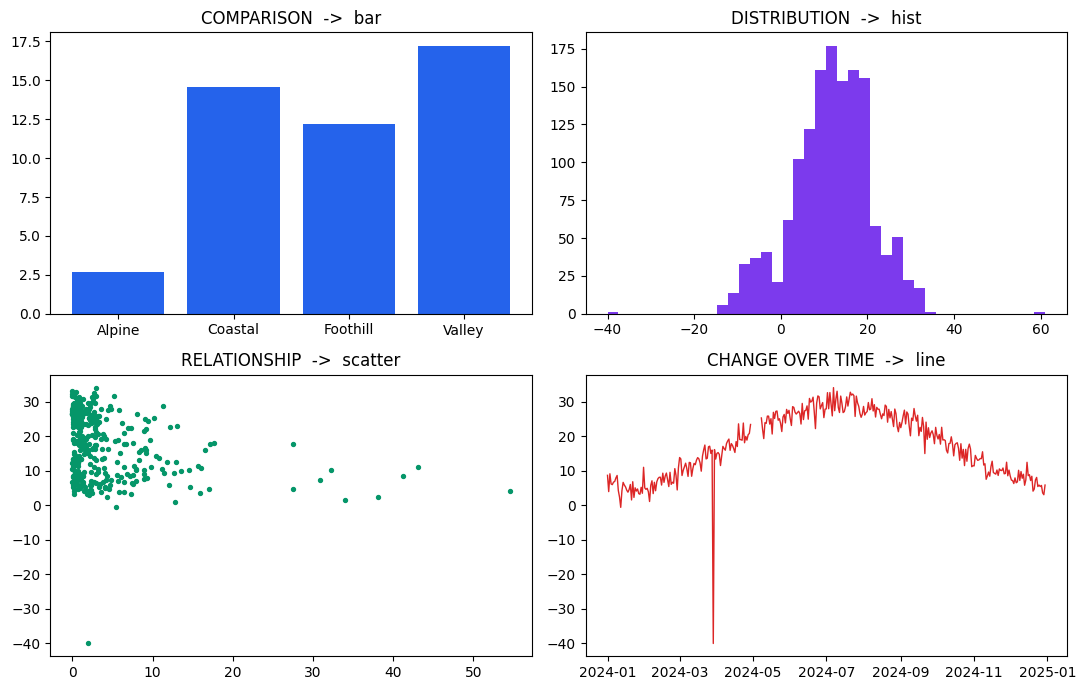

What each panel is built from:
  bar     : 4 numbers, from 1,460 rows
  hist    : 1,437 values (dropped 23 NaN)
  scatter : 365 points, one station only
  line    : 357 points joined by 356 segments nobody measured

temperature range actually plotted: -40.0 to 61.0 deg C


In [13]:
# ============================================================
#  One figure, one question per panel. Same data throughout.
# ============================================================
order = ["Alpine", "Coastal", "Foothill", "Valley"]

means = weather.groupby("station").temp_c.mean().reindex(order)
temps = weather.temp_c.dropna().to_numpy()      # hist cannot bin a NaN -- see below
valley = weather[weather.station == "Valley"]

fig, axes = plt.subplots(2, 2, figsize=(11, 7))

axes[0, 0].bar(order, means.values, color=C_LINE)
axes[0, 0].set_title("COMPARISON  ->  bar")

axes[0, 1].hist(temps, bins=40, color=C_ACC)
axes[0, 1].set_title("DISTRIBUTION  ->  hist")

axes[1, 0].scatter(valley.rain_mm, valley.temp_c, s=8, color=C_OK)
axes[1, 0].set_title("RELATIONSHIP  ->  scatter")

axes[1, 1].plot(wide.index, wide["Valley"], color=C_ALT, lw=1)
axes[1, 1].set_title("CHANGE OVER TIME  ->  line")

fig.tight_layout()
plt.show()

print("What each panel is built from:")
print(f"  bar     : {len(order)} numbers, from {len(weather):,} rows")
print(f"  hist    : {len(temps):,} values (dropped {weather.temp_c.isna().sum()} NaN)")
print(f"  scatter : {len(valley):,} points, one station only")
print(f"  line    : {wide['Valley'].notna().sum()} points joined by "
      f"{wide['Valley'].notna().sum() - 1} segments nobody measured")
print()
print(f"temperature range actually plotted: "
      f"{temps.min():.1f} to {temps.max():.1f} deg C")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Four answers to four different questions, from one table. The bar panel compresses over a thousand rows into four numbers and looks calm and authoritative. The histogram keeps every value but forgets which station each came from. The scatter keeps both variables but loses the date. The line keeps the date but draws segments between days that nobody measured.

The printed block shows the cost explicitly: the bar chart is four numbers standing in for the whole table, and the line chart joins its measured points with one segment per consecutive pair, not one of which was ever observed. Note the printed temperature range — it runs far wider than any real weather station, because the two bad sensor readings are still in there and the histogram panel is already stretched by them.

**The common misread:** treating these as four styles of the same chart. They are four different claims. Swapping a bar chart for a box plot is not a cosmetic change; it is answering a different question.

</div>

## `plot` — and the segments you did not measure

`ax.plot(x, y)` draws straight lines between consecutive points. That is a
**model**, not data: it claims the quantity moved linearly between your
measurements. For daily temperature that is roughly harmless. For a quantity
that jumps — a sensor count, a price tier, a policy that took effect on a
Tuesday — it is wrong, and `drawstyle` is the fix.

Three drawstyles matter:

- `'default'` — straight segments between points.
- `'steps-post'` — the value **holds** from each point until the next one.
  Honest when the quantity really is piecewise-constant.
- `'steps-pre'` — the same idea, but the step happens at the *start* of the
  interval. Getting these two backwards shifts your whole series by one
  interval, which is a silent and very common bug.

Markers are the other half of the decision. A line with no markers hides where
your measurements actually are; add `marker='o'` when the reader needs to know
that you have four points, not four hundred.


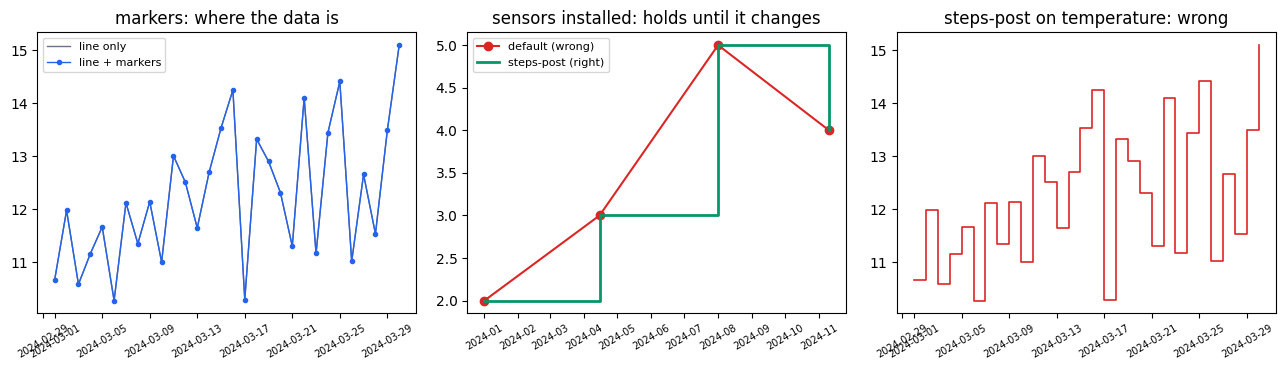

sensor series: 4 measured points, 30 days spanned by the middle panel
A default line through those 4 points claims Valley had a non-integer number of sensors on most days.


In [14]:
# ============================================================
#  Left  : markers show you where the data really is.
#  Middle: steps-post is honest for a quantity that holds.
#  Right : steps-post on temperature is a lie.
# ============================================================
slice30 = wide["Coastal"].iloc[60:90]

# a genuinely piecewise-constant quantity: sensors installed at Valley
change_dates = pd.to_datetime(["2024-01-01", "2024-04-15", "2024-08-01", "2024-11-10"])
sensor_count = np.array([2, 3, 5, 4])

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))

axes[0].plot(slice30.index, slice30.values, color=C_GREY, lw=1, label="line only")
axes[0].plot(slice30.index, slice30.values, color=C_LINE, lw=1,
             marker="o", ms=3, label="line + markers")
axes[0].set_title("markers: where the data is")
axes[0].legend(fontsize=8)

axes[1].plot(change_dates, sensor_count, color=C_ALT, lw=1.5,
             marker="o", label="default (wrong)")
axes[1].plot(change_dates, sensor_count, color=C_OK, lw=2,
             drawstyle="steps-post", label="steps-post (right)")
axes[1].set_title("sensors installed: holds until it changes")
axes[1].legend(fontsize=8)

axes[2].plot(slice30.index, slice30.values, color=C_ALT, lw=1.2,
             drawstyle="steps-post")
axes[2].set_title("steps-post on temperature: wrong")

for ax in axes:
    ax.tick_params(axis="x", labelrotation=30, labelsize=7)
fig.tight_layout()
plt.show()

print(f"sensor series: {len(change_dates)} measured points, "
      f"{len(slice30)} days spanned by the middle panel")
print("A default line through those 4 points claims Valley had a "
      "non-integer number of sensors on most days.")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Left: the same thirty days drawn twice. The grey line alone could be a continuous recording; the blue markers reveal that it is exactly the number of daily readings printed underneath, and nothing in between was measured.

Middle: four sensor-installation events. The red default line slopes between them, which asserts a fractional number of sensors on most days of the year — an impossible value. The green `steps-post` line says what actually happened: a value that held, then jumped.

Right: the same `steps-post` applied to temperature, where it is now the dishonest choice — it claims the temperature was flat all day and then teleported at midnight.

**The common misread:** thinking `drawstyle` is a look. It is a claim about what happened between your measurements, and exactly one of `'default'` and `'steps-post'` is true for any given series.

</div>

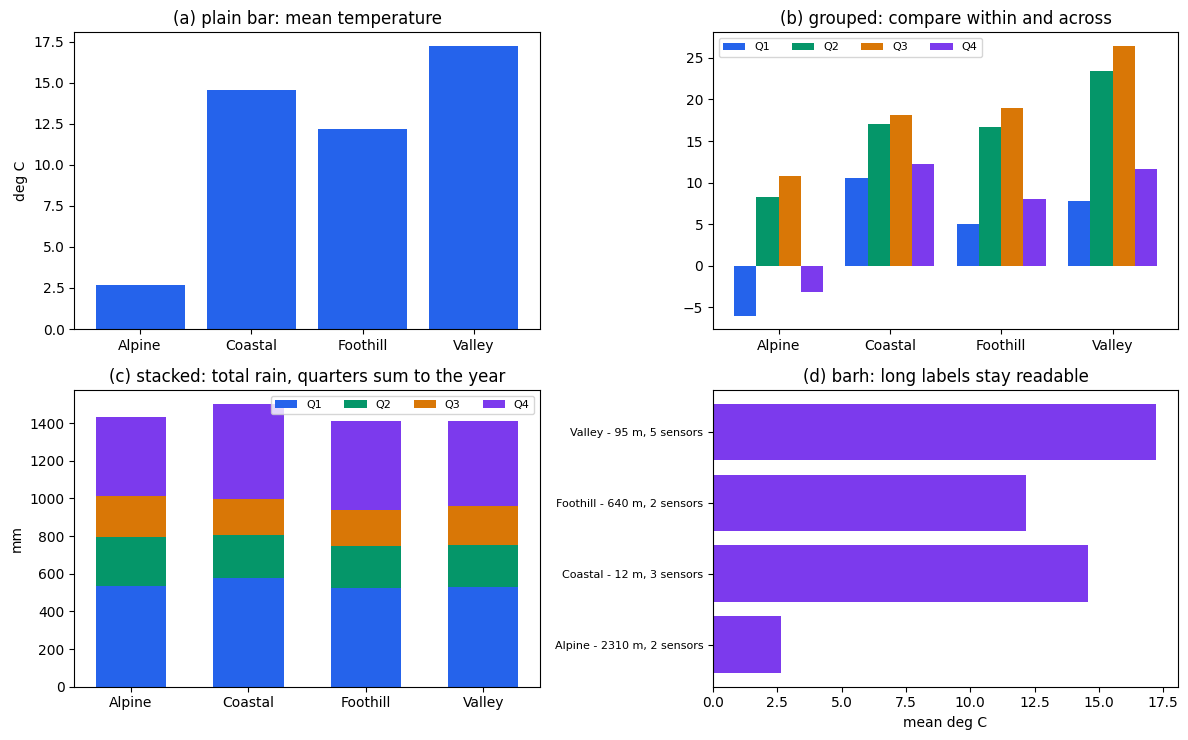

Quarterly rain totals (mm) -- these sum, so stacking is legitimate:
quarter       1      2      3      4
station                             
Alpine    533.0  261.0  216.0  421.0
Coastal   575.0  232.0  192.0  501.0
Foothill  524.0  222.0  191.0  473.0
Valley    527.0  224.0  207.0  455.0

Quarterly mean temperature (deg C) -- these do NOT sum.
Stacking panel (b) would produce a 'total temperature' of 69.3 for Valley, which means nothing.


In [15]:
# ============================================================
#  bar / barh: grouped, stacked, and horizontal.
# ============================================================
q = weather.date.dt.quarter.rename("quarter")
temp_q = weather.groupby(["station", q]).temp_c.mean().unstack().reindex(order)
rain_q = weather.groupby(["station", q]).rain_mm.sum().unstack().reindex(order)

x = np.arange(len(order))
qcols = [C_LINE, C_OK, C_WARN, C_ACC]

fig, axes = plt.subplots(2, 2, figsize=(12, 7.5))

# (a) plain: one number per station
axes[0, 0].bar(x, means.values, color=C_LINE)
axes[0, 0].set_xticks(x); axes[0, 0].set_xticklabels(order)
axes[0, 0].set_title("(a) plain bar: mean temperature")
axes[0, 0].set_ylabel("deg C")

# (b) grouped: one number per station PER QUARTER, side by side
w = 0.2
for i, qtr in enumerate(temp_q.columns):
    axes[0, 1].bar(x + (i - 1.5) * w, temp_q[qtr].values, w,
                   color=qcols[i], label=f"Q{qtr}")
axes[0, 1].set_xticks(x); axes[0, 1].set_xticklabels(order)
axes[0, 1].set_title("(b) grouped: compare within and across")
axes[0, 1].legend(fontsize=8, ncol=4)

# (c) stacked: only legitimate when the parts ADD UP to the whole
bottom = np.zeros(len(order))
for i, qtr in enumerate(rain_q.columns):
    axes[1, 0].bar(x, rain_q[qtr].values, 0.6, bottom=bottom,
                   color=qcols[i], label=f"Q{qtr}")
    bottom += rain_q[qtr].values
axes[1, 0].set_xticks(x); axes[1, 0].set_xticklabels(order)
axes[1, 0].set_title("(c) stacked: total rain, quarters sum to the year")
axes[1, 0].set_ylabel("mm")
axes[1, 0].legend(fontsize=8, ncol=4)

# (d) barh: horizontal, because the labels are long
info = stations.set_index("station").reindex(order)
long_labels = [f"{s} - {int(r.elevation)} m, {int(r.sensors)} sensors"
               for s, r in info.iterrows()]
axes[1, 1].barh(x, means.values, color=C_ACC)
axes[1, 1].set_yticks(x); axes[1, 1].set_yticklabels(long_labels, fontsize=8)
axes[1, 1].set_title("(d) barh: long labels stay readable")
axes[1, 1].set_xlabel("mean deg C")

fig.tight_layout()
plt.show()

print("Quarterly rain totals (mm) -- these sum, so stacking is legitimate:")
print(rain_q.round(0).to_string())
print()
print("Quarterly mean temperature (deg C) -- these do NOT sum.")
print("Stacking panel (b) would produce a 'total temperature' of "
      f"{temp_q.loc['Valley'].sum():.1f} for Valley, which means nothing.")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Four uses of the same function. (a) is the whole year in four numbers. (b) splits each station by quarter so you can read both comparisons — within a station across seasons, and across stations within a season — at the cost of four times as many bars. (c) stacks quarterly rainfall, which is legitimate because the four quarters genuinely add up to the year's total, printed underneath. (d) is the same data as (a) rotated, and the only reason is the labels: the station descriptions do not fit under vertical bars without rotating text 45 degrees.

The printed block shows why (b) is grouped and not stacked. Rainfall sums; mean temperature does not. The 'total' printed for Valley is arithmetically computable and completely meaningless.

**The common misread:** reading a stacked bar's upper segments as if they shared a baseline. Only the bottom segment starts at zero — every segment above it floats, so comparing the *second* segment across bars is much harder than it looks, and is the reason grouped bars often beat stacked ones even when the parts do sum.

</div>

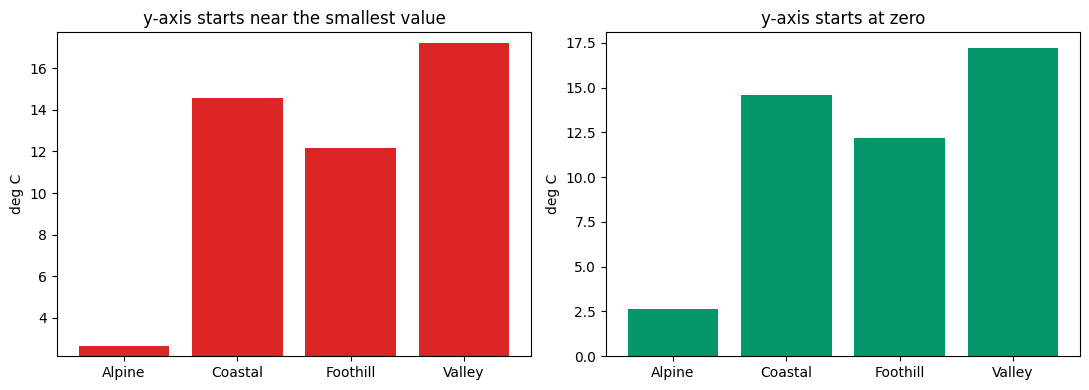

Warmest / coldest station, true ratio of means :  6.48 x
Ratio of BAR LENGTHS in the left-hand panel     : 30.12 x
The truncated axis exaggerates the difference by 4.7 times.


In [16]:
# ============================================================
#  FAILURE FIRST: the same four means, two y-axes.
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].bar(order, means.values, color=C_ALT)
axes[0].set_ylim(means.min() - 0.5, means.max() + 0.5)   # <-- the distortion
axes[0].set_title("y-axis starts near the smallest value")
axes[0].set_ylabel("deg C")

axes[1].bar(order, means.values, color=C_OK)
axes[1].set_ylim(0, None)                                 # honest for a bar
axes[1].set_title("y-axis starts at zero")
axes[1].set_ylabel("deg C")

fig.tight_layout()
plt.show()

lo = means.min() - 0.5
drawn = means.values - lo                 # bar lengths the eye actually compares
true_ratio  = means.max() / means.min()
drawn_ratio = drawn.max() / drawn.min()
print(f"Warmest / coldest station, true ratio of means : {true_ratio:5.2f} x")
print(f"Ratio of BAR LENGTHS in the left-hand panel     : {drawn_ratio:5.2f} x")
print(f"The truncated axis exaggerates the difference by "
      f"{drawn_ratio / true_ratio:.1f} times.")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Two bar charts of **exactly the same four numbers**. One line of code differs between them.

On the left the y-axis starts just below the smallest mean, so the coldest station's bar is a stub and the warmest station's bar towers over it. On the right the axis starts at zero and the four stations look like what they are: different, but on the same order of magnitude. Both panels have honest tick labels, and a reader checking the numbers would find nothing wrong with either.

The printed block puts a figure on the damage. It compares the true ratio of the two extreme means against the ratio of the bar *lengths* the eye actually compares in the left panel, and reports how many times the truncated axis exaggerates the difference.

**The common misread:** believing you did not fall for it because you read the axis. You did not read the axis — nobody does. The length is processed before the labels are, which is exactly why this is the most effective chart distortion there is.

</div>

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ The trap

**A bar's message is its length, so the length must be proportional to the value — and that is only true if the axis starts at zero.** The left panel above is not a styling choice; it is a factual distortion, and the printed exaggeration factor tells you how large. Nothing in the figure warns the reader, because the tick labels are all correct.

matplotlib will do this to you by accident: `ax.set_ylim(auto)` after a `fill_between`, a shared axis from another panel, or a seaborn-style helper can all leave a bar chart floating off zero.

**When a non-zero baseline is legitimate:** when the mark's *position* carries the meaning rather than its length. A line chart of temperature over time, a scatter, a dot plot, an interval on an errorbar — none of these encode value as length from a baseline, so cropping the axis to the interesting range is not merely allowed, it is usually necessary. Temperature in particular has no meaningful zero in Celsius at all. The rule is about **bars**, not about axes.

If you need both a zero baseline and detail in a narrow range, the answer is to change the chart — a dot plot, or bars of the *difference* from a reference — not to crop the bar axis and hope.

</div>

## `hist` — and the one parameter that decides your conclusion

A histogram has one real parameter, and almost nobody chooses it deliberately.
matplotlib's default is `bins=10`. That number is not a rendering detail: it
decides whether your distribution appears to have one peak or four, whether it
looks symmetric, and whether a cluster of unusual values is visible at all.

The figure below is the **same temperature readings four times**. Only `bins`
changes. Read the four panels before reading the caption and write down what
shape you think the data has.


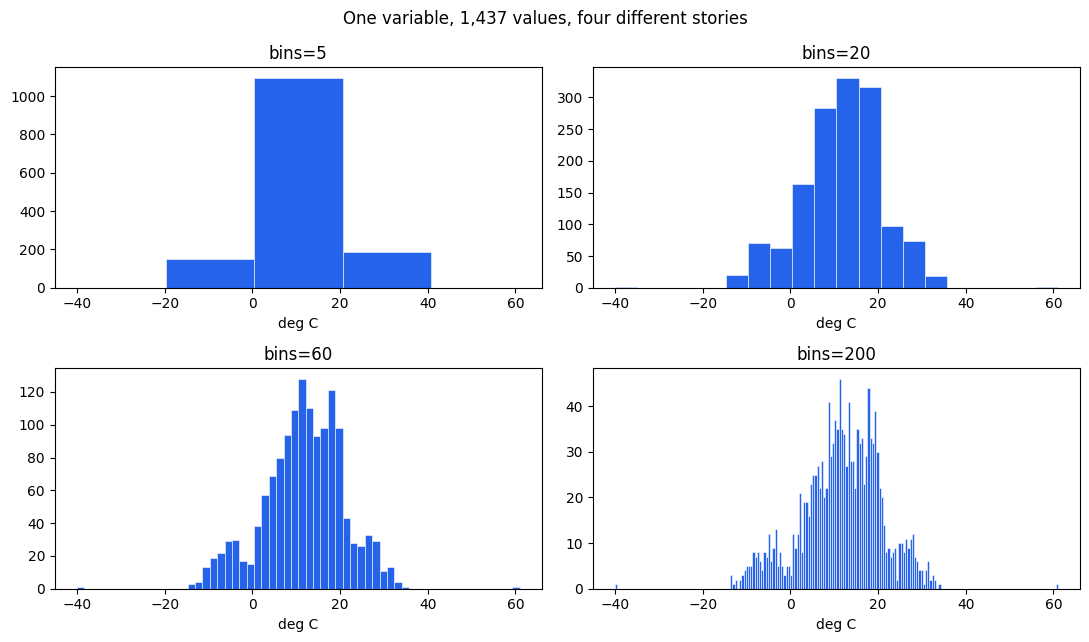

 bins    width  non-empty  in tallest bar
    5   20.20C      5/5             76.2%
   20    5.05C     12/20            23.0%
   60    1.68C     32/60             8.9%
  200    0.51C     95/200            3.2%

density=False : tallest bar = 238 (a count of readings)
density=True  : tallest bar = 0.0492 (a probability density)
density=True  : sum(height * width) = 1.0000  <- area is 1

Rule-of-thumb bin counts for n=1,437:
  Sturges       : 12
  sqrt(n)       : 37
  numpy 'fd'    : 50


In [17]:
# ============================================================
#  The same values, four bin counts. Nothing else differs.
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(11, 6.5))

for ax, b in zip(axes.ravel(), [5, 20, 60, 200]):
    ax.hist(temps, bins=b, color=C_LINE, edgecolor="white", linewidth=0.4)
    ax.set_title(f"bins={b}")
    ax.set_xlabel("deg C")

fig.suptitle(f"One variable, {len(temps):,} values, four different stories",
             fontsize=12)
fig.tight_layout()
plt.show()

# what each bin count actually buys
print(f"{'bins':>5}  {'width':>7}  {'non-empty':>9}  {'in tallest bar':>14}")
for b in [5, 20, 60, 200]:
    c, edges = np.histogram(temps, bins=b)
    print(f"{b:>5}  {edges[1] - edges[0]:6.2f}C  {np.count_nonzero(c):>5}/{b:<3}"
          f"  {100 * c.max() / c.sum():>13.1f}%")

print()
# what density=True actually changes
counts, edges = np.histogram(temps, bins=30)
dens,   _     = np.histogram(temps, bins=30, density=True)
width = edges[1] - edges[0]
print(f"density=False : tallest bar = {counts.max():,} (a count of readings)")
print(f"density=True  : tallest bar = {dens.max():.4f} (a probability density)")
print(f"density=True  : sum(height * width) = {(dens * width).sum():.4f}  <- area is 1")
print()
print(f"Rule-of-thumb bin counts for n={len(temps):,}:")
print(f"  Sturges       : {int(np.ceil(np.log2(len(temps)) + 1))}")
print(f"  sqrt(n)       : {int(np.sqrt(len(temps)))}")
print(f"  numpy 'fd'    : {len(np.histogram_bin_edges(temps, bins='fd')) - 1}")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

The identical values, binned four ways, and the table underneath is the argument. At `bins=5` the bin width is printed as tens of degrees and the share of data in the single tallest bar is printed as most of the dataset: the distribution looks like one symmetric lump and you would call it unimodal without hesitating. At `bins=20` the mass separates into a broad hump with a distinct left shoulder — that shoulder is real, and it is the four stations having genuinely different climates. At `bins=60` more structure appears and the shape is still stable. At `bins=200` it has collapsed into noise: the printed non-empty count shows that over half the bins are now empty, and neighbouring bars differ by amounts that are pure sampling wobble.

Look also at the far edges of every panel. The x-axis stretches well past any plausible temperature because the 61 and −40 sensor faults are still in the data, and that is what makes `bins=5` so catastrophic — the bins are sized to a range that two bad readings invented, so the entire real distribution is squeezed into one or two of them. Part 4 fixes that with axis limits; Part 5 annotates them.

The printed block also shows what `density=True` does: it rescales the heights so the total **area** is 1 instead of the total count being n. The shape is identical — it only lets you overlay two samples of different sizes on the same axes, or compare against a fitted curve.

**The common misread:** believing the shape you see is a property of the data. It is a property of the data *and your bin count*. If a claim about modality survives only at one bin width, it is not a claim about the world.

</div>

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ The trap

**`bins=10` is a default, not an analysis.** matplotlib will never warn you that a different bin count reverses your conclusion, and reviewers very rarely ask what you used.

Three defences, in order of effort:

1. **Always plot at least three bin counts before you believe a shape.** This costs one loop and catches nearly everything.
2. **Use a rule.** `bins='fd'` (Freedman–Diaconis) and `bins='auto'` are accepted by both NumPy and matplotlib and scale the width with the spread and the sample size; the values they pick for this data are printed above. They are not magic, but they are a defensible default.
3. **Show the points too** — a rug, a strip plot, or a KDE overlay — so the reader can see the sample the bars are made of.

Two related traps in the same function: `ax.hist` **cannot handle NaN**. Our data has three sensor gaps, so every histogram in this part starts with `.dropna()`; without it, the automatic range comes back as `[nan, nan]` and the call raises. And `ax.hist(a, b)` does not plot two series — the second positional argument is `bins`. Pass a list, `ax.hist([a, b])`, when you want two.

</div>

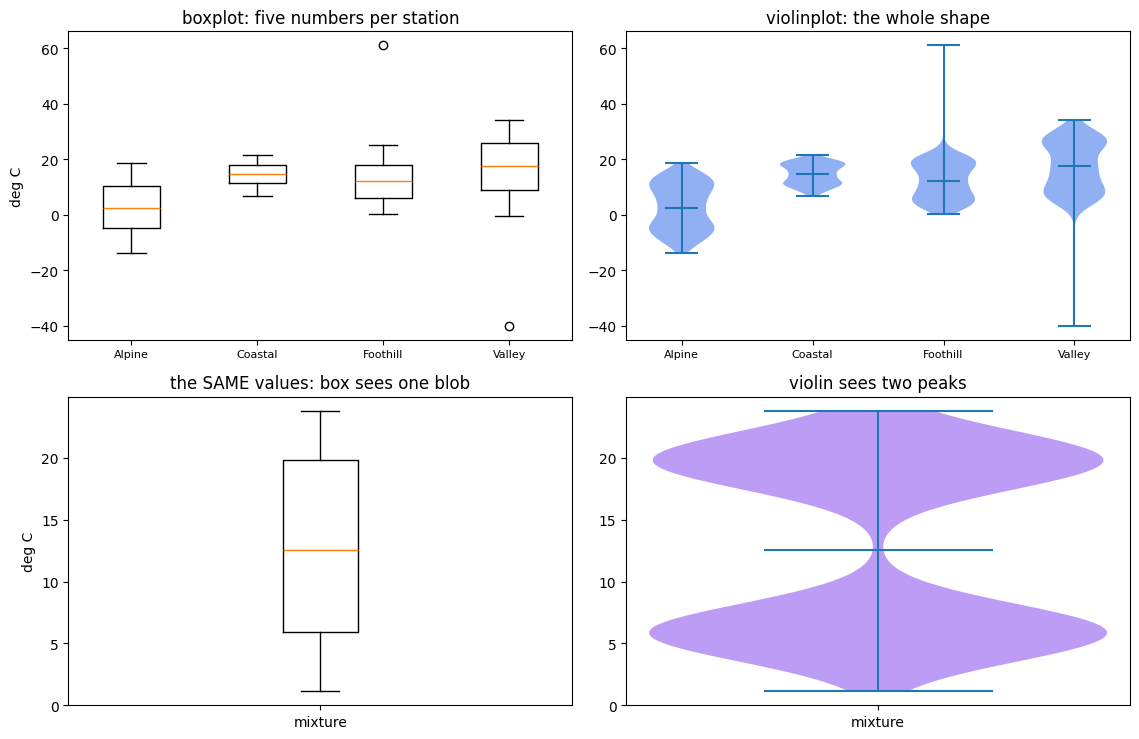

Valley box, part by part:
  median (the line)       :  17.47
  Q1 / Q3 (the box edges) :   9.05 /  25.84   IQR = 16.79
  whisker reach (1.5*IQR) : -16.14 /  51.03
  whiskers actually drawn :  -0.57 /  34.10   (last point inside the reach)
  fliers (dots beyond)    : 1   min=-40.0  <- the -40 sensor fault, plotted as a dot

The mixture, which the box plot called one blob:
  median                  :  12.58
  values within +/-1 of that median: 0 out of 800

Readings per third of each station's middle 90% (low / middle / high):
  Alpine     119   85  115   middle is the emptiest: True
  Coastal    108   91  125   middle is the emptiest: True
  Foothill   112   86  129   middle is the emptiest: True
  Valley     115   88  118   middle is the emptiest: True


In [18]:
# ============================================================
#  boxplot vs violinplot -- on real data (top) and on a
#  distribution deliberately built to break the box (bottom).
# ============================================================
# NEITHER function tolerates NaN: with gaps left in, the quartiles come back
# NaN and the boxes vanish. Masking is telling the function what to skip --
# it is not cleaning the data, which stays exactly as Part 0 made it.
groups = [weather.loc[weather.station == s, "temp_c"].dropna().to_numpy()
          for s in order]

# a two-mode mixture: morning and afternoon readings from one sensor
rng = np.random.default_rng(7)
mix = np.concatenate([rng.normal(6.0, 1.5, 400), rng.normal(20.0, 1.5, 400)])

fig, axes = plt.subplots(2, 2, figsize=(11.5, 7.5))

axes[0, 0].boxplot(groups)
axes[0, 0].set_xticks(range(1, len(order) + 1))
axes[0, 0].set_xticklabels(order, fontsize=8)
axes[0, 0].set_title("boxplot: five numbers per station")
axes[0, 0].set_ylabel("deg C")

parts = axes[0, 1].violinplot(groups, showmedians=True)
for b in parts["bodies"]:
    b.set_facecolor(C_LINE); b.set_alpha(0.5)
axes[0, 1].set_xticks(range(1, len(order) + 1))
axes[0, 1].set_xticklabels(order, fontsize=8)
axes[0, 1].set_title("violinplot: the whole shape")

axes[1, 0].boxplot([mix])
axes[1, 0].set_xticks([1]); axes[1, 0].set_xticklabels(["mixture"])
axes[1, 0].set_title("the SAME values: box sees one blob")
axes[1, 0].set_ylabel("deg C")

p2 = axes[1, 1].violinplot([mix], showmedians=True)
p2["bodies"][0].set_facecolor(C_ACC); p2["bodies"][0].set_alpha(0.5)
axes[1, 1].set_xticks([1]); axes[1, 1].set_xticklabels(["mixture"])
axes[1, 1].set_title("violin sees two peaks")

fig.tight_layout()
plt.show()

# what the box actually draws, spelled out for Valley
v = weather.loc[weather.station == "Valley", "temp_c"].dropna()
q1, med, q3 = np.percentile(v, [25, 50, 75])
iqr = q3 - q1
lo_w, hi_w = q1 - 1.5 * iqr, q3 + 1.5 * iqr
inside = v[(v >= lo_w) & (v <= hi_w)]
print("Valley box, part by part:")
print(f"  median (the line)       : {med:6.2f}")
print(f"  Q1 / Q3 (the box edges) : {q1:6.2f} / {q3:6.2f}   IQR = {iqr:.2f}")
print(f"  whisker reach (1.5*IQR) : {lo_w:6.2f} / {hi_w:6.2f}")
print(f"  whiskers actually drawn : {inside.min():6.2f} / {inside.max():6.2f}"
      "   (last point inside the reach)")
print(f"  fliers (dots beyond)    : {len(v) - len(inside)}"
      f"   min={v.min():.1f}  <- the -40 sensor fault, plotted as a dot")
print()
print("The mixture, which the box plot called one blob:")
print(f"  median                  : {np.median(mix):6.2f}")
print(f"  values within +/-1 of that median: {np.sum(np.abs(mix - np.median(mix)) < 1)}"
      f" out of {len(mix)}")
print()
# Are the REAL stations bimodal too? Split each station's middle 90% into
# three equal-width slices and count. A single peak puts the most readings
# in the middle slice. A dip in the middle means two modes.
print("Readings per third of each station's middle 90% (low / middle / high):")
for s, g in zip(order, groups):
    e = np.linspace(*np.percentile(g, [5, 95]), 4)
    c, _ = np.histogram(g, bins=e)
    print(f"  {s:<9} {c[0]:>4} {c[1]:>4} {c[2]:>4}"
          f"   middle is the emptiest: {c[1] < c[0] and c[1] < c[2]}")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

**Reading a box, top-left.** The line inside the box is the median. The box spans the first to the third quartile, so it holds the middle half of the data; its height is the interquartile range. The whiskers reach out to 1.5 × IQR — but they stop at the last real value inside that reach, which is why the printed 'whisker reach' and 'whiskers actually drawn' numbers differ. Anything past that is drawn individually as a flier. Valley's flier count is printed, and its minimum is the −40 sensor fault: the box plot is the first chart in this part that isolates a bad reading instead of being wrecked by it.

**Top-right** is the same four stations as violins, and it is a surprise: every one of them has **two humps**, one cold and one warm, with a dip in the middle. That is real and it is seasonality — a year driven by a sine wave spends more days near its extremes than near its annual mean. The printed three-slice counts confirm it without appealing to the picture: for every station the middle third of the range holds fewer readings than either outer third. The four box plots directly above put their median lines right through that dip and say nothing about it.

**Bottom row is the controlled version of the same argument.** One mixture of two normals, drawn twice. The box plot shows a single tidy box with its median in the middle; the violin shows two cleanly separated peaks with a gap between them. The printed count says how many of those values actually lie within a degree of the median — the box's central line sits where there is no data at all.

**The common misread:** treating a box plot as a summary of the shape. It is a summary of five order statistics, and any distribution with the same five numbers draws the same box. Bimodality, gaps, clumping and granularity are all invisible to it. Use a box when you are comparing many groups' locations; use a violin, or a histogram, when the shape is the point.

</div>

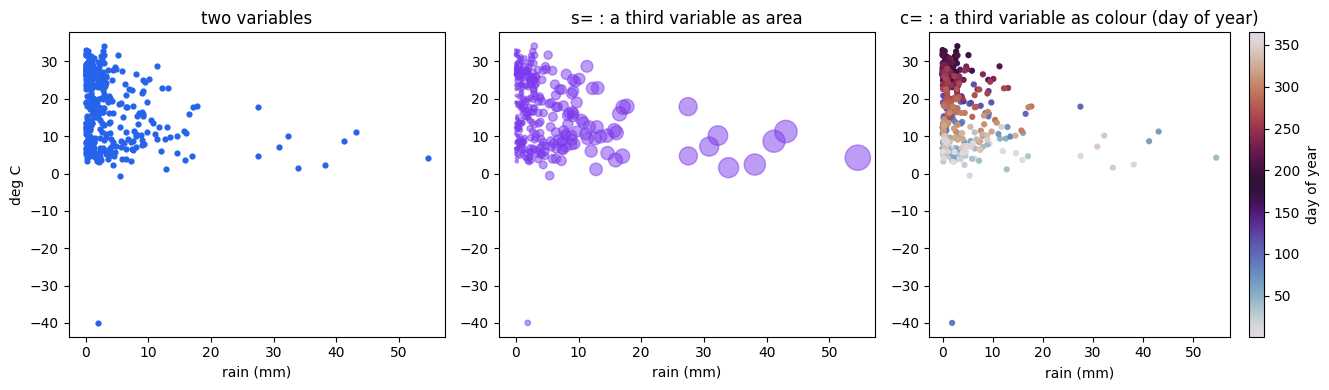

Valley: Pearson correlation of rain and temperature = -0.265
n = 357 points plotted, 8 silently skipped as NaN
y-axis spans -40.0 to 34.1 -- the -40 fault is one of these points, bottom left.


In [19]:
# ============================================================
#  scatter: two variables, plus up to two more via s= and c=.
# ============================================================
v = weather[weather.station == "Valley"]
doy = v.date.dt.dayofyear.to_numpy()

fig, axes = plt.subplots(1, 3, figsize=(13.5, 4))

axes[0].scatter(v.rain_mm, v.temp_c, s=12, color=C_LINE)
axes[0].set_title("two variables")
axes[0].set_xlabel("rain (mm)"); axes[0].set_ylabel("deg C")

axes[1].scatter(v.rain_mm, v.temp_c, s=4 + 6 * v.rain_mm, alpha=0.5, color=C_ACC)
axes[1].set_title("s= : a third variable as area")
axes[1].set_xlabel("rain (mm)")

sc = axes[2].scatter(v.rain_mm, v.temp_c, s=12, c=doy, cmap="twilight")
axes[2].set_title("c= : a third variable as colour (day of year)")
axes[2].set_xlabel("rain (mm)")
fig.colorbar(sc, ax=axes[2], label="day of year")

fig.tight_layout()
plt.show()

r = v[["rain_mm", "temp_c"]].corr().iloc[0, 1]
print(f"Valley: Pearson correlation of rain and temperature = {r:.3f}")
print(f"n = {v.temp_c.notna().sum()} points plotted, "
      f"{v.temp_c.isna().sum()} silently skipped as NaN")
print(f"y-axis spans {v.temp_c.min():.1f} to {v.temp_c.max():.1f} -- "
      "the -40 fault is one of these points, bottom left.")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

One station, three encodings of the same pair of columns. The left panel is the honest minimum: rainfall against temperature, with the correlation printed underneath so you are not eyeballing it.

The middle panel adds rainfall a second time as marker *area* via `s=`. Note that `s` is an area in points squared, not a radius — doubling `s` does not double the apparent size, which is why size is the weakest of the channels and should carry only a rough ordering.

The right panel adds day-of-year as colour via `c=`, with a colorbar, and suddenly the seasonal structure that the left panel destroyed is legible again: the cold points and the warm points come from different times of year rather than being scattered noise. Part 7 is about choosing that colormap properly.

Scatter is also the chart that shrugs off NaN — the printed count shows the gap days simply never appear, with no error and no warning. The bad reading, by contrast, is right there stretching the y-axis.

**The common misread:** reading a scatter as if every point were visible. Each panel above has over three hundred markers and many are drawn on top of each other, so the visual density is already lying slightly about how many observations sit in the crowded region. Which is the next figure.

</div>

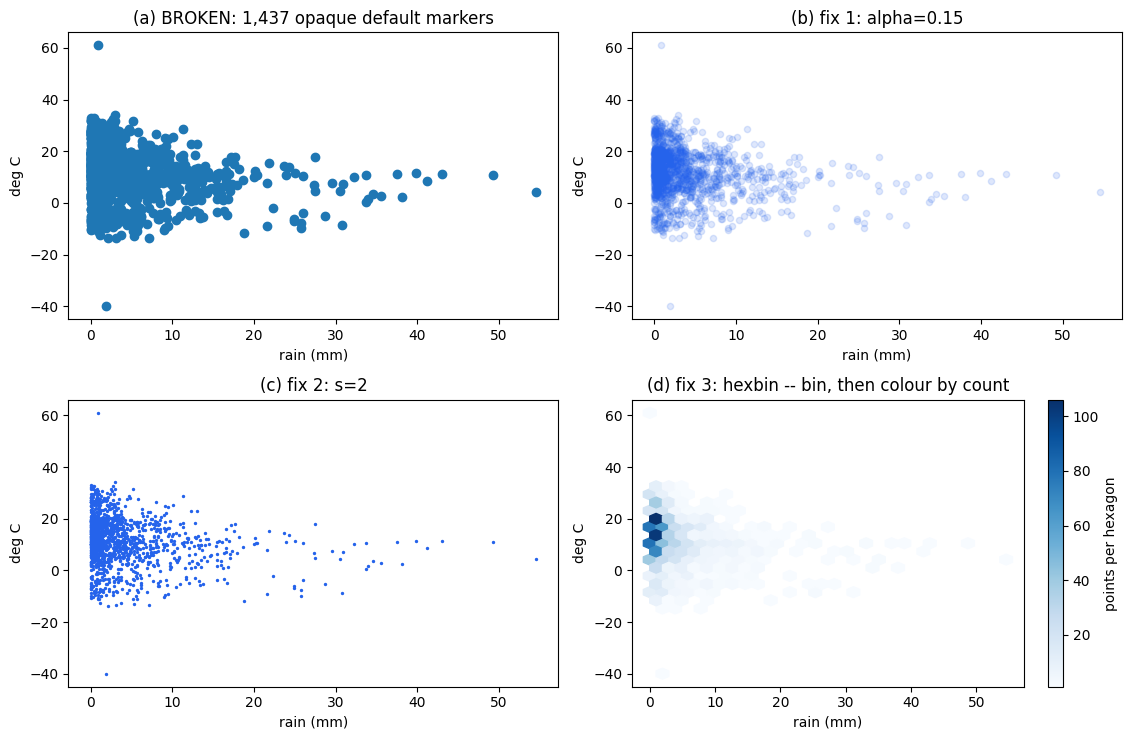

points plotted        : 1,437
occupied hexagons     : 148
busiest hexagon holds : 106 points
that one hexagon is   : 7.4% of the data, drawn as a single blob in panel (a)


In [20]:
# ============================================================
#  FAILURE FIRST: all four stations, every day, opaque.
# ============================================================
ok = weather.temp_c.notna()          # hexbin cannot bin a NaN either
x_all, y_all = weather.rain_mm[ok].to_numpy(), weather.temp_c[ok].to_numpy()

fig, axes = plt.subplots(2, 2, figsize=(11.5, 7.5))

axes[0, 0].scatter(x_all, y_all)                       # every default
axes[0, 0].set_title(f"(a) BROKEN: {len(x_all):,} opaque default markers")

axes[0, 1].scatter(x_all, y_all, alpha=0.15, s=20, color=C_LINE)
axes[0, 1].set_title("(b) fix 1: alpha=0.15")

axes[1, 0].scatter(x_all, y_all, s=2, color=C_LINE)
axes[1, 0].set_title("(c) fix 2: s=2")

hb = axes[1, 1].hexbin(x_all, y_all, gridsize=28, cmap="Blues", mincnt=1)
axes[1, 1].set_title("(d) fix 3: hexbin -- bin, then colour by count")
fig.colorbar(hb, ax=axes[1, 1], label="points per hexagon")

for ax in axes.ravel():
    ax.set_xlabel("rain (mm)"); ax.set_ylabel("deg C")
fig.tight_layout()
plt.show()

# how bad is the overplotting, numerically?
counts = hb.get_array()
print(f"points plotted        : {len(x_all):,}")
print(f"occupied hexagons     : {len(counts):,}")
print(f"busiest hexagon holds : {int(counts.max()):,} points")
print(f"that one hexagon is   : {100 * counts.max() / len(x_all):.1f}% "
      "of the data, drawn as a single blob in panel (a)")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

(a) is the failure: every marker fully opaque at the default size, so the left-hand column of the plot is a solid wall. The printed numbers say how bad it is — a single hexagon's worth of area holds the printed percentage of the entire dataset, and in panel (a) that region looks exactly like any other filled region.

(b) `alpha=0.15` makes density readable as darkness: where twenty points overlap the colour saturates, where two overlap it stays faint. Cheap and usually enough. (c) `s=2` shrinks the markers until they stop colliding; this preserves individual points and works well up to a few thousand. (d) `hexbin` stops pretending to draw points at all — it bins the plane and colours each cell by count, with a colorbar that makes density an actual readable quantity. `hist2d` is the same idea on a square grid.

Roughly: alpha up to a few thousand points, smaller markers alongside it, hexbin or hist2d beyond about ten thousand.

**The common misread:** concluding from panel (a) that the relationship is a solid band. The band is an artefact of ink, not of data — panels (b) to (d) show the same points concentrated in a much smaller region, with a long thin tail that panel (a) renders at the same visual weight as the dense core.

</div>

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ The trap

**Overplotting does not look like a bug.** A saturated scatter looks confident and full; it is the one failure mode in this part that makes a figure look *more* authoritative as it gets more wrong. Two symptoms worth memorising: a region of perfectly uniform colour, and a plot whose appearance stops changing when you add more data.

The honest check is numeric, not visual — count points per bin, as the block above does. If your busiest cell holds more than a percent or two of the sample, no amount of alpha will make the picture quantitative and you should be using `hexbin`, `hist2d`, or a 2-D density estimate.

A related trap: `alpha` also changes how *outliers* read. At `alpha=0.15` a genuinely isolated point is nearly invisible, so the fix for overplotting can hide the very observations you most need to see. Overlay them separately, or use `hexbin` with `mincnt=1` so that a lone point still gets a full cell.

</div>

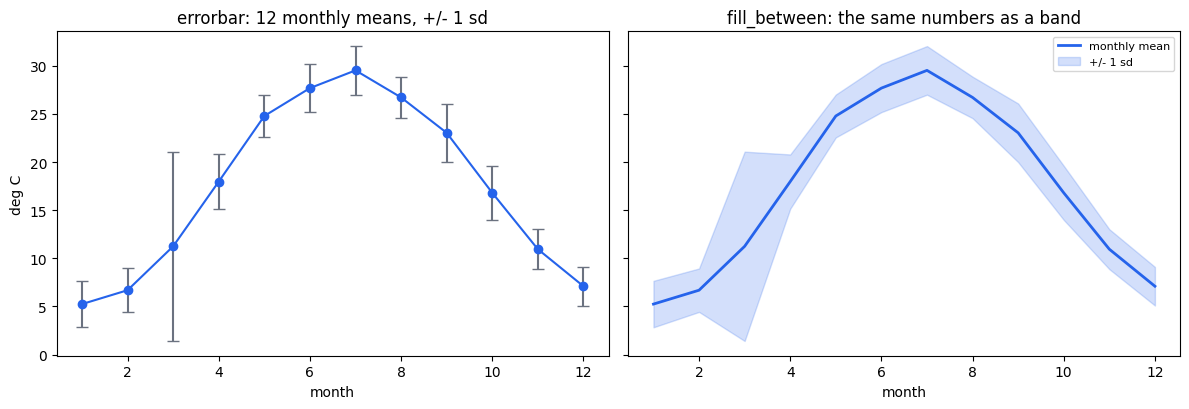

       mean   std  count
date                    
1      5.24  2.41     31
2      6.68  2.26     29
3     11.24  9.83     31
4     17.97  2.82     29
5     24.78  2.23     24
6     27.68  2.50     30
7     29.52  2.52     31
8     26.71  2.16     31
9     23.03  3.04     30
10    16.80  2.81     31
11    10.94  2.07     30
12     7.10  2.00     30

Largest monthly sd is month 3: 9.83 deg C, against a median of 2.41 elsewhere.
That month contains the -40 sensor fault. One bad reading out of 31 has roughly 4.1x-ed the error bar.


In [21]:
# ============================================================
#  Uncertainty: errorbar (discrete) and fill_between (continuous).
# ============================================================
vv = weather[weather.station == "Valley"]
mo = vv.groupby(vv.date.dt.month).temp_c.agg(["mean", "std", "count"])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), sharey=True)

axes[0].errorbar(mo.index, mo["mean"], yerr=mo["std"], fmt="o-",
                 color=C_LINE, ecolor=C_GREY, capsize=4, lw=1.5)
axes[0].set_title("errorbar: 12 monthly means, +/- 1 sd")
axes[0].set_xlabel("month"); axes[0].set_ylabel("deg C")

axes[1].plot(mo.index, mo["mean"], color=C_LINE, lw=2, label="monthly mean")
axes[1].fill_between(mo.index, mo["mean"] - mo["std"], mo["mean"] + mo["std"],
                     color=C_LINE, alpha=0.2, label="+/- 1 sd")
axes[1].set_title("fill_between: the same numbers as a band")
axes[1].set_xlabel("month"); axes[1].legend(fontsize=8)

fig.tight_layout()
plt.show()

print(mo.round(2).to_string())
print()
worst = mo["std"].idxmax()
typical = mo["std"].drop(worst).median()
print(f"Largest monthly sd is month {worst}: {mo.loc[worst, 'std']:.2f} deg C, "
      f"against a median of {typical:.2f} elsewhere.")
print("That month contains the -40 sensor fault. One bad reading out of "
      f"{int(mo.loc[worst, 'count'])} has roughly "
      f"{mo.loc[worst, 'std'] / typical:.1f}x-ed the error bar.")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

The same twelve monthly means with the same twelve standard deviations, drawn two ways. `errorbar` treats the months as twelve discrete measurements and draws an interval on each; `fill_between` treats them as samples of a continuous curve and shades the region between two arrays. Use the first when the x values are genuinely separate cases, the second when interpolating between them is meaningful.

One month's interval is obviously wrong, and the printed table says which and by how much: the −40 sensor fault sits in that month, and a single impossible reading has multiplied its standard deviation by the printed factor. The mean barely moves — one bad value in about thirty is diluted — but the spread is destroyed. This is why uncertainty bands are a better outlier detector than means are.

**The common misread:** assuming a band is a confidence interval. This one is ±1 standard deviation, which describes the spread of daily readings, not the precision of the monthly mean — the standard error would be that same number divided by the square root of the printed count, and therefore several times narrower. A band with no stated definition is decoration. Say what it is, in the legend, every time.

</div>

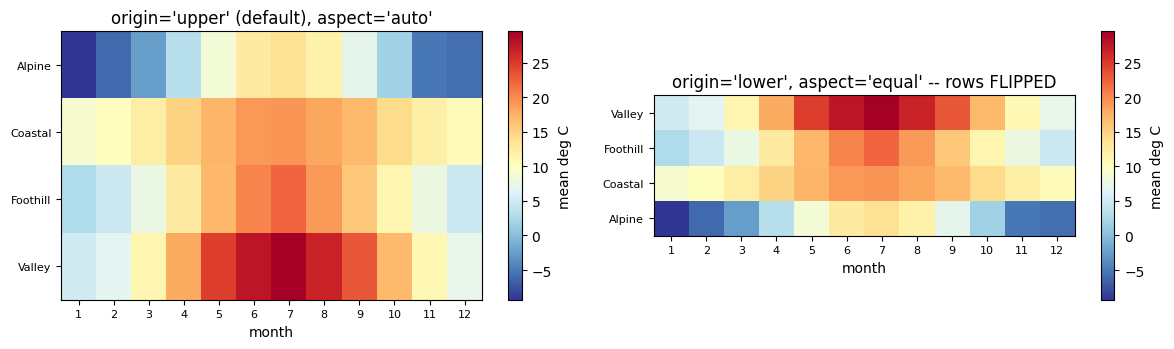

date       1     2     3     4     5     6     7     8     9     10    11    12
station                                                                        
Alpine   -9.3  -6.1  -2.6   3.4   8.5  12.7  13.7  11.7   6.9   1.8  -5.1  -5.7
Coastal   9.0  10.2  12.4  14.8  17.1  19.2  19.3  18.3  16.9  14.2  12.1  10.4
Foothill  2.8   4.7   7.6  12.6  17.0  20.3  22.1  19.0  15.8  11.3   7.8   4.8
Valley    5.2   6.7  11.2  18.0  24.8  27.7  29.5  26.7  23.0  16.8  10.9   7.1

matrix shape        : 4 stations x 12 months
row 0 of the array  : Alpine
In the LEFT panel row 0 is drawn at the top; in the RIGHT panel the same row is at the bottom. The tick labels were not changed, so the right panel now labels the wrong rows.


In [22]:
# ============================================================
#  imshow: a matrix as a picture. Stations x months.
# ============================================================
grid = (weather.groupby(["station", weather.date.dt.month])
        .temp_c.mean().unstack().reindex(order))

fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))

im0 = axes[0].imshow(grid.values, cmap="RdYlBu_r", aspect="auto")
axes[0].set_title("origin='upper' (default), aspect='auto'")
axes[0].set_yticks(range(len(order))); axes[0].set_yticklabels(order, fontsize=8)
axes[0].set_xticks(range(12)); axes[0].set_xticklabels(range(1, 13), fontsize=8)
axes[0].set_xlabel("month")
fig.colorbar(im0, ax=axes[0], label="mean deg C")

im1 = axes[1].imshow(grid.values, cmap="RdYlBu_r", origin="lower", aspect="equal")
axes[1].set_title("origin='lower', aspect='equal' -- rows FLIPPED")
axes[1].set_yticks(range(len(order))); axes[1].set_yticklabels(order, fontsize=8)
axes[1].set_xticks(range(12)); axes[1].set_xticklabels(range(1, 13), fontsize=8)
axes[1].set_xlabel("month")
fig.colorbar(im1, ax=axes[1], label="mean deg C")

fig.tight_layout()
plt.show()

print(grid.round(1).to_string())
print()
print(f"matrix shape        : {grid.shape[0]} stations x {grid.shape[1]} months")
print(f"row 0 of the array  : {order[0]}")
print("In the LEFT panel row 0 is drawn at the top; in the RIGHT panel the "
      "same row is at the bottom. The tick labels were not changed, so the "
      "right panel now labels the wrong rows.")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

A four-by-twelve matrix of mean temperatures drawn as pixels, twice. Compare each panel against the printed table: the seasonal sweep across the columns and the ordering of the stations are both readable as colour, which is the whole point of `imshow` — it is the only chart here that scales to a matrix with hundreds of rows.

The two panels differ in two keyword arguments. `origin` decides whether array row 0 is drawn at the top (the default, matching how a matrix is written) or at the bottom (matching how a plot's y-axis normally runs). The right panel flips the rows but keeps the same tick labels, so it is now mislabelled — this is not a hypothetical, it is the single most common `imshow` bug. `aspect` decides whether cells are stretched to fill the axes (`'auto'`) or kept square (`'equal'`); square is right when the two dimensions are comparable, and wrong when they are 4 against 12.

**The common misread:** trusting the colours to be comparable across two `imshow` calls. Each call normalises to its own data range unless you pass `vmin` and `vmax`, so two heatmaps side by side can use identical colours for completely different values. Always pin the scale when comparing, and always attach a colorbar.

</div>

## The decision table

Read it left to right: the question you are answering picks the chart, and the
last column is the sentence you should be able to say out loud about your own
figure.

| You want to show | Use | It hides |
|---|---|---|
| Which group is biggest | `bar` (from zero) | every value inside the group |
| Long category names | `barh` | nothing extra — usually strictly better |
| Parts that sum to a whole | stacked `bar` | comparisons of any segment but the bottom one |
| Two splits at once | grouped `bar` | quickly gets unreadable past ~4 groups |
| The shape of one variable | `hist` | who each observation was; shape depends on `bins` |
| Compare locations of many groups | `boxplot` | modality, gaps, clumping — everything but 5 numbers |
| Compare full shapes of a few groups | `violinplot` | exact values; the KDE invents smoothness |
| Whether two variables move together | `scatter` | time; density wherever points overlap |
| The same, with thousands of points | `hexbin` / `hist2d` | individual points, including outliers |
| Change over time | `plot` | that segments between measurements are invented |
| A value that holds until it jumps | `plot(drawstyle='steps-post')` | nothing — but `steps-pre` shifts it one interval |
| Uncertainty on discrete cases | `errorbar` | what the bar means, unless you say |
| Uncertainty on a continuous curve | `fill_between` | the same, plus the sample size behind it |
| A matrix | `imshow` | exact values; scale differs per call unless pinned |

## What is still wrong with every figure in this part

Look back at any of them. The colours are whatever we typed, some panels are
unlabelled, the axes are still being stretched by two impossible readings, the
tick labels are raw integers where they should be month names, and nothing has
been checked for a colourblind reader.

That is deliberate — this part was about *which* chart, not about making one
good. **Part 3 starts the repair**, with the smallest unit of it: colour, line
style, marker, and alpha, and what each of those four channels can and cannot
carry.

---


---

# 3️⃣ Making a line say what you mean

Part 1 gave you the object to talk to (`ax`), Part 2 gave you the chart type.
Neither told you what the line should *look* like — and so far matplotlib has
been choosing for you. This part takes that back.

There are only five properties that do almost all the work: **colour**,
**linestyle**, **linewidth**, **marker**, and **alpha**, plus **zorder**, which
decides who wins when two of them overlap. Learn those six and you can make any
figure say the thing you actually want it to say.

## Where those first four colours came from

You never asked for blue, orange, green, red. They came from
`rcParams['axes.prop_cycle']` — a **cycler**, a repeating list of property
dictionaries that every Axes walks through as you add artists to it. Draw one
line and you consume the first entry. Draw more lines than the cycle has
entries and it silently wraps around and starts again — which is the reason a
many-series plot can end up with two lines the same colour and no warning
anywhere. The cell below prints how long your cycle actually is.

The cycle is the reason `'C0'`, `'C1'`, `'C2'` … work as colour names: they mean
"entry *n* of the current cycle", not "blue, orange, green".


In [ ]:
# ============================================================
#  The property cycle, five ways to name a colour, and your own cycle
# ============================================================
from cycler import cycler
import matplotlib.colors as mcolors

default_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
print(f"axes.prop_cycle holds {len(default_colors)} colours:")
for i, c in enumerate(default_colors):
    print(f"   C{i} -> {mcolors.to_hex(c)}")

# A clean, calm version of the data so that what you notice in this part is the
# STYLING and not the noise: the two impossible sensor readings dropped, and a
# 7-day rolling mean. (Part 4 fixes axis limits properly; here we sidestep.)
clean  = wide.mask((wide < -30) | (wide > 50))
smooth = clean.rolling(7, min_periods=3).mean()
print(f"\nseries : {list(smooth.columns)}")
print(f"points : {len(smooth)} days per series")

mine = cycler(color=[C_LINE, C_ALT, C_OK, C_ACC])

fig = plt.figure(figsize=(14, 3.9))

# --- panel 1: name no colour at all, and watch the cycle hand them out
ax0 = fig.add_subplot(1, 3, 1)
for col in smooth.columns:
    ax0.plot(smooth.index, smooth[col])
ax0.set_title("no colour given: C0, C1, C2, C3")
print("\npanel 1 got:", [mcolors.to_hex(ln.get_color()) for ln in ax0.get_lines()])

# --- panel 2: five different spellings of 'a colour'
ax1 = fig.add_subplot(1, 3, 2)
ways = [("named   'tab:red'",          "tab:red"),
        ("hex     '#2563EB'",          C_LINE),
        ("RGBA    (.05,.6,.4,.9)",     (0.05, 0.6, 0.4, 0.9)),
        ("cycle   'C3'",               "C3"),
        ("grey    '0.65'",             "0.65")]
for k, (label, spec) in enumerate(ways):
    ax1.plot(smooth.index, smooth["Valley"] - 5 * k, color=spec, lw=2.2, label=label)
ax1.legend(fontsize=7, loc="lower left")
ax1.set_title("five ways to name a colour")

# --- panel 3: our own cycle. NOTE the Axes is created INSIDE the context --
#     rcParams are read when an artist is created, not when it is drawn.
with plt.rc_context({"axes.prop_cycle": mine}):
    ax2 = fig.add_subplot(1, 3, 3)
    for col in smooth.columns:
        ax2.plot(smooth.index, smooth[col])
    ax2.set_title("our own prop_cycle")
print("panel 3 got:", [ln.get_color() for ln in ax2.get_lines()])

for ax in (ax0, ax1, ax2):
    ax.set_ylabel("temp (deg C)")
    ax.tick_params(labelsize=7)
fig.autofmt_xdate()
fig.tight_layout()
plt.show()


axes.prop_cycle holds 10 colours:
   C0 -> #1f77b4
   C1 -> #ff7f0e
   C2 -> #2ca02c
   C3 -> #d62728
   C4 -> #9467bd
   C5 -> #8c564b
   C6 -> #e377c2
   C7 -> #7f7f7f
   C8 -> #bcbd22
   C9 -> #17becf

series : ['Alpine', 'Coastal', 'Foothill', 'Valley']
points : 365 days per series

panel 1 got: ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
panel 3 got: ['#2563EB', '#DC2626', '#059669', '#7C3AED']


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Three panels and two printed lists. **Left:** four lines drawn with no colour argument at all — the printed list underneath is the proof that they came straight off the front of the cycle, in the order you drew them. **Middle:** the same series drawn five times, offset downward, each with a different *spelling* of a colour — a named colour, a hex string, an RGBA tuple whose fourth number is opacity, a `'C3'` reference into the cycle, and a string like `'0.65'` which matplotlib reads as a grey level between black and white. All five are accepted anywhere a `color=` goes. **Right:** the same four series again, but the Axes was created inside `plt.rc_context`, so it walks *our* cycle instead — the second printed list shows our four hex codes.

**The common misread:** thinking the right-hand panel proves that setting `axes.prop_cycle` recolours a plot. It does not recolour anything. rcParams are read **when an artist is created**, so a cycle set after the Axes exists changes nothing, and a cycle set before it leaves every already-drawn line exactly as it was. If your style change appears to have been ignored, this ordering is almost always why.

</div>

## Linestyle, linewidth, marker — and the argument that saves dense series

Four keywords, and they compose freely with colour:

| Keyword | Takes | Useful values |
|---|---|---|
| `linestyle` (`ls`) | a string or a dash pattern | `'-'`, `'--'`, `'-.'`, `':'`, `'none'` |
| `linewidth` (`lw`) | points | `0.5` for a hairline, `1.5` default, `4`+ for emphasis |
| `marker` | a marker code | `'o'`, `'s'`, `'^'`, `'D'`, `'.'`, `'x'` |
| `markersize` (`ms`) | points | markers are sized independently of the line |
| `markevery` | int, slice, or list | draw a marker every *n*-th point only |

`markevery` is the one nobody discovers in time. A marker is a *label* for a
point — it says "this line is the triangle one" — and a label repeated once per
day for a whole year stops being a label and becomes a smear. The panel below
shows exactly how bad, on the real series.


In [ ]:
# ============================================================
#  linestyle / linewidth / marker / markevery, on the same series
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(12.5, 6.6))
a, b, c, d = axes.ravel()

for k, ls in enumerate(["-", "--", "-.", ":"]):
    a.plot(smooth.index, smooth["Coastal"] - 4 * k, color=C_LINE,
           linestyle=ls, lw=1.8, label=f"linestyle={ls!r}")
a.legend(fontsize=7, loc="lower left")
a.set_title("linestyle: shape of the stroke")

for k, lw in enumerate([0.6, 1.5, 3.0, 5.5]):
    b.plot(smooth.index, smooth["Coastal"] - 4 * k, color=C_ACC,
           lw=lw, label=f"linewidth={lw}")
b.legend(fontsize=7, loc="lower left")
b.set_title("linewidth: weight, i.e. importance")

# the failure: one marker per data point
c.plot(smooth.index, smooth["Valley"], color=C_ALT, lw=1.2,
       marker="o", markersize=5)
c.set_title("marker='o' on every point")

# the fix: one marker every 14th point
step = 14
d.plot(smooth.index, smooth["Valley"], color=C_ALT, lw=1.2,
       marker="o", markersize=5, markevery=step)
d.set_title(f"same line, markevery={step}")

for ax in axes.ravel():
    ax.set_ylabel("temp (deg C)")
    ax.tick_params(labelsize=7)
fig.autofmt_xdate()
fig.tight_layout()
plt.show()

drawn = len(smooth["Valley"].dropna())
print(f"Valley: {len(smooth)} days, {len(smooth) - drawn} of them NaN (the sensor gap)")
print(f"bottom-left  markers drawn: {drawn}")
print(f"bottom-right markers drawn: {len(range(0, drawn, step))}")
print("Same information. One of them is readable.")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

**Top row:** the same station drawn four times, offset downward, varying one keyword at a time — linestyle on the left, linewidth on the right. Notice that linewidth is not decoration: a heavy line reads as *the important one*, so it is a way of ranking series, not just thickening them. **Bottom row:** the identical series with a marker on every point, and with `markevery` set. The printed counts underneath are the whole argument — the two panels carry the same numbers and only one of them can be read.

**The common misread:** treating the bottom-left panel as merely ugly. It is worse than ugly, it is wrong: the markers overlap so heavily that they fuse into a band whose thickness looks like uncertainty in the data. A reader will interpret that band as spread, and there is no spread here — it is one line.

</div>

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ The trap

**The failure:** you add `marker='o'` to make a line identifiable, and on a year of daily data you have just drawn one filled circle per day. The line disappears under its own labels, the figure takes noticeably longer to render, and a saved vector PDF now carries hundreds of separate marker paths per series.

**The fix:** `markevery=14` (or any int, a slice, or an explicit list of indices). A marker exists to tell the reader *which series this is*, so you need roughly enough of them to be seen in the legend and along the line — a dozen or two, not hundreds. Reach for `markevery` the moment a series has more points than you would put in a table.

</div>

## `alpha` and `zorder`: what is on top, and what shows through

**`zorder`** is a number on every artist. matplotlib draws artists in ascending
zorder, so the highest number ends up on top. Within one zorder value, artists
are drawn in the order you created them — which is why "I plotted it last so it
should be visible" is only half a rule. Defaults are roughly: patches `1`,
lines `2`, text `3`.

**`alpha`** is opacity, from `0` (invisible) to `1` (solid). It has two quite
different uses, and confusing them is a real mistake:

- **Layering** — make a background band translucent so the line over it stays legible.
- **Density** — make thousands of overlapping points translucent so that *where
  many of them stack up* becomes visibly darker. Here alpha is not decoration:
  it is the encoding. The darkness *is* the count.


In [ ]:
# ============================================================
#  Same three artists, two zorders  +  alpha as a density encoding
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(12.5, 6.8))
(za, zb, aa, ab) = axes.ravel()

trio = [("Valley",   C_ALT),
        ("Foothill", C_OK),
        ("Coastal",  C_LINE)]

# --- top-left: three fat lines, default zorder, drawn in this order
for name, col in trio:
    za.plot(smooth.index, smooth[name], color=col, lw=7, label=name)
za.set_title("equal zorder: last drawn wins")

# --- top-right: SAME artists, SAME draw order, explicit zorder reversed
for k, (name, col) in enumerate(trio):
    zb.plot(smooth.index, smooth[name], color=col, lw=7, label=name,
            zorder=5 - k)
zb.set_title("zorder=5,4,3: first drawn wins")

for ax in (za, zb):
    ax.legend(fontsize=7, loc="lower left")
    ax.set_ylabel("temp (deg C)")

# --- bottom row: every daily reading, opaque vs translucent
pts = weather.dropna(subset=["temp_c"])
aa.scatter(pts.rain_mm, pts.temp_c, s=22, color=C_ACC, alpha=1.0)
aa.set_title(f"alpha=1.0 on {len(pts):,} points")
ab.scatter(pts.rain_mm, pts.temp_c, s=22, color=C_ACC, alpha=0.08)
ab.set_title("alpha=0.08: darkness is the count")
for ax in (aa, ab):
    ax.set_xlabel("rain (mm)")
    ax.set_ylabel("temp (deg C)")

for ax in axes.ravel():
    ax.tick_params(labelsize=7)
fig.autofmt_xdate()
fig.tight_layout()
plt.show()

print("top-left  zorders:", [ln.get_zorder() for ln in za.get_lines()])
print("top-right zorders:", [ln.get_zorder() for ln in zb.get_lines()])
print(f"points plotted in the bottom row: {len(pts):,} (both panels)")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

**Top row:** the same three series, created in the same order, with the same colours and the same linewidth. The only difference is the printed zorder list underneath. On the left every line has the default, so the last one created covers the others where they cross; on the right the order is inverted explicitly and a different station is on top. Two figures, identical data and identical code except one keyword, and they tell different stories about which station is highest in summer.

**Bottom row:** every daily rain-and-temperature reading, twice. Opaque on the left, where the dense corner is a solid blob and you cannot tell whether it holds fifty points or five hundred. Translucent on the right, where overlapping marks accumulate and the darkness itself becomes the count.

**The common misread:** reading the right-hand density panel as *lighter*, i.e. as less data. It is the same points — the printed count says so. Alpha did not remove anything; it turned overlap into a readable signal.

</div>

## Redundant encoding: the figure has to survive being printed

Here is the principle this whole part is really about.

> **If a series is identified by colour alone, the figure has exactly one point
> of failure — and that point fails often.**

It fails when the figure is printed in black and white. It fails for a reader
with red-green colour vision deficiency. It fails on a projector that washes
out mid-tones, in a photocopy, in a dark-mode screenshot, and in the thumbnail
someone pastes into a chat.

**Redundant encoding** is the fix, and it costs one keyword per series: give
each line a colour **and** a linestyle **and** a marker. Any one channel
surviving is enough to read the chart.

There is a second, blunter fix that is often better still: **emphasis by
de-emphasis**. If the figure exists to make one point, draw the series that
makes it in a strong colour and push every other series into light grey. You
stop asking the reader to distinguish four things and ask them to distinguish
one thing from a background.

The three panels below are the same four stations, encoded three ways. The next
cell converts that whole figure to greyscale and we see which panels are left
standing.


In [ ]:
# ============================================================
#  Three encodings of the same four series -- and we keep the pixels
# ============================================================
S3_COLOR = {"Alpine": C_ACC, "Coastal": C_LINE, "Foothill": C_OK, "Valley": C_ALT}
S3_STYLE = {"Alpine": ("--", "^"), "Coastal": ("-", "o"),
            "Foothill": ("-.", "s"), "Valley": (":", "D")}
FOCUS = "Alpine"          # the one series this figure exists to talk about

fig, (p1, p2, p3) = plt.subplots(1, 3, figsize=(14.5, 4.2))

# --- panel 1: colour only. The usual default.
for name in smooth.columns:
    p1.plot(smooth.index, smooth[name], color=S3_COLOR[name], lw=1.8, label=name)
p1.set_title("1. colour only")

# --- panel 2: colour AND linestyle AND marker
for name in smooth.columns:
    ls, mk = S3_STYLE[name]
    p2.plot(smooth.index, smooth[name], color=S3_COLOR[name], lw=1.8,
            linestyle=ls, marker=mk, markersize=5, markevery=26, label=name)
p2.set_title("2. colour + linestyle + marker")

# --- panel 3: emphasis by de-emphasis
for name in smooth.columns:
    focus = (name == FOCUS)
    p3.plot(smooth.index, smooth[name],
            color=C_ALT if focus else "0.78",
            lw=2.6 if focus else 1.3,
            zorder=3 if focus else 2,
            label=name if focus else None)
p3.set_title(f"3. only {FOCUS} matters")

for ax in (p1, p2, p3):
    ax.legend(fontsize=7, loc="lower left")
    ax.set_ylabel("temp (deg C)")
    ax.tick_params(labelsize=7)
fig.autofmt_xdate()
fig.tight_layout()

# Keep the rendered pixels so the next cell can desaturate them. draw() forces
# the renderer to run; buffer_rgba() hands back the actual RGBA image.
fig.canvas.draw()
try:
    rgba = np.asarray(fig.canvas.buffer_rgba(), dtype=float) / 255.0
except AttributeError:                      # non-Agg canvas: go via a PNG
    import io as _io
    _b = _io.BytesIO(); fig.savefig(_b, format="png"); _b.seek(0)
    rgba = plt.imread(_b)
S3_LUM = rgba[..., :3] @ np.array([0.2126, 0.7152, 0.0722])   # ITU-R BT.709
plt.show()

print(f"captured {rgba.shape[1]} x {rgba.shape[0]} pixels")
print(f"luminance range: {S3_LUM.min():.3f} to {S3_LUM.max():.3f}")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

The same four stations three times. Panel 1 separates them by colour alone — which looks perfectly good here, on a bright screen, which is exactly why the habit survives. Panel 2 adds a linestyle and a marker to each series, so the same information is carried three times over. Panel 3 gives up on distinguishing all four and instead makes one station loud and the rest quiet.

Underneath, the figure has been rendered and its pixels converted to luminance with the BT.709 weights — the same weighting your eye applies, and roughly what a black-and-white printer does. The printed range confirms we captured real image data rather than a blank canvas.

**The common misread:** judging panel 3 as having thrown information away. The other three lines are all still drawn, at full resolution — they are context, not clutter. What changed is that the reader is no longer being asked to hold four things in mind at once.

</div>

In [ ]:
# ============================================================
#  The same figure, as a black-and-white printer would deliver it
# ============================================================
fig, ax = plt.subplots(figsize=(14.5, 4.2))
ax.imshow(S3_LUM, cmap="gray", vmin=0.0, vmax=1.0, interpolation="nearest")
ax.set_axis_off()
ax.set_title("the previous figure, luminance only -- which panel still works?",
             fontsize=11)
fig.tight_layout()
plt.show()

# How different are the four series once colour is gone? Compare the luminance
# of the four line colours we used, on the 0..1 scale of the image above.
w = np.array([0.2126, 0.7152, 0.0722])
print("luminance of the four series colours:")
for name in smooth.columns:
    lum = np.array(mcolors.to_rgb(S3_COLOR[name])) @ w
    print(f"   {name:9s} {S3_COLOR[name]}  ->  {lum:.3f}")
lums = np.array([np.array(mcolors.to_rgb(S3_COLOR[n])) @ w for n in smooth.columns])
print(f"\nspread between the lightest and darkest: {lums.max() - lums.min():.3f}")
print("Four series, and in greyscale they are that close together.")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

The identical figure with every hue removed. Panel 1 has collapsed: four grey lines of very similar weight, and the legend swatches beside them are no longer distinguishable either, so the chart is unreadable rather than merely degraded. Panel 2 is untouched — dashes and markers do not care about colour, and you can still trace each series and match it to the legend. Panel 3 is arguably the clearest of the three, because the encoding it uses is *contrast*, which greyscale preserves perfectly.

The printed table is the numeric version of the same point: the four colours were chosen to look different, and their luminances land inside a narrow band.

**The common misread:** concluding that the fix is to pick four colours with well-separated luminance. That helps and Part 7 will do exactly that properly — but it is still a single channel, and it still fails the reader who cannot separate hues at all. Redundancy is the robust answer; better colour is the refinement on top of it.

</div>

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✨ Before and after

**Before** — `ax.plot(x, y, color=...)` four times: four hues, nothing else. On screen, fine. Printed, dead.

**After** — the same four calls with two extra keywords each:

```python
ax.plot(x, y, color=col, linestyle=ls, marker=mk, markevery=26)
```

That is the entire change, and it is the difference between panel 1 and panel 2 in the greyscale render above. **Or**, when the figure has one message rather than four, skip the whole problem: draw the series you care about in a strong colour, everything else in `'0.78'` grey, and give the focus line a higher `zorder` so it is never crossed out by its own context.

</div>

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ The trap

**The failure:** you distinguish series by colour alone. It works perfectly on your monitor, so nothing warns you. Then the figure is printed for a reading pack, or read by a colleague with red-green colour vision deficiency, or pasted into a slide at 30% size, and the chart conveys nothing at all.

**The fix:** add a second channel that is not colour — linestyle, marker, linewidth, or plain grey de-emphasis — to every series you expect the reader to identify. Then check, do not assume: render the figure, take a luminance-weighted mean of the pixels as we did above, and look at it. It is a five-line check and it is the only one that answers the question honestly. Part 7 adds the colourblind-simulation half of the same test.

</div>

## Stylesheets and rcParams: changing everything at once

Everything so far has been per-artist. The other lever is global: `rcParams` is
a dictionary of a few hundred defaults, and a **stylesheet** is a named bundle
of edits to it. `plt.style.available` lists what you have; `plt.style.use(name)`
applies one.

`plt.style.use` is a **global, permanent mutation of your session**. In a
script that ends, harmless. In a notebook — where cells are re-run out of order
and the figure you make an hour later still has whatever you set at the top —
it is a very effective way to produce a figure you cannot explain. There is a
context manager, `plt.style.context(name)`, that scopes the change to a block,
and it should be your default.

The next cell does the damage on purpose so you can see the shape of it.


In [ ]:
# ============================================================
#  THE FAILURE: plt.style.use leaks into everything that follows
# ============================================================
def n_nondefault():
    """How many rcParams currently differ from matplotlib's defaults."""
    skip = {"backend", "interactive"}
    return sum(1 for k in plt.rcParamsDefault
               if k not in skip
               and repr(plt.rcParams[k]) != repr(plt.rcParamsDefault[k]))

print(f"before      : {n_nondefault()} rcParams differ from default")
print(f"              figure.facecolor = {plt.rcParams['figure.facecolor']!r}")

plt.style.use("dark_background")          # <-- looks local. is not.

print(f"after use() : {n_nondefault()} rcParams differ from default")
print(f"              figure.facecolor = {plt.rcParams['figure.facecolor']!r}")

# ...and now a completely unrelated figure, drawn later, that never asked:
fig, ax = plt.subplots(figsize=(8, 3.2))
ax.plot(smooth.index, smooth["Coastal"], lw=2)
ax.set_title("a figure drawn later, which never asked to be dark")
ax.set_ylabel("temp (deg C)")
ax.tick_params(labelsize=8)
fig.autofmt_xdate()
fig.tight_layout()
plt.show()

print("\nNothing in the cell that drew that figure mentions a style.")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

A plain, unstyled plotting call — no style argument anywhere in it — that has come out dark, because a `plt.style.use` ran earlier in the session. The printed counts either side of that call are the mechanism made visible: a single line changed a large number of rcParams at once, and every figure built afterwards inherits all of them.

**The common misread:** believing the effect is scoped to the cell that called `plt.style.use`, or that re-running an earlier cell will undo it. Neither is true. The mutation lives in the interpreter, not in the cell, so it outlasts any amount of scrolling up and re-running — and the count printed after the call tells you how much of the session state you just changed without meaning to.

</div>

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ The trap

**The failure:** you try `plt.style.use('dark_background')` to see what it looks like, decide against it, and move on. Every figure for the rest of the session is dark, including the ones you export. Worse, the change is invisible in the cell that produced the bad figure, so you will look for the bug in the wrong place.

**The fix, in order of preference:**

1. `with plt.style.context('ggplot'):` — scoped, and it undoes itself on exit. Create the Figure and Axes **inside** the block: rcParams are read at artist-creation time.
2. `with plt.rc_context({'axes.grid': True}):` — the same idea for individual rcParams rather than a whole named style.
3. `plt.rcParams.update(plt.rcParamsDefault)` — the reset, when you have already leaked. Note it does not switch the backend back, which is what you want in a notebook.

The next cell runs the reset and then does the whole comparison again without leaking a single parameter.

</div>

In [ ]:
# ============================================================
#  THE FIX: reset, then compare styles inside context managers
# ============================================================
plt.rcParams.update(plt.rcParamsDefault)
print(f"after reset : {n_nondefault()} rcParams differ from default")

# Ask for what we want, fall back to whatever this matplotlib actually ships.
def pick(*names):
    for n in names:
        if n in plt.style.available:
            return n
    return "classic"

wanted = [pick("ggplot"),
          pick("seaborn-v0_8-whitegrid", "seaborn-whitegrid", "bmh"),
          pick("fivethirtyeight")]
print(f"{len(plt.style.available)} styles available; showing: {wanted}")

fig = plt.figure(figsize=(15, 3.8))
panels = wanted + [None]           # None = 'our own rcParams', not a stylesheet
for i, name in enumerate(panels, start=1):
    ctx = (plt.style.context(name) if name is not None else
           plt.rc_context({"axes.prop_cycle": mine, "axes.grid": True,
                           "grid.alpha": 0.35, "axes.spines.top": False,
                           "axes.spines.right": False, "font.size": 9}))
    with ctx:                       # <-- Axes CREATED inside the block
        ax = fig.add_subplot(1, 4, i)
        for col in smooth.columns:
            ax.plot(smooth.index, smooth[col], lw=1.6)
        ax.set_title(name if name is not None else "rc_context: our own", fontsize=10)
        ax.tick_params(labelsize=6, labelrotation=30)
fig.tight_layout()
plt.show()

print(f"after the four context blocks : {n_nondefault()} rcParams differ from default")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

The same four series, drawn four times, under three named stylesheets and one hand-rolled `rc_context`. Look at what a stylesheet actually changes: the colour cycle, the axes background, the grid, the spines, tick direction, font size and weight — dozens of decisions bundled behind one name. Nothing in the plotting call itself differs between panels.

The two printed counts are the point of the cell. The reset put us back to zero differences from default, and after four style blocks we are still at zero: every change was scoped and every one undid itself.

**The common misread:** expecting `plt.style.context` to restyle a figure created before the block. It cannot — like the prop_cycle demo at the top of this part, the style is consumed when each Axes is built, which is why `fig.add_subplot` sits *inside* the `with` here and not above it.

</div>

In [ ]:
# ============================================================
#  A few sensible global defaults -- set, seen, and then given back
# ============================================================
SENSIBLE = {
    "figure.figsize":      (8.0, 4.5),   # 16:9-ish, not the 4:3 default
    "figure.dpi":          110,          # readable on a modern screen
    "axes.spines.top":     False,        # remove the box; Part 4 says why
    "axes.spines.right":   False,
    "axes.grid":           True,
    "grid.alpha":          0.3,
    "lines.linewidth":     1.8,
    "font.size":           10,
}
plt.rcParams.update(SENSIBLE)
print(f"with our defaults applied : {n_nondefault()} rcParams differ from default")
for k in SENSIBLE:
    print(f"   {k:22s} {plt.rcParams[k]}")

# --- and now hand the session back exactly as we found it -------------------
plt.rcParams.update(plt.rcParamsDefault)
leftover = [k for k in plt.rcParamsDefault
            if k not in {"backend", "interactive"}
            and repr(plt.rcParams[k]) != repr(plt.rcParamsDefault[k])]
print(f"\nEND OF PART 3 -- rcParams differing from default: {len(leftover)}")
print(f"leftovers: {leftover}")
print("rcParams restored" if not leftover else "WARNING: this part leaked style")


---

### Part 3 in one paragraph

Colour, linestyle, linewidth, marker, alpha and zorder are the six knobs, and
`markevery` is the one that rescues dense series. Colour on its own is a single
point of failure, so encode redundantly — or, better, decide which series the
figure is about and grey out the rest. Stylesheets and rcParams change
everything at once, which makes them powerful and makes `plt.style.use`
dangerous in a notebook: use `plt.style.context` and `plt.rc_context`, create
your Axes inside the block, and keep `plt.rcParams.update(plt.rcParamsDefault)`
in your pocket. The cell above proves this part left nothing behind.

### What is still broken

Every figure in this part still has the problems Part 0 listed under *axes*.
The y-axis is whatever matplotlib inferred, the date ticks are unformatted, the
scale is linear whether or not that is right, and the box around the plot is
still four spines because we only turned two off inside a context. Styling an
artist cannot fix any of that — those live on the **Axes**, not on the line.

**Part 4** takes the Axes: limits, ticks and tick formatting, log and symlog
scales, spines, and what to do about the two impossible sensor readings that
have been distorting the y-axis since the very first plot.

---


---

# 4️⃣ Axes control: limits, ticks, scales, spines

## The part where the Part 0 figure stops lying

Two entries on Part 0's defect list are ours:

| # | What is wrong | |
|---|---|---|
| 3 | Two bad sensor readings own the y-axis | **this part** |
| 7 | The x-axis ticks are unformatted dates | **this part** |

Defect 3 is the serious one. Everything else on that list makes the figure
harder to read; defect 3 makes it **wrong**. A legend cannot fix a viewport
that has squeezed a year of real weather into a strip in the middle of the
panel, because the reader has no way to know that is what happened. They will
read the flatness as the data being flat.

So this part is about the viewport, and about the marks around its edge:

- **Limits** — `set_xlim`, `set_ylim`, `ax.axis(...)`, and three different
  honest ways to deal with an outlier that owns your axis.
- **Autoscaling** — `margins`, `autoscale`, `relim` + `autoscale_view`, and
  the reason a series you add later sometimes refuses to show up.
- **Ticks** — locators decide *where*, formatters decide *what it says*.
- **Date axes** — the single most common source of an unreadable x-axis.
- **Scales** — `log` when the process is multiplicative, and what happens
  when you reach for it on data that goes below zero.
- **Spines and grid** — the furniture, and how little of it you need.
- **Twin axes** — and the way they let you invent a correlation.

<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧭 One rule underneath all of it

An axis makes a promise: *the distance between two points on the screen is proportional to the difference between their values*. Every tool in this part either keeps that promise more clearly (limits, ticks, grid) or deliberately breaks it (log scales, twin axes, broken axes).

Breaking it is allowed. Breaking it **without saying so** is the thing that turns a chart into a lie.

</div>

---

## 4.1 Limits, and measuring the damage

`ax.set_xlim(lo, hi)` and `ax.set_ylim(lo, hi)` set the viewport. `ax.axis()`
with no argument *reads back* all four numbers as one tuple, and
`ax.axis([x0, x1, y0, y1])` sets all four at once.

Before fixing anything, measure it. How much of the vertical space in Part 0's
figure does the real data actually get?


In [ ]:
# ============================================================
#  Measure first. The two impossible readings were injected in
#  Part 0 (a 61.0 and a -40.0), so we know exactly which they are.
# ============================================================
bad_mask = weather.temp_c.isin([61.0, -40.0])
real = weather.loc[~bad_mask, "temp_c"].dropna()
p1, p99 = real.quantile([0.01, 0.99])

fig, (axA, axB) = plt.subplots(1, 2, figsize=(11.5, 3.8))

axA.plot(wide.index, wide.values, lw=0.8)
axA.set_title("default limits (the Part 0 figure)", fontsize=10)

axB.plot(wide.index, wide.values, lw=0.8)
axB.set_xlim(pd.Timestamp("2024-03-01"), pd.Timestamp("2024-04-01"))
axB.set_ylim(-5, 30)
axB.set_title("set_xlim + set_ylim: one month, sensible range", fontsize=10)

plt.show()

y0, y1 = axA.get_ylim()
span = y1 - y0
print(f"the two impossible readings : {sorted(weather.loc[bad_mask, 'temp_c'])}")
print(f"default y-limits            : {y0:.1f} to {y1:.1f}   (span {span:.1f} degrees)")
print(f"real readings span          : {real.min():.1f} to {real.max():.1f}")
print()
print("Fraction of the panel's height the real data actually occupies:")
print(f"  every real reading        : {(real.max() - real.min()) / span:6.1%}")
print(f"  the middle 98% of them    : {(p99 - p1) / span:6.1%}")
print()
print("ax.axis() reads all four limits back at once, as (x0, x1, y0, y1):")
print(f"  axB.axis() -> {tuple(round(float(v), 2) for v in axB.axis())}")
print("  (the two x values are matplotlib date numbers -- days since 1970-01-01,")
print("   which is what a date axis is really made of. Section 4.3 formats them.)")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Left: the Part 0 figure again, unchanged. Right: the same data with the viewport narrowed to a single month and a plausible temperature range — suddenly there is day-to-day structure that was invisible a moment ago, and it was always there.

The printed block is the important part. It puts a number on the damage: the full range of real readings gets only that fraction of the panel's height, and the middle 98% of readings — where essentially all the information is — gets less still. The rest of the panel is empty space held open by two broken sensors.

**The common misread:** treating the right-hand panel as "zoomed in" and therefore somehow less truthful than the left. Both panels show the same numbers. The left one is not more honest for including the outliers; it is less informative, and it is silent about why.

</div>

### Three ways to fix it, and they are not equivalent

- **(a) `set_ylim`** to a sensible range. One line. The bad points are still
  drawn — they just run off the top and bottom of the panel.
- **(b) Mask** the impossible values as `NaN` before plotting. matplotlib
  breaks a line at a `NaN`, so the bad points are simply not drawn, and the
  axis autoscales to what is left.
- **(c) Keep them and show them separately** — an inset (or a broken axis)
  that carries the full range while the main panel carries the signal.

Same figure, three fixes, measured.


In [ ]:
# ============================================================
#  (a) clip the view   (b) mask the data   (c) inset for context
# ============================================================
PLAUSIBLE = (-30.0, 50.0)     # nothing this station network can legitimately record outside this
mask_bad = (wide < PLAUSIBLE[0]) | (wide > PLAUSIBLE[1])
wide_clean = wide.mask(mask_bad)

n_masked = int(mask_bad.values.sum())
real_lo = float(wide_clean.min().min())
real_hi = float(wide_clean.max().max())
print(f"readings outside {PLAUSIBLE[0]:.0f}..{PLAUSIBLE[1]:.0f} C, masked to NaN: {n_masked}")
print(f"real data now spans {real_lo:.1f} to {real_hi:.1f} degrees\n")

# the default span, recomputed here so this cell stands on its own
_f, _a = plt.subplots()
_a.plot(wide.index, wide.values)
default_span = float(np.diff(_a.get_ylim())[0])
plt.close(_f)

fig, (axA, axB, axC) = plt.subplots(1, 3, figsize=(14, 4.0))

# (a) clip the view -- bad points still drawn, they just leave the panel
axA.plot(wide.index, wide.values, lw=0.7)
axA.set_ylim(-15, 35)
axA.set_title("(a) set_ylim(-15, 35)", fontsize=10)

# (b) mask the impossible values -- autoscale then does the right thing
axB.plot(wide.index, wide_clean.values, lw=0.7)
axB.set_title("(b) mask them as NaN, let it autoscale", fontsize=10)

# (c) keep everything, but give the outliers their own small panel
axC.plot(wide.index, wide.values, lw=0.7)
axC.set_ylim(-15, 35)
axC.set_title("(c) sensible view + inset with the full range", fontsize=10)
ins = axC.inset_axes([0.58, 0.60, 0.40, 0.38])
ins.plot(wide.index, wide.values, lw=0.5)
ins.set_ylim(-45, 65)
ins.set_xticks([])
ins.tick_params(labelsize=7)
ins.set_title("full range", fontsize=7)

plt.show()

def vfrac(ax):
    """Fraction of this axes' height occupied by the real (non-impossible) data."""
    lo, hi = ax.get_ylim()
    return (real_hi - real_lo) / (hi - lo)

print("Fraction of panel height the real data occupies:")
print(f"  before (Part 0 defaults) : {(real_hi - real_lo) / default_span:6.1%}")
print(f"  (a) set_ylim             : {vfrac(axA):6.1%}")
print(f"  (b) masked as NaN        : {vfrac(axB):6.1%}")
print(f"  (c) main panel of inset  : {vfrac(axC):6.1%}")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Three repairs of the same defect, with the improvement measured underneath. All three recover most of the panel for the real signal — the seasonal cycle and the spread between stations are now legible in every one of them, which they were not in Part 0.

They differ in what they say about the bad readings. (a) draws them and lets them run off the edge, so a careful reader sees a line leaving the panel and knows something is out there. (b) removes them, so the reader sees a clean series and a small gap. (c) keeps them addressable: the inset carries the full range, at a size that admits it is a footnote.

**The common misread:** believing (a) and (b) look the same because their numbers came out close. They do not behave the same. Under (a) the outlier is still in the figure and still in your data; under (b) it is gone from the figure and still in your data. That difference matters the moment someone computes a mean.

</div>

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🚢 Which would I ship

**(b), the mask — plus a note saying how many points were removed and why.**

The reason is not aesthetic. A reading of 61 °C from a coastal weather station is not an extreme value, it is a *wrong* value, and the honest treatment of a wrong value is to remove it and say so. `set_ylim` alone hides it in a way the reader cannot audit: the line disappears off the top of the panel and most readers will not notice, so the figure quietly claims a data quality it does not have.

Use **(a)** when the extreme points are real and you are deliberately showing a sub-range — and then say "axis clipped" somewhere on the figure.

Use **(c)** when the outliers are real *and* interesting: a genuine heatwave belongs in the picture, not in a footnote of your cleaning script.

The one thing all three need is the sentence that says which you did. Part 5 is where that sentence gets onto the figure, as an annotation.

</div>

---

## 4.2 Autoscaling: what matplotlib does when you say nothing

Left alone, an Axes computes its limits from the data plus a margin — 5% of
the data range on each side by default. `ax.margins(x=..., y=...)` changes
that padding, `ax.autoscale(...)` turns the behaviour on and off per axis, and
`ax.relim()` recomputes the data limits from scratch.

The part that catches people: **`set_ylim` switches y-autoscaling off.**
Anything you draw afterwards is subject to the limits you fixed.

In [ ]:
# ============================================================
#  margins, frozen autoscale, and how to unfreeze it
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(12, 6.4))
(axA, axB), (axC, axD) = axes

# --- A: the default 5% margin on each side -------------------------------
axA.plot(wide.index, wide_clean["Valley"], lw=0.8, color=C_LINE)
axA.set_title("default margins (5% each side)", fontsize=10)

# --- B: no padding at all -------------------------------------------------
axB.plot(wide.index, wide_clean["Valley"], lw=0.8, color=C_LINE)
axB.margins(x=0, y=0)
axB.set_title("ax.margins(x=0, y=0)", fontsize=10)

# --- C: set_ylim first, then add a series that does not fit ---------------
axC.plot(wide.index, wide_clean["Coastal"], lw=0.8, color=C_LINE)
axC.set_ylim(5, 25)                                    # y-autoscaling now OFF
axC.plot(wide.index, wide_clean["Alpine"], lw=0.8, color=C_ALT)   # mostly below 5
axC.set_title("set_ylim, THEN plot: red series is cut off", fontsize=10)

# --- D: identical, then explicitly re-enable autoscaling ------------------
axD.plot(wide.index, wide_clean["Coastal"], lw=0.8, color=C_LINE)
axD.set_ylim(5, 25)
axD.plot(wide.index, wide_clean["Alpine"], lw=0.8, color=C_ALT)
axD.autoscale(enable=True, axis="y")                   # back on, and it rescales
axD.set_title("...then ax.autoscale(enable=True, axis='y')", fontsize=10)

plt.tight_layout()
plt.show()

def lims(ax):
    return tuple(round(float(v), 1) for v in ax.get_ylim())

print(f"default margins            : {axA.margins()}")
print(f"after margins(x=0, y=0)    : {axB.margins()}")
print(f"panel C y-autoscale on?    : {axC.get_autoscaley_on()}   ylim {lims(axC)}")
print(f"panel D y-autoscale on?    : {axD.get_autoscaley_on()}    ylim {lims(axD)}")

# --- and the case relim() exists for: removing an artist ------------------
_f, _a = plt.subplots()
_a.plot(wide.index, wide_clean["Coastal"])
_a.plot(wide.index, wide_clean["Alpine"])
dl = lambda a: tuple(round(float(v), 1) for v in a.dataLim.intervaly)
print(f"\ndataLim y with both series       : {dl(_a)}")
_a.get_lines()[1].remove()
print(f"after .remove(), dataLim is stale : {dl(_a)}")
_a.relim(); _a.autoscale_view()
print(f"after relim() + autoscale_view() : {dl(_a)}")
plt.close(_f)


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Top row: the same series with matplotlib's default 5% padding and with no padding at all. `margins(0)` is right for a filled area or an image, where the whitespace reads as part of the data; the default padding is right for a line, where a point sitting exactly on the frame is hard to read.

Bottom row: the trap and its fix. Both panels draw the identical two series in the identical order. The only difference is the `ax.autoscale(enable=True, axis='y')` call in the right-hand one, and with it the Alpine series reappears. The printed lines confirm why: `get_autoscaley_on()` is `False` on the left and `True` on the right.

The last three printed lines are a separate point: after removing an artist, the Axes' recorded data limits do **not** shrink on their own. `relim()` is what recomputes them.

**The common misread:** concluding that the Alpine data "failed to plot" in panel C. It plotted perfectly. It is in the figure, outside the viewport, and `ax.get_lines()` would list it.

</div>

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ The trap

**`ax.set_ylim(...)` permanently switches off y-autoscaling for that Axes.** This is the most common way a series goes missing.

It bites hardest in a helper function — you set limits in a `style_axes(ax)` call, then a later loop adds three more lines and two of them land outside the window. Nothing errors. Nothing warns. The legend even lists them.

Two rules that avoid it entirely:

1. **Plot everything first, set limits last.** Limits are a presentation decision, so make them after the data decisions.
2. If you must set limits early, re-enable afterwards with `ax.autoscale(enable=True, axis='y')` — and note that `ax.autoscale_view()` alone will *not* help you here, because it respects the autoscale flag that `set_ylim` just cleared.

</div>

---

## 4.3 Ticks: locators put them somewhere, formatters give them words

Every Axis owns two objects worth knowing by name:

| Object | Question it answers | Examples |
|---|---|---|
| **Locator** | *Where* do ticks go? | `MaxNLocator`, `MultipleLocator`, `AutoDateLocator`, `LogLocator` |
| **Formatter** | *What does each one say?* | `FuncFormatter`, `PercentFormatter`, `DateFormatter`, `StrMethodFormatter` |

`ax.set_xticks([...])` is the blunt version of a locator — it pins ticks to
exact positions. `ax.set_xticklabels([...])` is the blunt version of a
formatter, and it is the dangerous one, for a reason the last two panels below
make visible.


In [ ]:
# ============================================================
#  Locators and formatters, six panels
# ============================================================
from matplotlib.ticker import (MaxNLocator, MultipleLocator,
                               FuncFormatter, PercentFormatter)

valley = wide_clean["Valley"].dropna()
monthly = wide_clean["Valley"].resample("MS").mean()          # 12 monthly means
MONTHS = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
          "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

fig, axes = plt.subplots(2, 3, figsize=(15, 7.0))
(axA, axB, axC), (axD, axE, axF) = axes

# --- A: baseline, whatever matplotlib picks ------------------------------
axA.plot(valley.index, valley.values, lw=0.7, color=C_LINE)
axA.set_title("A. default locator + formatter", fontsize=10)

# --- B: MaxNLocator -- 'at most this many, at round numbers' -------------
axB.plot(valley.index, valley.values, lw=0.7, color=C_LINE)
axB.yaxis.set_major_locator(MaxNLocator(4))
axB.set_title("B. MaxNLocator(4) on y", fontsize=10)

# --- C: MultipleLocator -- 'every k units', plus a minor grid ------------
axC.plot(valley.index, valley.values, lw=0.7, color=C_LINE)
axC.yaxis.set_major_locator(MultipleLocator(10))
axC.yaxis.set_minor_locator(MultipleLocator(2.5))
axC.grid(which="major", axis="y", alpha=0.35)
axC.grid(which="minor", axis="y", alpha=0.15)
axC.set_title("C. MultipleLocator(10) + minor(2.5)", fontsize=10)

# --- D: FuncFormatter -- the units live on the ticks ---------------------
axD.plot(valley.index, valley.values, lw=0.7, color=C_LINE)
axD.yaxis.set_major_locator(MaxNLocator(5))
axD.yaxis.set_major_formatter(FuncFormatter(lambda v, pos: f"{v:.0f} °C"))
axD.set_title("D. FuncFormatter: '12 °C'", fontsize=10)

# --- E: PercentFormatter on a fraction --------------------------------------
xs = np.sort(valley.values)
ys = np.arange(1, len(xs) + 1) / len(xs)          # ECDF, a fraction in 0..1
axE.plot(xs, ys, lw=1.4, color=C_ACC)
axE.yaxis.set_major_formatter(PercentFormatter(xmax=1))
axE.set_title("E. PercentFormatter(xmax=1)", fontsize=10)

# --- F: set_xticks THEN set_xticklabels, rotated and right-aligned -------
axF.plot(range(12), monthly.values, marker="o", lw=1.2, color=C_OK)
axF.set_xticks(range(12))
axF.set_xticklabels(MONTHS, rotation=45, ha="right")
axF.set_title("F. set_xticks + set_xticklabels, ha='right'", fontsize=10)

plt.tight_layout()
plt.show()

print(f"A y-ticks : {[round(float(t), 1) for t in axA.get_yticks()]}")
print(f"B y-ticks : {[round(float(t), 1) for t in axB.get_yticks()]}   <- MaxNLocator(4)")
print(f"C y-ticks : {[round(float(t), 1) for t in axC.get_yticks()]}   <- MultipleLocator(10)")
print(f"D labels  : {[t.get_text() for t in axD.get_yticklabels()][:4]} ...")
print(f"F labels  : {[t.get_text() for t in axF.get_xticklabels()][:4]} ...")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Six versions of the same axis furniture. A is what you get for free. B asks for at most four y-ticks and `MaxNLocator` picks round numbers to put them on — it is the one to reach for when ticks are cluttered, because it keeps them at readable values instead of just thinning them. C pins them to exact multiples and adds a two-level grid. D and E change only the words: the units move onto the tick labels, and a fraction becomes a percentage without touching the data. F rotates long labels and anchors them with `ha='right'`.

The printed tick positions show the locators doing their work — B's four values against A's default set, and C's exact multiples of ten.

**The common misread:** thinking `PercentFormatter` converts the numbers. It does not touch the data at all — the y-values in panel E are still between 0 and 1, and `xmax=1` only tells the formatter which value should be printed as 100%. Pass data that is already 0–100 and forget to say `xmax=100`, and you will label 40 as 4000%.

</div>

In [ ]:
# ============================================================
#  The failure first: set_xticklabels without set_xticks
# ============================================================
fig, (axBad, axGood) = plt.subplots(1, 2, figsize=(11.5, 3.8))

# --- WRONG: label the ticks matplotlib happened to choose ----------------
import warnings

axBad.plot(range(12), monthly.values, marker="o", lw=1.2, color=C_ALT)
fig.canvas.draw()                       # force the auto locator to commit
auto_positions = [float(t) for t in axBad.get_xticks()]
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    axBad.set_xticklabels((MONTHS * 3)[:len(auto_positions)])   # no set_xticks!
axBad.set_title("WRONG: set_xticklabels alone", fontsize=10)

# --- RIGHT: pin the positions, then name them ----------------------------
axGood.plot(range(12), monthly.values, marker="o", lw=1.2, color=C_OK)
axGood.set_xticks(range(12))
axGood.set_xticklabels(MONTHS, rotation=45, ha="right")
axGood.set_title("RIGHT: set_xticks, then set_xticklabels", fontsize=10)

plt.tight_layout()
plt.show()

print("What the WRONG panel actually claims:")
for pos, lab in zip(auto_positions, [t.get_text() for t in axBad.get_xticklabels()]):
    truth = MONTHS[int(pos)] if 0 <= pos < 12 else "(off the data)"
    flag = "  <-- WRONG" if truth != lab else ""
    print(f"   x = {pos:5.1f}  labelled {lab!r:>7}   really {truth}{flag}")

print(f"\nmatplotlib said something about it: {len(caught)} warning(s)")
for w in caught:
    print(f"   {w.category.__name__}: {w.message}")
print()
print("It warned. It did not stop, and it did not fix anything -- the figure")
print("above was still drawn, with almost every label on the wrong tick.")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Two plots of the same twelve monthly means. The left one labels the ticks matplotlib chose; the right one chooses the ticks and then labels them.

The printed table is the evidence. It walks the left panel's ticks and prints, for each one, the label it carries and the month that actually sits at that x-position. Because the auto locator placed ticks at every other integer, the month names slid along by a growing offset — the chart is readable, plausible, and wrong.

matplotlib does say something: the printed `UserWarning` underneath is the one it emitted, caught here so it cannot be missed. It is a warning and nothing more — the figure was drawn anyway, and in a notebook a warning appears once, in grey, above a chart that looks correct.

**The common misread:** trusting the left panel because it looks fine. The failure has no visual signature. The line is correct, the labels are spelled correctly, and only someone who already knows the underlying numbers can catch it by eye.

</div>

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ The trap

**`set_xticklabels` without `set_xticks` labels whatever ticks happen to exist, in order.**

It does not look up positions. It hands your list of strings to the ticks the current locator produced, first to first, second to second. If the locator chose 0, 2, 4, 6, 8, 10, your first six labels land on those positions and mean nothing.

You get exactly two guard rails, and neither is enough:

- If the *count* of labels differs from the count of ticks, matplotlib raises a `ValueError`. That is why the cell above had to read `get_xticks()` first to build a list of matching length.
- Otherwise it emits the `UserWarning` printed above — *"set_ticklabels() should only be used with a fixed number of ticks"* — and draws the wrong figure regardless. A warning in a notebook is grey text above a chart that looks right, and in a script with warnings filtered it is nothing at all.

**Always set positions and labels together** — `ax.set_xticks(pos, labels)` in one call on matplotlib 3.5+, or `set_xticks` immediately followed by `set_xticklabels`. Better still, use a Formatter, which is given the position and computes the label *from* it, so the two cannot drift apart.

</div>

In [ ]:
# ============================================================
#  Defect 7: the x-axis is dates, and nobody told matplotlib
# ============================================================
import matplotlib.dates as mdates

coastal = wide_clean["Coastal"]

fig, (axA, axB, axC) = plt.subplots(1, 3, figsize=(15, 4.2))

# --- A: dates that arrived as strings (a CSV read without parse_dates) ---
axA.plot(coastal.index.strftime("%Y-%m-%d"), coastal.values, lw=0.7, color=C_ALT)
axA.set_title("A. dates as strings: 365 categories", fontsize=10)

# --- B: real datetimes, matplotlib's own date machinery, rotated ---------
axB.plot(coastal.index, coastal.values, lw=0.7, color=C_WARN)
axB.tick_params(axis="x", rotation=45)          # rotation only -- note the drift
axB.set_title("B. real dates, rotated (default ha)", fontsize=10)

# --- C: locator + formatter chosen on purpose, labels anchored -----------
axC.plot(coastal.index, coastal.values, lw=0.7, color=C_OK)
axC.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
axC.xaxis.set_minor_locator(mdates.MonthLocator())
axC.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
axC.tick_params(axis="x", rotation=45)
for lab in axC.get_xticklabels():
    lab.set_ha("right")
axC.set_title("C. MonthLocator + DateFormatter, ha='right'", fontsize=10)

plt.tight_layout()
plt.show()

print(f"A: number of x-ticks     : {len(axA.get_xticks())}  (one per string category)")
print(f"B: number of x-ticks     : {len(axB.get_xticks())}")
print(f"B: labels                : {[t.get_text() for t in axB.get_xticklabels()][:4]} ...")
print(f"C: number of x-ticks     : {len(axC.get_xticks())}")
print(f"C: labels                : {[t.get_text() for t in axC.get_xticklabels()]}")
print()
print("A also loses a real property of the data: with string categories the")
print("spacing between two points is 1, whatever the gap between the dates.")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Panel A is Part 0's defect 7 in its worst form: the dates arrived as strings, so matplotlib treats each one as a separate category and places a tick on every single one. The printed count says how many. The axis is a black smear.

Panel B passes real datetimes, so the date locator takes over and picks a handful of sensible dates — a large improvement for no work. Rotating with `tick_params(rotation=45)` alone leaves each label centred on its tick and then spun, so the text drifts to the right of the tick it belongs to. Panel C fixes the anchor with `ha='right'`, and chooses the interval deliberately: a major tick every two months, minor ticks monthly, formatted `%b %Y`.

**The common misread:** assuming panel A is only ugly. It is also **wrong about spacing** — string categories are evenly spaced by construction, so a three-day gap and a three-month gap look identical. On a real date axis a gap in the data is visible as a gap.

</div>

Two more date tools worth knowing:

- `mdates.AutoDateLocator()` with `mdates.ConciseDateFormatter(loc)` — the
  formatter that prints `Mar`, `Apr`, `May` and puts the year *once*, on the
  axis, instead of repeating `2024` twelve times. It is the best default for
  an exploratory plot and we use it in the rebuild at the end of this part.
- `fig.autofmt_xdate()` — a one-liner that rotates and right-aligns the x
  labels for the whole figure. Convenient, but it acts on **every** subplot's
  bottom axis at once, so on a mixed figure it will rotate labels that were
  fine as they were.

---

## 4.4 Scales: when a straight axis is the wrong axis

`ax.set_yscale("log")` is right when the process is **multiplicative** — when
"twice as much" is the meaningful step, not "ten more than" — or when the
dynamic range is so wide that the small values are pinned to the axis.

It is wrong when the data contains zero or negative values, because the
logarithm of those does not exist. matplotlib does not error. It quietly drops
them.


In [ ]:
# ============================================================
#  log where it fails, symlog where it works, log where it belongs
# ============================================================
temps = wide_clean["Alpine"].dropna()
rain = weather.loc[weather.station == "Valley", "rain_mm"].dropna()
rain = rain[rain > 0]

n_nonpos = int((temps <= 0).sum())
print(f"Alpine readings                : {len(temps)}")
print(f"  of which <= 0 C              : {n_nonpos}  ({n_nonpos / len(temps):.1%})")
print("  -> every one of those is dropped by a log y-axis\n")
print(f"Valley rainfall  min {rain.min():.2e} mm | median {rain.median():.2f} mm | "
      f"p99 {rain.quantile(0.99):.1f} mm | max {rain.max():.1f} mm")
print(f"  max / median = {rain.max() / rain.median():.0f}x  -- genuinely skewed")
print(f"  days below 0.01 mm (a trace of drizzle): {int((rain < 0.01).sum())}, "
      f"spanning {np.log10(rain.max() / rain.min()):.1f} decades in all\n")

fig, (axA, axB, axC, axD) = plt.subplots(1, 4, figsize=(16, 3.8))

# --- A: log on data that goes below zero. The failure. -------------------
axA.plot(temps.index, temps.values, lw=0.7, color=C_ALT)
axA.set_yscale("log")
axA.set_title("A. set_yscale('log'), data < 0", fontsize=10)

# --- B: symlog -- linear near zero, log outside it -----------------------
axB.plot(temps.index, temps.values, lw=0.7, color=C_WARN)
axB.set_yscale("symlog", linthresh=1)
axB.set_title("B. symlog(linthresh=1): keeps them", fontsize=10)

# --- C/D: rainfall, which is skewed and strictly positive ----------------
axC.hist(rain, bins=40, color=C_LINE, alpha=0.85)
axC.set_title("C. rainfall, linear x", fontsize=10)

bins = np.logspace(np.log10(rain.min()), np.log10(rain.max()), 40)
axD.hist(rain, bins=bins, color=C_OK, alpha=0.85)
axD.set_xscale("log")
axD.set_title("D. rainfall, log x + log-spaced bins", fontsize=10)

plt.tight_layout()
plt.show()

lo, hi = axA.get_ylim()
kept = int(((temps > 0) & (temps >= lo) & (temps <= hi)).sum())
print(f"Panel A y-limits: {lo:.2f} to {hi:.2f}")
print(f"Panel A shows {kept} of {len(temps)} readings ({kept / len(temps):.1%}). "
      f"The other {len(temps) - kept} are simply not there.")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Panel A is a log y-axis applied to temperatures that spend part of the year below freezing. The line is shredded: every non-positive reading has been dropped, and the printed lines say exactly how many and what fraction survived. Nothing on the figure marks the missing points.

Panel B is the same data on a `symlog` axis, which is linear inside `±linthresh` and logarithmic outside it. Every reading is present, at the cost of an axis whose spacing changes character near zero.

Panels C and D are the case log scales exist for. The rainfall distribution on a linear axis is one tall bar at the left and a long sparse tail — the printed max-over-median ratio says how skewed. On a log x-axis, with log-spaced bins, the shape of the distribution becomes readable. Note the price: the handful of near-zero drizzle days, counted in the printout, stretch the axis across the decades printed beside them, so a large slice of panel D is spent on days when it barely rained.

**The common misread:** reading panel D as "the same histogram, stretched". It is not — the bins are different widths in the original units, so bar heights are no longer comparable to C's. If you take one thing from D, take the shape, not the counts.

</div>

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ The trap

**A log axis silently deletes every non-positive value.**

It is not an error and, in the common case, not even a warning. matplotlib masks the offending points and draws what is left. A series that is 40% zeros — counts, rainfall totals, sales by day, latency samples that hit a floor — loses 40% of itself, and the plot that remains looks entirely plausible.

You only get a loud failure in the fully degenerate case: if *every* value is non-positive matplotlib raises, because there is nothing left to autoscale to.

**What to do instead:**

- `ax.set_yscale('symlog', linthresh=t)` — linear within ±t, log beyond. Keeps zeros and negatives; you must choose `t` and say what it is.
- `'asinh'` (matplotlib 3.6+) — a smoother alternative with no kink.
- Plot a transformed quantity you can defend, such as `log1p(x)` for counts, and label the axis as the transformed quantity.
- Or simply: don't. A skewed distribution with real zeros is often better served by a linear axis and a clipped tail, honestly labelled.

Whatever you pick, count the dropped points **before** you plot. One `(x <= 0).sum()` is cheaper than a retracted figure.

</div>

---

## 4.5 Spines and grid: the furniture

The four lines around the panel are `Artist`s like everything else, living in
`ax.spines`, a dict keyed `'left'`, `'right'`, `'top'`, `'bottom'`. The full
box is a habit inherited from graph paper. The top and right spines carry no
information — no tick, no label, nothing is measured against them — and
removing them gives the data back a little air.

The grid has one setting that matters more than its colour: `ax.set_axisbelow(True)`
puts it **behind** the data. A grid drawn on top of your lines competes with
them. A faint grid behind them is a reference the eye can consult and then
ignore, which is the entire job.


In [ ]:
# ============================================================
#  Same data, same size. Only the furniture changes.
# ============================================================
sub = wide_clean.loc["2024-03-01":"2024-06-30"]

fig, (axA, axB) = plt.subplots(1, 2, figsize=(12, 4.2), sharey=True)

# --- A: full box, heavy grid, drawn in front -----------------------------
for col, c in zip(sub.columns, [C_LINE, C_ALT, C_OK, C_ACC]):
    axA.plot(sub.index, sub[col], lw=1.0, color=c)
axA.grid(True, which="major", color="#999999", lw=1.2, alpha=1.0)
axA.set_axisbelow(False)                       # grid ON TOP of the data
axA.tick_params(axis="x", rotation=45)
axA.set_title("A. full box, heavy grid in front", fontsize=10)

# --- B: two spines removed, faint grid behind, y only --------------------
for col, c in zip(sub.columns, [C_LINE, C_ALT, C_OK, C_ACC]):
    axB.plot(sub.index, sub[col], lw=1.0, color=c)
axB.spines["top"].set_visible(False)
axB.spines["right"].set_visible(False)
axB.spines["left"].set_color(C_GREY)
axB.spines["bottom"].set_color(C_GREY)
axB.grid(True, which="major", axis="y", color=C_GREY, lw=0.6, alpha=0.30)
axB.set_axisbelow(True)                        # grid BEHIND the data
axB.axhline(0, color=C_GREY, lw=0.8)           # zero is a real reference here
axB.tick_params(axis="x", rotation=45, colors=C_GREY)
axB.set_title("B. top/right gone, faint y-grid behind", fontsize=10)

for lab in list(axA.get_xticklabels()) + list(axB.get_xticklabels()):
    lab.set_ha("right")

plt.tight_layout()
plt.show()

print(f"A: axisbelow = {axA.get_axisbelow()},  visible spines = "
      f"{[k for k, s in axA.spines.items() if s.get_visible()]}")
print(f"B: axisbelow = {axB.get_axisbelow()},  visible spines = "
      f"{[k for k, s in axB.spines.items() if s.get_visible()]}")
print()
print("A spine can also be moved rather than hidden:")
print("  ax.spines['left'].set_position(('data', 0))     -> pin it to x = 0")
print("  ax.spines['left'].set_position(('outward', 10)) -> float it 10pt clear")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Identical data, identical figure size, identical colours. The left panel has the default four-sided box and a strong grid drawn over the lines; the right has the top and right spines removed, the remaining two in grey, and a faint horizontal grid sitting behind the data.

Look at where the lines cross a gridline. On the left the grid cuts through them and, at every crossing, the eye has to decide which thing it is following. On the right the lines are continuous and the grid is still perfectly usable for reading a value off the axis. The printed line confirms which spines survive in each and what `axisbelow` is set to.

**The common misread:** treating this as decoration. It is a ranking decision. Every mark on a figure competes for attention, and the grid should always lose to the data — `set_axisbelow(True)` is how you say so in one line.

</div>

---

## 4.6 Twin axes, and how to invent a correlation with them

`ax2 = ax.twinx()` creates a second Axes sharing the same x-axis with its own
y-axis on the right. It is the standard way to put two quantities in different
units — temperature and rainfall — on one panel.

It is also the easiest way to mislead in the whole library, because **you**
choose both y-ranges, and that choice decides what relationship the reader
sees. Same two series, two different pairs of limits, opposite conclusions.


In [ ]:
# ============================================================
#  The same two series, plotted twice, telling opposite stories
# ============================================================
val = weather[weather.station == "Valley"].set_index("date")
mon_t = val["temp_c"].where(val["temp_c"].between(-30, 50)).resample("MS").mean()
mon_r = val["rain_mm"].resample("MS").sum()

r = float(np.corrcoef(mon_t.values, mon_r.values)[0, 1])
print(f"Pearson correlation, monthly mean temp vs monthly total rain: r = {r:+.3f}")
print("That number is a property of the data. Neither panel below changes it.\n")

fig, (axA, axB) = plt.subplots(1, 2, figsize=(12.5, 4.2))

for ax, title, invert in [(axA, "A. rain axis as it comes", False),
                          (axB, "B. rain axis reversed", True)]:
    ax.plot(mon_t.index, mon_t.values, lw=2.0, color=C_ALT, marker="o", ms=4)
    ax.set_ylabel("mean temperature (°C)", color=C_ALT)
    ax.tick_params(axis="y", labelcolor=C_ALT)
    ax.spines["top"].set_visible(False)

    ax2 = ax.twinx()
    ax2.plot(mon_r.index, mon_r.values, lw=2.0, color=C_LINE, marker="s", ms=4)
    ax2.set_ylabel("total rainfall (mm)", color=C_LINE)
    ax2.tick_params(axis="y", labelcolor=C_LINE)
    ax2.spines["top"].set_visible(False)
    if invert:
        lo, hi = ax2.get_ylim()
        ax2.set_ylim(hi, lo)                  # one line. That is all it takes.
    ax.set_title(title, fontsize=10)
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))

plt.tight_layout()
plt.show()

print("Panel A: the two lines pull apart  -> 'wet months are the cold months'")
print("Panel B: the two lines track       -> 'rain follows temperature'")
print(f"Both panels plot the same {len(mon_t)} pairs of numbers, and r is still {r:+.3f}.")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Two panels, one dataset. Each shows monthly mean temperature in red against monthly total rainfall in blue, on twin y-axes. The only difference between them is the single line that reverses the right-hand axis in panel B.

In A the red and blue lines move against each other; in B they move together. A reader given either panel alone will describe the temperature–rainfall relationship confidently, and the two readers will disagree. The correlation printed above both panels never moved — and because it is printed, you can see which panel is the fabrication: `r` is negative, so the wet months really are the cold ones, and panel B says the opposite purely because one axis was flipped.

**The common misread:** that crossings mean something. Where two lines on twin axes cross is determined entirely by the two y-ranges, not by the data. "Rainfall overtook temperature in April" is not a sentence that can be true — they are not in the same units, so there is nothing to overtake.

</div>

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ The trap

**Twin axes let you manufacture any relationship you like, and the figure will not show your work.**

Shifting one range, scaling it, or reversing it — as the cell above does with a single `set_ylim(hi, lo)` — turns opposition into agreement, or agreement into opposition, at will. Nothing on the chart records that a choice was made, so the reader cannot discount it. This is not a hypothetical: it is the single most common way a well-intentioned chart ends up overstating a link between two series.

**Safer alternatives, roughly in order of preference:**

1. **Two stacked panels sharing the x-axis** (`sharex=True`, Part 6). The reader compares timing without being invited to compare heights.
2. **A scatter of one against the other**, which shows the relationship directly and lets you print `r` on it.
3. **Normalise both** to a common baseline — index to 100 at the start, or z-score — and use one axis, labelled as the normalised quantity.

If you do keep the twin axis: colour each y-axis to match its series (as above), never add a shared grid — a gridline belongs to exactly one of the two axes and silently invites comparison against the other — and state both ranges in the caption. And if the relationship survives only at one particular pair of limits, you do not have a relationship.

</div>

In [ ]:
# ============================================================
#  Part 0's figure, rebuilt with nothing but the axis tools
#  from this part. No legend, no labels, no annotation yet --
#  those are Part 5. This is the axes alone.
# ============================================================
fig, (axBefore, axAfter) = plt.subplots(1, 2, figsize=(13.5, 4.4))

# ---- before: exactly the Part 0 call -------------------------------------
axBefore.plot(wide.index, wide.values, lw=0.8)
axBefore.set_title("Part 0: every default", fontsize=11)

# ---- after: limits, ticks, dates, spines, grid ---------------------------
for col, c in zip(wide_clean.columns, [C_ACC, C_LINE, C_OK, C_ALT]):
    axAfter.plot(wide_clean.index, wide_clean[col], lw=0.9, color=c)

loc = mdates.AutoDateLocator(minticks=6, maxticks=10)
axAfter.xaxis.set_major_locator(loc)
axAfter.xaxis.set_major_formatter(mdates.ConciseDateFormatter(loc))
axAfter.yaxis.set_major_locator(MaxNLocator(6))
axAfter.yaxis.set_major_formatter(FuncFormatter(lambda v, pos: f"{v:.0f} °C"))
axAfter.margins(x=0.01)
axAfter.spines["top"].set_visible(False)
axAfter.spines["right"].set_visible(False)
axAfter.spines["left"].set_color(C_GREY)
axAfter.spines["bottom"].set_color(C_GREY)
axAfter.grid(True, axis="y", color=C_GREY, lw=0.6, alpha=0.30)
axAfter.set_axisbelow(True)
axAfter.set_title(f"Part 4: {n_masked} impossible readings masked, axes chosen",
                  fontsize=11)

plt.tight_layout()
plt.show()

def occupancy(ax):
    lo, hi = ax.get_ylim()
    return (real_hi - real_lo) / (hi - lo)

ylims = lambda ax: tuple(round(float(v), 1) for v in ax.get_ylim())
print(f"vertical space given to the real data")
print(f"  before : {occupancy(axBefore):6.1%}   (y-limits {ylims(axBefore)})")
print(f"  after  : {occupancy(axAfter):6.1%}   (y-limits {ylims(axAfter)})")
print(f"  gain   : {occupancy(axAfter) / occupancy(axBefore):.2f}x")
print()
print(f"x-tick labels before : {[t.get_text() for t in axBefore.get_xticklabels()][:3]} ...")
print(f"x-tick labels after  : {[t.get_text() for t in axAfter.get_xticklabels()][:3]} ...")
print()
print("Still missing, on purpose: a legend, axis labels, a title that says")
print("something, and a mark where the sensors failed. That is Part 5.")


<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✨ Before and after

**Before:** `ax.plot(wide.index, wide.values)`. **After:** the same data with two impossible readings masked, an `AutoDateLocator` paired with `ConciseDateFormatter` on x, `MaxNLocator(6)` and a `FuncFormatter` carrying the units on y, the top and right spines removed, and a faint y-grid behind the lines.

The printed numbers are the whole argument. The share of the panel's height that the real weather occupies goes from the *before* figure to the *after* figure — the gain is printed as a multiple — and the x-tick labels go from repeated bare dates to a compact month scale with the year stated once.

Nothing was smoothed, resampled, or averaged. Two values were removed because they are not physically possible, and every other change was to the *axes*, not to the data. That is the point of this part: most of what makes a default plot unreadable is not the data and not the lines — it is the viewport and the marks around its edge, and every one of those is a one-line decision you are allowed to make.

**The common misread:** seeing the *after* panel as a finished chart. It is an honest chart, which is a lower bar. It still does not say which line is which station, what the quantity is, or that two readings were removed — and a reader who cannot see that last fact has to take the improvement on trust. Part 5 is what closes that gap.

</div>

---

### 🧾 Part 4 in one table

| Want | Call |
|---|---|
| Fix the viewport | `ax.set_xlim(a, b)`, `ax.set_ylim(a, b)`, `ax.axis([x0, x1, y0, y1])` |
| Read the viewport back | `ax.axis()`, `ax.get_ylim()` |
| Change the padding | `ax.margins(x=0, y=0.1)` |
| Turn autoscaling back on | `ax.autoscale(enable=True, axis="y")` |
| Recompute limits after removing an artist | `ax.relim(); ax.autoscale_view()` |
| At most N round ticks | `ax.yaxis.set_major_locator(MaxNLocator(N))` |
| A tick every k units | `MultipleLocator(k)` (`set_minor_locator` for the in-between ones) |
| Change the words, not the numbers | `FuncFormatter(...)`, `PercentFormatter(xmax=1)` |
| Positions **and** labels, safely | `ax.set_xticks(pos, labels)` — never labels alone |
| Readable date axis | `mdates.AutoDateLocator()` + `mdates.ConciseDateFormatter(loc)` |
| Rotate labels without drift | `ax.tick_params(axis="x", rotation=45)` **and** `ha="right"` |
| Multiplicative data | `ax.set_yscale("log")` — after counting the non-positive values |
| Multiplicative data that includes zero | `ax.set_yscale("symlog", linthresh=t)` |
| Lose the box | `ax.spines["top"].set_visible(False)` |
| Grid that stays out of the way | `ax.grid(True, axis="y", alpha=0.3)` + `ax.set_axisbelow(True)` |
| Second unit on the right | `ax2 = ax.twinx()` — and read the trap above first |

---

## ➡️ Next: Part 5 — labels, legends, annotation, and text

The rebuilt figure above is now honest about its numbers and says nothing
about what they are. Four coloured lines, no names; a y-axis in degrees with
no statement of what is being measured; and three sensor gaps that a reader
will read as weather.

Part 5 puts the words on. Titles that make a claim rather than name a
variable, legends that sit where they do not cover data, `annotate` with
arrows pointing at the two readings we masked here, and `ax.text` in the three
coordinate systems matplotlib offers you.


---

# 5️⃣ Labels, legends, annotation, and text

<div style="background: linear-gradient(135deg, #4568DC 0%, #B06AB3 100%); padding: 28px; border-radius: 18px; color: white; margin: 12px 0;">


### A good figure needs no narration.

Everything so far has been about the *shape* of the picture — which objects own
what, which chart to draw, what colour to make it, where the axis starts. Part 5
is about the picture **saying what it means** when you are not standing next to
it.

That matters more than it sounds. Your figure will be read in a slide deck at
the back of a room, in a PDF someone skimmed at midnight, in a screenshot pasted
into a chat with no message attached. In every one of those the caption you
wrote is gone and the person who wrote it is not there. The figure is on its
own.

Part 0 listed nine defects in the first plot. Three of them are ours:
**no legend**, **no axis labels or units**, and **nothing marking the sensor
gaps**. By the end of this part the plot answers all three by itself.


</div>

## What this part covers

| Tool | The question it answers |
|---|---|
| `set_xlabel` / `set_ylabel` | *What is this axis, and in what units?* |
| `set_title` / `fig.suptitle` | *What am I supposed to conclude?* |
| `ax.legend()` | *Which line is which?* |
| direct labelling with `annotate` | *…without making me match colours.* |
| `ax.text` / `ax.annotate` | *What is going on right there?* |
| `transData` / `transAxes` / `transFigure` | *Where should this text stick?* |
| `axhline` / `axvspan` | *What is the reference, and where is the data missing?* |
| mathtext | *How do I write °C, mm day⁻¹ and ΔT properly?* |

## Start with the cheapest fix in matplotlib

Two lines of code, no design taste required, and they remove the single most
common reason a reader misreads a chart: **not knowing what the numbers are.**

A temperature axis running 0 to 30 is meaningless until you say whether that is
Celsius or Fahrenheit. `ax.set_ylabel("Temperature (°C)")` is the whole fix, and
it is free. Do it before you touch anything else.


In [ ]:
# ============================================================
#  The canvas for Part 5.
#  Part 4 already fixed the y-limits and the date ticks, so we
#  wrap that work in one helper and stop thinking about it.
#  Everything below is about what the figure SAYS.
# ============================================================
import warnings
import matplotlib.dates as mdates

# one colour per station, fixed for the whole part
COLORS = {"Coastal": C_LINE, "Valley": C_ALT, "Foothill": C_OK, "Alpine": C_ACC}

# the two impossible readings are masked out of `clean` so they stop
# owning the y-axis -- but we keep `wide` around, because in a moment we
# are going to point an arrow at exactly where they were.
PLAUSIBLE = (-25.0, 50.0)
bad   = (wide < PLAUSIBLE[0]) | (wide > PLAUSIBLE[1])
clean = wide.mask(bad)

spikes = [(st, d, wide.loc[d, st])
          for st in wide.columns for d in wide.index[bad[st].fillna(False)]]


def nan_runs(s):
    """Contiguous runs of missing values in a series -> (start, end, n_days)."""
    isna, runs, start = s.isna().to_numpy(), [], None
    for i, v in enumerate(isna):
        if v and start is None:
            start = i
        elif not v and start is not None:
            runs.append((s.index[start], s.index[i - 1], i - start))
            start = None
    if start is not None:
        runs.append((s.index[start], s.index[-1], len(isna) - start))
    return runs


gaps = [(st, a, b, n) for st in wide.columns for a, b, n in nan_runs(wide[st])]

# sensible, stable y-limits computed from the plausible data only
YLO = float(np.floor(clean.min().min()) - 1)
YHI = float(np.ceil(clean.max().max()) + 1)


def base_ax(figsize=(9.0, 4.2)):
    """A correctly-scaled, correctly-ticked axes. Part 4's work, bottled."""
    fig, ax = plt.subplots(figsize=figsize)
    ax.set_ylim(YLO, YHI)
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
    return fig, ax


def draw4(ax, labelled=False, lw=1.0, alpha=1.0, order=None):
    """Draw the four cleaned series. `labelled` controls ONE keyword: label=."""
    for name in (order or list(COLORS)):
        kw = {"label": name} if labelled else {}
        ax.plot(clean.index, clean[name], color=COLORS[name],
                lw=lw, alpha=alpha, **kw)


# --- the facts this part is allowed to put in a title ------------------
# a 7-day mean, so one noisy day cannot define a station's "annual swing"
smooth  = clean.rolling(7, center=True, min_periods=5).mean()
ranges  = (smooth.max() - smooth.min()).sort_values(ascending=False)
WIDEST, SWING   = ranges.index[0],  float(ranges.iloc[0])
NARROW, SWING_N = ranges.index[-1], float(ranges.iloc[-1])
RATIO           = SWING / SWING_N
PEAK_DAY        = clean.mean(axis=1).idxmax()
GAP_ST, GAP_A, GAP_B, GAP_N = max(gaps, key=lambda g: g[3])

print(f"y-limits in use     : {YLO:.0f} to {YHI:.0f} °C")
print(f"impossible readings : {len(spikes)}")
for st, d, v in spikes:
    print(f"    {st:9s} {d:%d %b %Y}  {v:+.1f} °C")
print(f"sensor gaps         : {len(gaps)}")
for st, a, b, n in gaps:
    print(f"    {st:9s} {a:%d %b} to {b:%d %b}  ({n} days)")
print(f"widest annual swing : {WIDEST} {SWING:.1f} °C  "
      f"({RATIO:.1f}x {NARROW}'s {SWING_N:.1f} °C)   [7-day mean]")
print(f"pandas hands the columns over as: {list(clean.columns)}")
print(f"warmest day (4-station mean): {PEAK_DAY:%d %b}")


### An axes title and a figure title are different objects

`ax.set_title(...)` writes above **one** axes; `fig.suptitle(...)` writes above
**the whole figure**. On a single-panel figure they look almost the same and
people use them interchangeably — which is exactly the habit that breaks the
moment you add a second panel in Part 6, because `ax.set_title` then labels one
panel and `fig.suptitle` labels all of them.

The useful split, which works at any number of panels:

- **`fig.suptitle` states the finding** — the sentence you would say out loud.
- **`ax.set_title` states the contents** — what is plotted, for whom, when.

And on the finding: a title that says `"Temperature by station"` tells the reader
what they can already see. A title built as
`f"{WIDEST} swings {SWING:.0f} °C across the year"` tells them what to *do* with
it. The second one is not editorialising — every number in it comes out of a
cell, which is a rule we keep for the whole notebook.


In [ ]:
# ---- Title 1: states the CONTENTS. Everything the reader already knew. ----
fig, ax = base_ax()
draw4(ax)
ax.set_xlabel("Date")
ax.set_ylabel("Temperature")            # units? unknown.
ax.set_title("Temperature by station")
plt.show()

# ---- Title 2: states the FINDING. Same data, same figure size. ----
fig, ax = base_ax()
draw4(ax)
ax.set_xlabel("2024")
ax.set_ylabel("Daily mean temperature (°C)")

fig.suptitle(f"{WIDEST} swings {SWING:.0f} °C across the year — "
             f"{RATIO:.1f}x {NARROW}'s {SWING_N:.0f} °C",
             fontsize=13, fontweight="bold", y=0.98)
ax.set_title("Daily mean temperature, four weather stations, 2024. "
             "Swing measured on a 7-day mean.",
             fontsize=9.5, color=C_GREY, pad=8)
fig.subplots_adjust(top=0.82)           # make room, or suptitle sits on the title
plt.show()

print("suptitle belongs to :", type(fig).__name__)
print("title    belongs to :", type(ax).__name__)


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

The same four series twice, differing only in text. The first has a title that describes the file (*Temperature by station*), a y-axis labelled `Temperature` with no unit, and an x-axis labelled `Date` for an axis whose ticks already say Jan, Mar, May. Every one of those words is true and none of them adds anything.

The second carries a figure-level headline stating the widest annual range and how it compares with the narrowest — both computed in the cell above, neither typed by hand — with the axes title demoted to a grey subtitle giving the contents, and the y-axis finally carrying its unit. The printed lines underneath confirm the ownership: `suptitle` is a **Figure** method, `set_title` is an **Axes** method.

**The common misread:** treating a finding-style title as spin. It is the opposite — a contents title lets every reader invent their own conclusion in silence, and half of them will invent the wrong one. Stating the finding is what makes it checkable against the picture.

</div>

## Legends: matplotlib does not know what your lines are called

This is the single most surprising thing about `ax.legend()` for people coming
from Excel: **it does not look at your data.** It walks the artists already
drawn on the axes and collects the ones that have a label. If nothing was
labelled, there is nothing to collect, and you get an empty legend and a
warning that scrolls past unnoticed.

Labels are attached where the artist is created:

```python
ax.plot(x, y, label="Valley")          # the label lives on the Line2D
ax.legend()                            # now there is something to find
```

Labels beginning with an underscore are deliberately skipped, which is how you
draw a helper line — a fit, a reference, a shadow — without it appearing in the
legend: `ax.plot(x, trend, label="_no_legend")`.


In [ ]:
# ---- The failure. Four lines, no label= anywhere. ----
fig, ax = base_ax()
draw4(ax, labelled=False)               # <- no label= on any artist
ax.set_ylabel("Daily mean temperature (°C)")
ax.set_title("ax.legend() with nothing to put in it")

with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    leg = ax.legend()

plt.show()
print("what matplotlib said:")
for w in caught:
    print(f"   {w.category.__name__}: {w.message}")
print(f"   returned object : {type(leg).__name__}")
print(f"   entries in it   : {len(leg.get_texts())}")
print(f"   labels the lines actually carry: "
      f"{[l.get_label() for l in ax.get_lines()]}")

# ---- The fix. One keyword, at the point of drawing. ----
fig, ax = base_ax()
draw4(ax, labelled=True)                # <- label=name on every artist
ax.set_ylabel("Daily mean temperature (°C)")
ax.set_title("ax.legend() with label= on every line")
ax.legend()
plt.show()


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Two runs of the same four-line plot, differing by one keyword. The first figure has an empty legend box floating over the data — matplotlib drew the frame it was asked for and had nothing to put inside it. The printed block underneath is the whole story: the warning it raised, the `Legend` object it still returned, the zero entries in it, and the names the four lines are actually carrying — `_child0` through `_child3`, auto-generated and beginning with an underscore, which is precisely what `legend()` skips.

The second figure adds `label=` at each `plot` call and nothing else. Same data, same colours, same limits — now identifiable.

**The common misread:** believing the legend is generated from the data, so an empty one means the data is wrong. It is not: `legend()` never looks at your numbers, only at the artists' labels. The data was fine both times.

</div>

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ The trap

**`UserWarning: No artists with labels found to put in legend.`**

That message, printed above by the first figure, is matplotlib telling you it did exactly what you asked and found nothing. Note what the lines are actually called: `_child0`, `_child1`, … — auto-generated names starting with an underscore, which the legend is built to ignore.

Three ways this bites:

1. **You labelled nothing.** The fix is `label=` on each `plot`/`bar`/`scatter` call, not an argument to `legend()`.
2. **You labelled the wrong axes.** `fig, (ax1, ax2) = plt.subplots(1, 2)`, labels on `ax1`, then `ax2.legend()` — empty, same warning.
3. **Your label starts with an underscore.** `label="_raw"` is silently excluded by design. Useful on purpose; baffling by accident.

In a notebook the warning appears once per session by default and then goes quiet, so the second time you run the cell you get an empty legend with no explanation at all.

</div>

In [ ]:
# Draw in the order pandas hands the columns over -- alphabetical, which is
# the order you get for free and almost never the order the lines appear in.
DRAW_ORDER = list(clean.columns)

# ---- The failure. A legend parked on top of the data. ----
fig, ax = base_ax()
draw4(ax, labelled=True, order=DRAW_ORDER)
ax.set_ylabel("Daily mean temperature (°C)")
ax.set_title("loc chosen badly: the legend covers the summer peak")
ax.legend(loc="center")                 # inside the axes, right over the data
plt.show()

# ---- The fix. Outside the axes, and ordered like the lines look. ----
fig, ax = base_ax()
draw4(ax, labelled=True, order=DRAW_ORDER)
ax.set_ylabel("Daily mean temperature (°C)")
ax.set_title("Legend outside the axes, ordered top-to-bottom as the lines end")

handles, labels = ax.get_legend_handles_labels()

# each line's LAST valid y-value -- sort descending so the legend order
# matches what the eye sees at the right-hand edge of the plot
def final_y(h):
    y = np.asarray(h.get_ydata(), dtype=float)
    y = y[~np.isnan(y)]
    return y[-1]

order = np.argsort([final_y(h) for h in handles])[::-1]

ax.legend([handles[i] for i in order], [labels[i] for i in order],
          loc="center left", bbox_to_anchor=(1.02, 0.5),
          frameon=False, ncol=1, handlelength=1.6, fontsize=9,
          title="Station", title_fontsize=9)
fig.subplots_adjust(right=0.80)         # give the legend somewhere to live
plt.show()

print("draw order  :", labels, "  <- alphabetical, from pandas")
print("legend order:", [labels[i] for i in order],
      "  <- descending final temperature")
for i in order:
    print(f"    {labels[i]:9s} ends at {float(final_y(handles[i])):6.1f} °C")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Two placements of the same four-entry legend. In the first, `loc="center"` drops the box straight onto the warmest part of the year — the data is still there, drawn underneath, and completely unreadable. In the second the legend has been pushed outside the axes with `bbox_to_anchor=(1.02, 0.5)` against `loc="center left"`, the frame removed, and — the part worth stealing — the entries **reordered by each line's final value**, so the top-to-bottom order of the legend matches the top-to-bottom order of the lines where the reader's eye leaves the plot.

The printed rows show why that reorder is not cosmetic. These series were drawn in the order pandas hands the columns over — alphabetical — which is the order you get for free and has nothing to do with the picture. Sorting the handles by each line's last valid value produces a visibly different sequence, listed underneath with the end temperature that put each station where it is.

**The common misread:** reading `bbox_to_anchor` as the legend's position. It is the position of the anchor *point*, in axes-fraction coordinates, and `loc` says which corner of the legend box gets pinned to it. `bbox_to_anchor=(1.02, 0.5)` with `loc="center left"` means *pin my left edge, halfway up, just outside the right-hand spine*. Change `loc` without changing the anchor and the box jumps.

</div>

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ The trap

**`loc="best"` is the default, and it is not best.**

`best` asks matplotlib to try each candidate location and score how much data each one would cover. Two consequences.

First, **it is only least-bad.** With four seasonal curves there is no empty corner, so `best` picks the corner that hides the least and hides that anyway — usually the winter minimum, which is often the thing you were plotting.

Second, **it is slow**, and slow in proportion to the number of points: it has to look at your data to score the candidates. On a scatter with hundreds of thousands of points, `ax.legend()` can take longer than everything else in the cell. If a plot mysteriously hangs at the legend, pass an explicit `loc`.

And the failure mode that survives review: `best` is chosen at **draw** time. A legend that sat in clear space when you wrote the cell moves when you add a series, change the limits, or resize the figure for a slide — so the figure that was fine in the notebook is the one covering the peak on the projector.

</div>

### The better answer for a few series: no legend at all

A legend makes the reader do a lookup. Their eye lands on a line, travels to the
box, matches a colour, travels back, and by then they have lost the line. That
round trip happens once per series per glance, and it is pure overhead.

**Direct labelling** deletes it: put each series' name at the end of its own
line, in the line's own colour. Nothing to match, nothing to remember, and the
label is where the eye already is.

```python
ax.annotate(name, xy=(last_x, last_y), xytext=(6, 0),
            textcoords="offset points", color=c, va="center")
```

`textcoords="offset points"` is what makes this robust: the anchor is in data
coordinates, but the nudge is a fixed **6 points to the right**, so the gap
between line and text stays the same no matter how you resize or rescale the
figure.

This is the right default up to roughly five or six series. Past that the labels
collide and a legend — sorted, outside, as above — wins again.
<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🔧 One small trick

Anchor the label to the **mean of the last week**, not the last single day.
The final point carries a full day of noise and can sit well off its own line;
a short trailing mean puts the label where the reader thinks the line ends.

</div>

In [ ]:
fig, ax = base_ax(figsize=(9.6, 4.2))

x_end = clean.index[-1]
for name, c in COLORS.items():
    ax.plot(clean.index, clean[name], color=c, lw=1.2)
    y_end = clean[name].tail(7).mean()          # trailing mean, not the last point
    ax.annotate(f" {name}",
                xy=(x_end, y_end), xycoords="data",
                xytext=(6, 0), textcoords="offset points",
                color=c, fontsize=9.5, fontweight="bold", va="center",
                annotation_clip=False)

# room on the right for the labels to live in
ax.set_xlim(clean.index[0], x_end + pd.Timedelta(days=52))
ax.set_ylabel("Daily mean temperature (°C)")
ax.set_xlabel("2024")
ax.set_title("Direct labelling: the name is where the eye already is")
plt.show()

print("no legend was created:", ax.get_legend())
print("label anchors (7-day trailing mean, °C):")
for name in COLORS:
    print(f"   {name:9s} {float(clean[name].tail(7).mean()):6.1f}")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

The same four series with the legend removed entirely and each station's name written at the right-hand end of its own line, in that line's colour. The x-limit has been extended past the last date to make room — without that the labels would run off the figure. The printed values are the anchors: each label sits at the mean of its series' final week rather than at its final noisy day.

Compare the work your eye does here with the legend version above. There is no colour-matching step, because there is nothing to match.

**The common misread:** assuming this scales. It does not — at eight or ten series the end-of-line labels overlap each other into mush, and the fix is not smaller text but going back to a sorted legend outside the axes, or splitting the figure into panels (Part 6). Direct labelling is a technique for a handful of series you actually want the reader to distinguish.

</div>

## `text` vs `annotate`, and the three coordinate systems

Both write words on a figure. The difference is one of intent:

| | What it is for |
|---|---|
| `ax.text(x, y, s)` | a label **at** a position |
| `ax.annotate(s, xy=…, xytext=…)` | a label **about** a point — with an optional arrow from the text to it |

`annotate` is the richer one: it takes two positions (`xy`, the thing being
pointed at, and `xytext`, where the words go), each with its own coordinate
system (`xycoords`, `textcoords`), plus `arrowprops` for the arrow and `bbox`
for a background box. If you only ever learn one, learn `annotate` — it does
`text`'s job as a special case.

### The part everyone gets wrong

Every position you pass has to be measured in *something*, and matplotlib gives
you three common choices:

| Transform | `1.0` means | Use it for |
|---|---|---|
| `ax.transData` (**default**) | one data unit — a date, a °C | pointing at a **data point** |
| `ax.transAxes` | the full width/height of the axes | a corner note, a panel letter |
| `fig.transFigure` | the full width/height of the figure | a source line, a footer |

The mental model: **data coordinates are glued to the data; axes coordinates are
glued to the box; figure coordinates are glued to the page.** Change the limits
and only the first one moves. Below, the same string is placed all three ways,
and then the limits change.


In [ ]:
MSG = "same string, three transforms"

def place_all_three(fig, ax):
    # 1. DATA coordinates -- the default, no transform argument needed
    ax.text(pd.Timestamp("2024-05-01"), 26, MSG + "  (data: 1 May, 26 °C)",
            color=C_ALT, fontsize=9, fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=C_ALT))
    # 2. AXES fraction -- glued to the box, whatever is inside it
    ax.text(0.5, 0.5, MSG + "  (axes: 0.5, 0.5)",
            transform=ax.transAxes, ha="center", color=C_ACC, fontsize=9,
            fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=C_ACC))
    # 3. FIGURE fraction -- glued to the page. Note: fig.text, not ax.text.
    fig.text(0.5, 0.015, MSG + "  (figure: 0.5, 0.015)",
             ha="center", color=C_OK, fontsize=9, fontweight="bold")

# ---- As written. All three land where you expect. ----
fig, ax = base_ax()
draw4(ax)
place_all_three(fig, ax)
ax.set_title("Three transforms, original limits")
plt.show()

# ---- Now zoom in on a cold spring week. Nothing else changed. ----
fig, ax = base_ax()
draw4(ax)
place_all_three(fig, ax)
ax.set_xlim(pd.Timestamp("2024-02-01"), pd.Timestamp("2024-03-15"))
ax.set_ylim(-5, 12)
ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0, interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
ax.set_title("Same three text calls, after set_xlim / set_ylim")
plt.show()

print(f"the data-coords text asks for x=2024-05-01, y=26")
ylo, yhi = (float(v) for v in ax.get_ylim())
print(f"the visible window is now  x={mdates.num2date(ax.get_xlim()[0]):%d %b} "
      f"to {mdates.num2date(ax.get_xlim()[1]):%d %b},  y={ylo:.0f} to {yhi:.0f} °C")
print("-> it is still on the figure. It is just not on the part you can see.")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

The same three `text` calls drawn twice. In the first figure all three strings are visible: the red one anchored to a date and a temperature, the purple one at the centre of the axes box, the green one at the bottom of the page.

In the second figure the only change is `set_xlim` and `set_ylim`. The purple string has not moved relative to the box and the green string has not moved relative to the page — but the red one is **gone**, because the point it is glued to, 1 May at 26 °C, is no longer inside the window. The printed lines confirm it: the text still exists, at the coordinates you gave, outside the visible range.

**The common misread:** concluding the text call failed and hunting for a typo in the string. Nothing failed. Data coordinates did precisely what they promise — they follow the data, and the data scrolled away.

</div>

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ The trap

**Text placed in data coordinates disappears when the limits change.**

This is the bug that eats an afternoon, because it is invisible at write time and only shows up later:

- You hard-code a note at `(2024-05-01, 26)`. Fine today.
- Next month the data extends, or a colleague zooms to a date range, or `sharey=True` in Part 6 pulls the limits from a different panel — and the note is off-screen with no error, no warning, nothing in the output.
- Worse, it can land *inside* the axes but on top of a line, because the data moved and the text did not.

**The rule:** if the text is about a specific data point, use data coordinates and accept that it travels with the point — that is what you want. If it is furniture — a panel letter, a note in the corner, a source line, a sample size — it must be `transform=ax.transAxes` or `fig.text`, because furniture belongs to the box, not to the numbers.

Ask yourself one question: *if the data changed, should this text move?* The answer picks the transform.

</div>

## Arrows, boxes, reference marks — and finally marking the defects

Part 0 planted the flaws and promised this part would mark them. Time to pay up.

**Arrows and boxes** are `annotate`'s two decorations:

```python
ax.annotate("dead sensor", xy=(date, temp), xytext=(30, -40),
            textcoords="offset points",
            arrowprops=dict(arrowstyle="->", connectionstyle="arc3,rad=0.25"),
            bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="red"))
```

`arrowstyle` picks the head (`"->"`, `"-|>"`, `"fancy"`); `connectionstyle` picks
the path, and `arc3,rad=…` is the curved one that lets an arrow reach around a
line instead of through it.

**Reference marks** span the axes instead of pointing at a point:

| Call | Draws |
|---|---|
| `ax.axhline(0)` | a horizontal line all the way across |
| `ax.axvline(date)` | a vertical line all the way up |
| `ax.axhspan(lo, hi)` | a shaded horizontal band |
| `ax.axvspan(a, b)` | a shaded vertical band — **this is how you show a gap** |

A shaded `axvspan` over each sensor outage is the honest fix for defect 6. The
line already breaks at a `NaN`; the shading is what stops the reader reading
that break as weather.

**Mathtext** is matplotlib's built-in subset of TeX, and it needs no LaTeX
installed. Anything between a pair of dollar signs is typeset as maths:
`$^\circ$C` gives a proper degree sign, `$\Delta T$` gives ΔT, and
`$\mathrm{mm\,day^{-1}}$` gives units with a real superscript.

Two warnings, both demonstrated in the next cell. **Always use a raw string** —
`r"$\Delta T$"` — or Python eats the backslash before matplotlib sees it. And a
**literal** dollar sign has to be escaped as `\$`, because an unescaped pair
turns everything between them into italic maths and swallows the signs.


In [ ]:
# ============================================================
#  Defects 1, 2 and 6, finally marked.
# ============================================================
fig, ax = base_ax(figsize=(10.0, 4.8))
draw4(ax, lw=1.1)

# --- reference marks -------------------------------------------------
ax.axhline(0, color=C_GREY, lw=1.0, ls="--", zorder=0)
# x in AXES fraction, y in DATA -- exactly the transform you want for this
ax.text(0.012, 0, r"freezing, $0^\circ$C", transform=ax.get_yaxis_transform(),
        va="center", ha="left", fontsize=8, color=C_GREY,
        bbox=dict(boxstyle="square,pad=0.15", fc="white", ec="none"))
ax.axvline(PEAK_DAY, color=C_ACC, lw=1.0, ls=":", zorder=0)
ax.text(PEAK_DAY, YLO + 0.5, f" warmest day, {PEAK_DAY:%d %b}",
        color=C_ACC, fontsize=8, va="bottom",
        bbox=dict(boxstyle="square,pad=0.15", fc="white", ec="none"))

# --- defect 6: the three sensor gaps ---------------------------------
for st, a, b, n in gaps:
    ax.axvspan(a, b, color=C_WARN, alpha=0.22, lw=0, zorder=0)
ax.annotate(f"shaded = sensor offline\n(longest: {GAP_ST}, {GAP_N} days)",
            xy=(GAP_A + (GAP_B - GAP_A) / 2, YLO + 1.0),
            xytext=(-150, 34), textcoords="offset points",
            fontsize=8.5, color=C_WARN, ha="left",
            arrowprops=dict(arrowstyle="->", color=C_WARN, lw=1.2,
                            connectionstyle="arc3,rad=-0.3"),
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="none",
                      alpha=0.9))

# --- the two impossible readings, arrowed at the edge they blew past ---
for st, d, v in spikes:
    edge = YHI if v > 0 else YLO
    ax.annotate(f"{st}, {d:%d %b}: {v:+.0f} °C\noff scale — sensor fault",
                xy=(d, edge), xycoords="data",
                xytext=(26, -52 if v > 0 else 52), textcoords="offset points",
                fontsize=8.5, color=C_ALT, ha="left",
                arrowprops=dict(arrowstyle="-|>", color=C_ALT, lw=1.3,
                                connectionstyle="arc3,rad=0.25"),
                bbox=dict(boxstyle="round,pad=0.35", fc="white", ec=C_ALT))

ax.set_ylabel(r"Daily mean temperature ($^\circ$C)")   # mathtext degree sign
ax.set_xlabel("2024")
ax.set_title("Every planted defect, marked on the figure itself")
plt.show()


# ============================================================
#  Mathtext: what parses, what silently mangles, what fails.
# ============================================================
def parses(s):
    f = plt.figure(figsize=(0.4, 0.2))
    f.text(0.1, 0.5, s)
    try:
        f.canvas.draw()
        out = "renders"
    except Exception as e:
        # the useful part of a mathtext error is the LAST line, not the first
        out = "FAILS: " + str(e).strip().splitlines()[-1].split(" (at char")[0][:60]
    plt.close(f)
    return out

CANDIDATES = [
    (r"$^\circ$C",                "the usual degree idiom"),
    (r"$\degree$C",               "also valid: the real degree sign"),
    (r"$\Delta T$",               "Greek"),
    (r"$\mathrm{mm\,day^{-1}}$",  "units, upright, real superscript"),
    (r"$T_{max} - T_{min}$",      "subscripts"),
    ("sensor costs $5 to $9",     "MANGLES: two unescaped dollars"),
    (r"sensor costs \$5 to \$9",  "correct: dollars escaped"),
    (r"$\circle$C",               r"typo for ^\circ"),
    (r"$T_{max$",                 "brace never closed"),
]
for s, why in CANDIDATES:
    print(f"  {s!r:32s} {parses(s):<62s} {why}")

# and what the two dollar-sign versions actually LOOK like
figm, axm = plt.subplots(figsize=(7.6, 1.5))
axm.axis("off")
for i, (s, note) in enumerate([
        ("sensor costs $5 to $9", "unescaped: the dollars vanish, '5 to ' goes italic"),
        (r"sensor costs \$5 to \$9", "escaped with \\$ : reads as written")]):
    axm.text(0.02, 0.70 - 0.42 * i, s, fontsize=15, transform=axm.transAxes)
    axm.text(0.02, 0.52 - 0.42 * i, note, fontsize=8.5, color=C_GREY,
             transform=axm.transAxes)
plt.show()


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

**Top figure:** the correctly-scaled plot from Part 4, now carrying every mark this part has been building towards. A dashed grey line at freezing, labelled with mathtext at the left edge in a mixed transform (x in axes fraction so it stays pinned to the spine, y in data so it stays on zero). A dotted vertical rule on the warmest day. Three amber bands where sensors were offline, with one curved arrow explaining what the shading means and naming the longest outage. Two red callouts pointing at the top and bottom edges where the impossible readings blew past the scale — the readings themselves are masked, so they no longer distort the axis, but the reader is told they existed.

**Bottom:** a printed parse check and a rendered comparison. Three outcomes show up in that table — strings that render as intended, one that *renders* but silently mangles (`sensor costs \$5 to \$9` written without the escapes), and two that fail outright with a `ValueError`: a mis-typed command and an unclosed brace. The rendered pair underneath it is the silent case, so you can see what *mangles* actually looks like.

**The common misread:** seeing the amber bands as a weather event — a storm, a heatwave, something that happened *in the data*. Shading reads as meaning by default, which is exactly why the annotation naming it "sensor offline" is not optional. An unlabelled band is a new defect, not a fix for the old one.

</div>

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ The trap

**Dollar signs in matplotlib text are never just dollar signs.**

Two failure modes, and only one of them is loud.

**Loud:** a typo inside the maths. `r"$\circle$C"` — a plausible mis-remembering of `$^\circ$` — and `r"$T_{max$"` with the brace never closed both raise `ValueError` at *draw* time, not when you write the text. The exception therefore falls out of `plt.show()` or `savefig`, pointing at a line that looks innocent. (Both `$^\circ$` and `$\degree$` are real spellings — the parse table above checks each string rather than trusting anyone's memory, which is the habit worth copying.)

**Silent, and much worse:** a price in an axis label. `"cost \$5 to \$9"` written *without* the backslashes has two dollar signs, so matplotlib reads everything between them as maths, renders `5 to ` in italic, and throws both signs away. No warning. The figure looks slightly odd and ships. Escape every literal dollar as `\$`.

**And the backslash trap underneath both:** `"$\Delta T$"` in an ordinary string is not what you typed — Python may interpret the escape before matplotlib ever sees it, and `\t` in particular becomes a tab. Write mathtext in **raw strings**, always: `r"$\Delta T$"`. If a symbol renders as a mysterious gap, this is why.

</div>

In [ ]:
# ============================================================
#  BEFORE: Part 0's plot, exactly as it was.
# ============================================================
fig, ax = plt.subplots()
ax.plot(wide.index, wide.values)
plt.show()

# ============================================================
#  AFTER: the same data, saying what it means.
# ============================================================
fig, ax = plt.subplots(figsize=(10.2, 5.0))
ax.set_ylim(YLO, YHI)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))

for st, a, b, n in gaps:                       # gaps behind everything
    ax.axvspan(a, b, color=C_WARN, alpha=0.20, lw=0, zorder=0)
ax.axhline(0, color=C_GREY, lw=1.0, ls="--", zorder=0)
ax.text(0.010, 0, r"freezing, $0^\circ$C", transform=ax.get_yaxis_transform(),
        va="center", fontsize=8, color=C_GREY, zorder=5,   # on TOP of the lines
        bbox=dict(boxstyle="square,pad=0.15", fc="white", ec="none"))

x_end = clean.index[-1]
for name, c in COLORS.items():
    ax.plot(clean.index, clean[name], color=c, lw=1.3)

# direct labels, nudged apart: two stations end 1.2 °C apart and their
# labels would otherwise overlap. Walk down the list enforcing a gap.
MIN_GAP = 2.0
anchor, prev = {}, None
for y, name in sorted(((float(clean[n].tail(7).mean()), n) for n in COLORS),
                      reverse=True):
    y = y if prev is None or prev - y >= MIN_GAP else prev - MIN_GAP
    anchor[name], prev = y, y

for name, c in COLORS.items():                 # direct labels, no legend
    ax.annotate(f" {name}", xy=(x_end, anchor[name]),
                xytext=(6, 0), textcoords="offset points",
                color=c, fontsize=10, fontweight="bold", va="center",
                annotation_clip=False)

st, d, v = spikes[0]
ax.annotate(f"{st} logged {v:+.0f} °C here\n(masked: impossible)",
            xy=(d, YHI), xytext=(24, -50), textcoords="offset points",
            fontsize=8.5, color=C_ALT,
            arrowprops=dict(arrowstyle="-|>", color=C_ALT, lw=1.3,
                            connectionstyle="arc3,rad=0.25"),
            bbox=dict(boxstyle="round,pad=0.35", fc="white", ec=C_ALT))
ax.annotate("shaded = sensor offline",
            xy=(GAP_A + (GAP_B - GAP_A) / 2, YLO + 0.8), xytext=(-118, 34),
            textcoords="offset points", fontsize=8.5, color=C_WARN,
            arrowprops=dict(arrowstyle="->", color=C_WARN, lw=1.2,
                            connectionstyle="arc3,rad=-0.3"),
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="none",
                      alpha=0.9))

ax.set_xlim(clean.index[0], x_end + pd.Timedelta(days=58))
ax.set_ylabel(r"Daily mean temperature ($^\circ$C)")
ax.set_xlabel("2024")
fig.suptitle(f"{WIDEST} swings {SWING:.0f} °C across the year — "
             f"{RATIO:.1f}x {NARROW}'s {SWING_N:.0f} °C",
             fontsize=14, fontweight="bold", y=0.97)
ax.set_title(f"Daily means, {clean.index[0]:%b}-{x_end:%b %Y}; swing on a 7-day "
             f"mean. {len(spikes)} impossible readings masked, "
             f"{len(gaps)} outages shaded.",
             fontsize=9, color=C_GREY, pad=8)
fig.text(0.99, 0.01, "synthetic data, seed 11", ha="right", fontsize=7.5,
         color=C_GREY)                          # figure coords: page furniture
fig.subplots_adjust(top=0.84, bottom=0.12)
plt.show()

print(f"text objects on the before figure: 0 chosen by you")
print(f"defects from Part 0 now addressed : 1 (legend/labelling), "
      f"2 (axis labels + units), 6 (gaps marked)")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

The same 365 days of the same four stations, twice. The first figure is Part 0's one-liner, unchanged. The second is what this part has been assembling: a headline stating the computed finding, a grey subtitle giving the contents and declaring how many readings were masked and how many outages shaded, units on the y-axis in mathtext, direct labels replacing the legend — nudged apart by a minimum gap, because two of the four stations finish within about a degree of each other and their names would otherwise overlap — a freezing reference line, amber bands over the outages, a callout on the worst bad reading, and a source note pinned to the page in figure coordinates.

Every number in that text came out of a cell. Nothing was typed from memory, which means nothing goes stale when the data changes.

**The common misread:** counting this as decoration. Strip the annotation back off and the second figure still contains one fact the first does not — that two of these readings are instrument failures and three of these stretches are missing. That is not styling. That is the difference between a chart a reader can trust and one they cannot.

</div>

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✨ Before and after

**Before** — `ax.plot(wide.index, wide.values)`. Four unnamed lines, no units, two dead-sensor readings stretching the y-axis over roughly a hundred degrees, and three outages that look like weather.

**After** — the same call, plus text. Specifically:

| Added | Buys |
|---|---|
| `set_ylabel(r"… ($^\circ$C)")` | the reader knows the unit |
| `fig.suptitle(f"…{SWING:.0f} °C…")` | the reader knows the conclusion |
| `ax.set_title(...)` in grey | the reader knows what was cleaned |
| `annotate` at each line end | no colour-matching, no legend |
| `axvspan` over each gap | a break in the line stops being weather |
| `annotate` + `arrowprops` on the spike | the defect is disclosed, not hidden |
| `axhline(0)` + mixed transform label | zero has a meaning again |
| `fig.text(...)` in figure coords | provenance survives the screenshot |

Not one of those changed a single data value. The plot did not get more accurate — it got **legible**, which is the only form of accuracy a reader ever experiences.

</div>

## What Part 5 fixed, and what it could not

Three of Part 0's nine defects are closed: the lines are identified (1), the
axes carry units (2), and the sensor gaps are marked (6).

The one that resisted is worth naming. The final figure is busy. Four series, a
reference line, three shaded bands, two callouts, a headline, a subtitle and a
source note are near the ceiling of what one set of axes can carry — and if a
fifth station arrived tomorrow, direct labelling would collapse and the arrows
would start colliding. That is defect 5 from Part 0's table: **four overlapping
lines is the wrong chart for four groups.** No amount of text fixes it, because
the problem is that everything is in one box.

---

## ➡️ Next: Part 6 — Layouts

More than one box. `plt.subplots(2, 2)` and what the returned array actually is,
`sharex` / `sharey` so panels are honestly comparable (and the trap that hides
one panel's outliers), `GridSpec` when the panels are not all the same size,
`constrained_layout` versus `tight_layout` versus doing it by hand, and how to
put a single legend on a whole grid of axes.

Everything you just learned still applies — but from Part 6 on, `ax.set_title`
and `fig.suptitle` stop looking like the same function.

---


---

# 6️⃣ Layouts: subplots, gridspec, shared axes

## The fix for the very first plot in this notebook

Part 0 drew four temperature series on one Axes and listed nine things wrong
with the result. Item 5 was **"four overlapping lines is the wrong chart for
four groups"** — and unlike the other eight, it is not a decoration problem.
No legend, no colour scheme and no annotation makes four crossing, overlapping
lines readable. The fix is structural: **give each group its own panel.**

That sounds trivial and it is not, because the moment you have more than one
panel you have inherited three new problems that a single Axes never had:

1. **Do the panels share a scale?** If they do not, putting them side by side
   invites a comparison the axes cannot support. This is the most common
   dishonest figure in science, and it is produced entirely by accident.
2. **Do the panels fit?** Titles, tick labels and axis labels belong to the
   Axes but are drawn *outside* its box, so matplotlib's default spacing —
   which knows nothing about your label lengths — lets them collide.
3. **What belongs to the figure rather than to a panel?** A legend repeated
   in all four panels is the same information printed four times.

This part answers all three. By the end you will be able to build a figure
with panels of different sizes that line up, share what should be shared,
and carry one legend and one colourbar for the whole thing.

### What this part covers

| Tool | What it is for |
|---|---|
| `plt.subplots(nrows, ncols)` | a regular grid, and the array it hands back |
| `sharex=` / `sharey=` | linked limits, and interior tick labels removed |
| **small multiples** | the standard answer to "too many series on one Axes" |
| `fig.add_gridspec` | panels of unequal size |
| `fig.subplot_mosaic` | the same thing, readably |
| `constrained_layout` / `tight_layout` / `subplots_adjust` | making things fit |
| `ax.inset_axes` | a zoom panel inside a panel |
| `fig.legend` / `fig.colorbar` | decorations that belong to the whole figure |
| `ax.twinx` / `ax.set_aspect` | two units on one panel; aspect that means something |


In [ ]:
# ============================================================
#  Part 6 setup. Two things, then the first grid.
#
#  (1) Part 4 dealt with the two impossible sensor readings by
#      controlling the axis limits. Here we drop them outright,
#      so that the ONLY thing under discussion in this part is
#      the layout -- not the outliers.
#  (2) A 7-day rolling mean, because four panels of raw daily
#      noise teaches nothing about panel alignment.
# ============================================================
import matplotlib.dates as mdates
from matplotlib.transforms import Bbox

BAD_HI, BAD_LO = 50.0, -30.0
mask_bad = (wide > BAD_HI) | (wide < BAD_LO)
wide6    = wide.mask(mask_bad)
smooth6  = wide6.rolling(7, min_periods=4).mean()

ORDER = ["Coastal", "Valley", "Foothill", "Alpine"]
PCOL  = {"Coastal": C_LINE, "Valley": C_ALT, "Foothill": C_OK, "Alpine": C_ACC}
C_CTX = "#D8DCE3"          # the "everyone else" grey used later on

def month_ticks(ax, months=(1, 5, 9)):
    """Part 4's date formatting, wrapped so every panel below gets it."""
    ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=list(months)))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))

print(f"dropped {int(mask_bad.sum().sum())} impossible readings before plotting")
print(f"smooth6: {smooth6.shape[0]} days x {smooth6.shape[1]} stations\n")

# ------------------------------------------------------------------
#  The grid. plt.subplots returns TWO things: the Figure, and an
#  array of Axes whose shape is (nrows, ncols).
# ------------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(9, 5.4))
print(f"axes is a {type(axes).__name__} with shape {axes.shape}, "
      f"holding {axes.size} Axes objects")

for ax, name in zip(axes.ravel(), ORDER):        # .ravel() flattens 2-D -> 1-D
    ax.plot(smooth6.index, smooth6[name], color=PCOL[name], lw=1.5)
    ax.set_title(name, fontsize=10)
    ax.tick_params(labelsize=8)
    ax.grid(alpha=0.25)
    month_ticks(ax)

fig.suptitle("Four stations, four panels, four independent y-axes")
fig.tight_layout()
plt.show()

# ------------------------------------------------------------------
#  Now MEASURE what each panel is actually showing. The reader's eye
#  calibrates to the box, not to the numbers on the ticks.
# ------------------------------------------------------------------
print("\nper-panel y-axis range, chosen independently by each Axes:")
spans = []
for ax, name in zip(axes.ravel(), ORDER):
    lo, hi = ax.get_ylim()
    spans.append(hi - lo)
    print(f"  {name:9s}  ylim = {lo:7.2f} .. {hi:7.2f}   "
          f"height = {hi - lo:6.2f} deg C")

print(f"\ntallest panel span : {max(spans):.2f} deg C")
print(f"shortest panel span: {min(spans):.2f} deg C")
print(f"ratio              : {max(spans) / min(spans):.2f}x")
print("\nOne degree of warming is drawn "
      f"{max(spans) / min(spans):.2f} times taller in one panel than another.")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

A 2×2 grid, one station per panel, each drawn from a 7-day rolling mean. Every panel has a title, gridlines and formatted month ticks, so on the face of it this is a tidy figure — and it is a considerable improvement on Part 0's four crossing lines, because you can now trace any single station without losing it behind another.

The printed block underneath is the important part. Each Axes picked its own y-limits from its own data, and the measured spans are printed with the ratio between the tallest and the shortest. The four boxes are the same physical size on screen but they do **not** cover the same number of degrees.

**The common misread:** reading the four panels as if they were one chart. Placing panels in a grid is a visual promise that they are comparable, and a reader compares the *shapes* — how steep a rise looks, how tall a summer peak looks — long before they read a single tick label. When the spans differ by the printed ratio, that shape comparison is simply wrong, and nothing in the figure warns them.

</div>

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ The trap

**The failure you just saw is silent, and it is the default.** `plt.subplots(2, 2)` gives every panel its own independent y-axis, so each one autoscales to its own data. Nothing errors, nothing warns, and the figure looks *more* professional than the single-Axes version — which is exactly why it slips through review.

The rule: **if panels sit in a grid, a reader will compare them.** So either share the scale (`sharey=True`, next cell), or make it impossible to compare by mistake — different units per row, or an explicit note on each panel that the scales differ. What you may not do is leave four different scales looking identical.

The same trap has a nastier version: build the panels in a loop over a groupby and one group happens to contain an outlier. That single panel silently rescales, and the group with the outlier is the one that now looks flat and well-behaved.

</div>

In [ ]:
# ============================================================
#  The same grid with sharex=True, sharey=True.
#  Sharing does TWO distinct things, and it is worth separating them:
#    1. it LINKS the limits -- the axes become one linked group, so
#       setting the limit on one sets it on all of them;
#    2. it removes the now-redundant tick labels from interior panels.
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(9, 5.4), sharex=True, sharey=True)

for ax, name in zip(axes.ravel(), ORDER):
    ax.plot(smooth6.index, smooth6[name], color=PCOL[name], lw=1.5)
    ax.set_title(name, fontsize=10)
    ax.tick_params(labelsize=8)
    ax.grid(alpha=0.25)
    month_ticks(ax)

fig.suptitle("The same four stations on one shared y-axis")
fig.supylabel("7-day mean temperature (deg C)", fontsize=10)
fig.tight_layout()
plt.show()

# --- 1. the limits are now identical, and they are the UNION of all four ---
print("per-panel y-axis range, now shared:")
for ax, name in zip(axes.ravel(), ORDER):
    lo, hi = ax.get_ylim()
    print(f"  {name:9s}  ylim = {lo:7.2f} .. {hi:7.2f}   height = {hi - lo:6.2f}")

# --- 2. the link is live: change ONE axes and watch all four move ---
axes[0, 0].set_ylim(-20, 40)
print("\nafter axes[0, 0].set_ylim(-20, 40) -- one call, four panels:")
for ax, name in zip(axes.ravel(), ORDER):
    lo, hi = ax.get_ylim()
    print(f"  {name:9s}  ylim = {lo:7.2f} .. {hi:7.2f}")
axes[0, 0].autoscale(axis="y")          # put it back

# --- 3. which panels still draw their tick labels? ---
fig.canvas.draw()                        # visibility is settled at draw time
print("\nwhich panels still draw their own tick labels:")
for (r, c), name in zip([(0, 0), (0, 1), (1, 0), (1, 1)], ORDER):
    ax = axes[r, c]
    ylab = any(t.get_visible() for t in ax.get_yticklabels())
    xlab = any(t.get_visible() for t in ax.get_xticklabels())
    print(f"  row {r} col {c}  {name:9s}  y-labels: {str(ylab):5s}  "
          f"x-labels: {str(xlab):5s}")
print("\nOnly the left column keeps y labels; only the bottom row keeps x "
      "labels.\nThat is not cosmetic -- it is what buys the space that makes "
      "the panels bigger.")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

The identical data on one shared scale. Three things changed, and all three are printed underneath: the four y-ranges are now the same numbers (the union of all four stations' data, not an average of them); setting the limit on one panel moved all four, because sharing makes them a linked group rather than four independent axes that happen to match; and the interior tick labels are gone, which is why the plotting area in each panel is visibly larger than in the previous figure.

Because the scale is now common, the picture finally says something the previous one could not: the panels differ in *level* and in *swing*, and you can see which station is coldest and which is most seasonal without reading a single number.

**The common misread:** believing the shared axis is free. It is not — it is bought by squashing every panel into the range of the most extreme one, so a station with a small range now occupies a thin band and its own internal structure becomes unreadable. Shared axes are correct when the comparison *between* panels is the point, and wrong when the shape *within* each panel is the point. Choose deliberately; do not default.

</div>

In [ ]:
# ============================================================
#  Before going further: the object plt.subplots hands back is
#  where beginners lose the most time. Three failures, run for real.
# ============================================================

# --- Failure 1: with a 2-D grid, axes[0] is a ROW, not an Axes -------
fig, axes = plt.subplots(2, 2)
try:
    axes[0].plot([0, 1], [0, 1])
except AttributeError as e:
    print("axes[0].plot(...)  ->  AttributeError:", e)
print(f"   because axes[0] is a {type(axes[0]).__name__} of shape "
      f"{axes[0].shape}, i.e. the whole top row\n")
plt.close(fig)

# --- Failure 2: a 1-row grid does NOT give you a 2-D array -----------
fig, axes = plt.subplots(1, 3)
try:
    axes[0, 0].plot([0, 1], [0, 1])
except (IndexError, TypeError) as e:
    print(f"axes[0, 0] on subplots(1, 3)  ->  {type(e).__name__}: {e}")
print(f"   because squeeze=True dropped the length-1 dimension: "
      f"shape is {axes.shape}\n")
plt.close(fig)

# --- What squeeze actually does, across every case ------------------
print(f"{'call':38s} {'returns':16s} shape")
print("-" * 68)
for nr, nc, sq in [(1, 1, True), (1, 3, True), (3, 1, True), (2, 2, True),
                   (1, 1, False), (1, 3, False), (2, 2, False)]:
    f, a = plt.subplots(nr, nc, squeeze=sq)
    shape = str(a.shape) if hasattr(a, "shape") else "-- not an array --"
    call = f"plt.subplots({nr}, {nc}, squeeze={sq})"
    print(f"{call:38s} {type(a).__name__:16s} {shape}")
    plt.close(f)

print("\nThe safe habits:")
print("  axes.ravel()  -- always 1-D, whatever the grid shape")
print("  axes[r, c]    -- explicit, and it fails loudly if the grid is 1-D")
print("  squeeze=False -- always 2-D, so library code never has to branch")


<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ The trap

**`plt.subplots` returns a different type depending on its arguments, and this is the single most common matplotlib error.**

For a grid with more than one row *and* more than one column you get a 2-D array, so `axes[0]` is a **row** — an array of Axes — and calling `axes[0].plot(...)` raises `AttributeError: 'numpy.ndarray' object has no attribute 'plot'`. You saw it raised above.

Worse, the shape changes underneath you. With `squeeze=True` (the default) matplotlib drops every length-1 dimension: `subplots(1, 1)` returns a bare Axes with no array at all, `subplots(1, 3)` and `subplots(3, 1)` both return a **1-D** array. So a loop written as `axes[i, j]` works for a 2×2 and breaks the day someone changes it to one row — which is exactly the sort of change you make while iterating on a figure.

**Fix:** iterate with `axes.ravel()`, index with `axes[r, c]`, and pass `squeeze=False` in any function that builds a grid whose shape is a parameter. `squeeze=False` costs you nothing and removes the whole class of bug.

</div>

## Small multiples — the real answer to "too many series"

Part 0's plot failed because four lines crossed each other. The shared-axis
grid above fixed the crossing, but it lost something in the process: with each
station alone in its own box, you can no longer see **where it sits relative to
the others**. That is usually the question you actually had.

The standard solution is old, and it is Tufte's: **small multiples**. One panel
per group, identical scales, laid out so the eye can sweep across them — and,
crucially, **every panel also draws all the other groups in light grey behind
its own**. The grey costs nothing, it never competes for attention, and it turns
each panel into "this station *against the field*" rather than "this station in
isolation".

This is the figure to reach for whenever someone hands you a line chart with
more than three series on it. It is worth learning as a single move.


In [ ]:
# ============================================================
#  Small multiples with grey context.
#  Two loops per panel: the OTHERS first (grey, low zorder), then
#  THIS ONE (colour, high zorder). Order matters -- the coloured
#  line must be drawn last so it sits on top.
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(9.6, 5.8),
                         sharex=True, sharey=True,
                         constrained_layout=True)

for ax, name in zip(axes.ravel(), ORDER):
    for other in ORDER:                       # the field, in grey
        if other != name:
            ax.plot(smooth6.index, smooth6[other],
                    color=C_CTX, lw=1.0, zorder=1)
    ax.plot(smooth6.index, smooth6[name],     # this station, on top
            color=PCOL[name], lw=1.9, zorder=3)

    ax.set_title(name, fontsize=11, color=PCOL[name], fontweight="bold")
    ax.grid(alpha=0.25, zorder=0)
    ax.tick_params(labelsize=8)
    month_ticks(ax)
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle("Small multiples: each station against the other three",
             fontsize=13, fontweight="bold")
fig.supylabel("7-day mean temperature (deg C)", fontsize=10)
plt.show()

# --- the claim "identical scales" is checkable, so check it ----------
lims = {name: axes.ravel()[i].get_ylim() for i, name in enumerate(ORDER)}
print("y-limits per panel:")
for name, (lo, hi) in lims.items():
    print(f"  {name:9s} {lo:7.2f} .. {hi:7.2f}")
print(f"\nall four identical: {len(set(lims.values())) == 1}")

# --- and how much ink the grey context costs -------------------------
grey = sum(1 for ax in axes.ravel() for ln in ax.get_lines()
           if ln.get_color() == C_CTX)
print(f"grey context lines drawn: {grey}  "
      f"(3 per panel x {axes.size} panels)")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Four panels, one per station, on axes proved identical by the printed check underneath. In each panel the other three stations are drawn in a single flat grey behind the coloured one, so every panel answers two questions at once: what does this station do over the year, and where does it sit relative to the rest.

Notice what the grey buys. In the Alpine panel the coloured line sits below the whole grey bundle for the entire year, which you can see instantly without reading the axis. In the Coastal panel the coloured line is visibly flatter than the grey lines around it. Neither fact was readable in the plain shared-axis grid, and neither was readable in Part 0's four-line tangle.

**The common misread:** thinking the grey lines are a background texture or a confidence band. They are the same data as the coloured lines in the neighbouring panels, repeated in every panel — which means the total ink is four times the data, and that is a deliberate and worthwhile trade. If a reader might mistake grey for uncertainty, say so in the caption or label one grey line directly.

</div>

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✨ Before and after

**Before** (Part 0): one Axes, four lines, every line crossing every other line at least twice a year. The only thing legible is that temperature is seasonal.

**After** (this figure): the same four series, the same data, no smoothing applied that was not applied before — but split across four panels on a shared scale with the field in grey. You can now read a single station's shape *and* its position relative to the others.

**The change:** `plt.subplots(2, 2, sharex=True, sharey=True)` plus one extra loop per panel drawing the other series in grey. That is the whole edit. Defect #5 from Part 0's table is closed.

</div>

## Panels that are not all the same size

A regular grid is the right structure when the panels are peers. They are often
not. A very common real figure is **one wide panel carrying the main story,
with two smaller panels underneath carrying supporting evidence** — and
`plt.subplots` cannot express that at all, because every cell in its grid is
the same size.

There are two ways to build it, and they produce the identical figure:

**`fig.add_gridspec(nrows, ncols)`** creates a grid of *slots*, and you then
call `fig.add_subplot(gs[rows, cols])` with slice notation to claim one or more
slots per panel. `gs[0, :]` claims the whole top row. It is explicit and it is
completely general.

**`fig.subplot_mosaic("...")`** takes a string picture of the layout — one
character per slot, repeated characters merged into one panel — and hands back
a **dict** keyed by those characters. You write `axd["timeseries"]` instead of
`axes[0, 1]`, which means the code says what the panel *is* rather than where
it sits.

Both are below. The mosaic is the one to reach for.


In [ ]:
# ============================================================
#  FIGURE A -- fig.add_gridspec: claim slots with slice notation.
#  height_ratios makes the top row twice as tall as the bottom.
# ============================================================
figA = plt.figure(figsize=(9.6, 5.6), constrained_layout=True)
gs   = figA.add_gridspec(2, 2, height_ratios=[2, 1])

ax_top = figA.add_subplot(gs[0, :])       # whole first row
ax_bl  = figA.add_subplot(gs[1, 0])       # bottom left
ax_br  = figA.add_subplot(gs[1, 1])       # bottom right

for name in ORDER:
    ax_top.plot(smooth6.index, smooth6[name], color=PCOL[name],
                lw=1.6, label=name)
ax_top.set_title("The main story: all four stations, full year", fontsize=11)
ax_top.set_ylabel("7-day mean temp (deg C)")
ax_top.legend(ncol=4, fontsize=9, frameon=False)
ax_top.grid(alpha=0.25)
month_ticks(ax_top, months=(1, 3, 5, 7, 9, 11))

order_by_elev = stations.sort_values("elevation")
ax_bl.barh(order_by_elev.station, order_by_elev.elevation,
           color=[PCOL[s] for s in order_by_elev.station])
ax_bl.set_title("Supporting: elevation (m)", fontsize=10)
ax_bl.grid(alpha=0.25, axis="x")

mean_t = smooth6[ORDER].mean()
ax_br.scatter(stations.set_index("station").loc[ORDER, "elevation"],
              mean_t.values, s=70, c=[PCOL[s] for s in ORDER], zorder=3)
ax_br.set_title("Supporting: elevation vs mean temp", fontsize=10)
ax_br.set_xlabel("elevation (m)")
ax_br.grid(alpha=0.25)

figA.suptitle("fig.add_gridspec(2, 2, height_ratios=[2, 1])", fontsize=12)
plt.show()

# constrained_layout settles the positions at DRAW time, so draw before
# asking where anything ended up.
figA.canvas.draw()
print("panel geometry, in figure fractions:")
for lbl, ax in [("top", ax_top), ("bottom-left", ax_bl),
                ("bottom-right", ax_br)]:
    p = ax.get_position()
    print(f"  {lbl:13s} x0={p.x0:.4f}  width={p.width:.4f}  "
          f"height={p.height:.4f}")
print(f"  top row is {ax_top.get_position().height / ax_bl.get_position().height:.2f}x "
      f"the height of the bottom row (height_ratios=[2, 1])")


# ============================================================
#  FIGURE B -- fig.subplot_mosaic: the identical layout, drawn as
#  a picture. Repeated characters merge into one panel. The return
#  value is a dict, so panels have NAMES instead of coordinates.
# ============================================================
layout = """
    tttt
    llrr
"""
figB, axd = plt.subplot_mosaic(layout, figsize=(9.6, 5.6),
                               gridspec_kw=dict(height_ratios=[2, 1]),
                               constrained_layout=True)
print(f"\nsubplot_mosaic returned a {type(axd).__name__} with keys: "
      f"{sorted(axd)}")

for name in ORDER:
    axd["t"].plot(smooth6.index, smooth6[name], color=PCOL[name],
                  lw=1.6, label=name)
axd["t"].set_title("The main story: all four stations, full year", fontsize=11)
axd["t"].set_ylabel("7-day mean temp (deg C)")
axd["t"].legend(ncol=4, fontsize=9, frameon=False)
axd["t"].grid(alpha=0.25)
month_ticks(axd["t"], months=(1, 3, 5, 7, 9, 11))

axd["l"].barh(order_by_elev.station, order_by_elev.elevation,
              color=[PCOL[s] for s in order_by_elev.station])
axd["l"].set_title("Supporting: elevation (m)", fontsize=10)
axd["l"].grid(alpha=0.25, axis="x")

axd["r"].scatter(stations.set_index("station").loc[ORDER, "elevation"],
                 mean_t.values, s=70, c=[PCOL[s] for s in ORDER], zorder=3)
axd["r"].set_title("Supporting: elevation vs mean temp", fontsize=10)
axd["r"].set_xlabel("elevation (m)")
axd["r"].grid(alpha=0.25)

figB.suptitle('fig.subplot_mosaic("tttt / llrr")', fontsize=12)
plt.show()

figB.canvas.draw()
pairs = [("top", ax_top, axd["t"]), ("bottom-left", ax_bl, axd["l"]),
         ("bottom-right", ax_br, axd["r"])]
px = figA.get_size_inches().max() * figA.get_dpi()   # fraction -> pixels
print("\ngridspec panel vs the mosaic panel that should match it:")
worst = 0.0
for lbl, a, b in pairs:
    d = float(max(abs(np.array(a.get_position().bounds)
                      - np.array(b.get_position().bounds)))) * px
    worst = max(worst, d)
    print(f"  {lbl:13s} largest coordinate difference: {d:.3f} px")
print(f"\nworst disagreement anywhere: {worst:.3f} px "
      f"-- under one pixel: {worst < 1.0}")
print("(not bit-identical: the constrained-layout solver is iterative, so the")
print(" two construction routes converge to the same layout, not to the same")
print(" floating-point number.)")
print("Nested lists work too, and read better than single letters:")
print('  fig.subplot_mosaic([["timeseries", "timeseries"],')
print('                      ["elevation",  "scatter"]])')


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Two figures with the same layout — a wide panel over two half-width panels — built two different ways. The printed check compares the two sets of panel positions and reports the worst disagreement in pixels: it is under one pixel, but it is not zero, because `constrained_layout` solves for the positions iteratively and the two routes converge rather than landing on identical floats. The printed height ratio confirms `height_ratios=[2, 1]` did what it says; without it the wide panel would be exactly as tall as the small ones.

The difference is only in the code. `gs[0, :]` and `gs[1, 0]` describe *positions*, so reading the code tells you where a panel sits but not what it contains. The mosaic string is a picture of the finished figure that you can check by eye before running anything, and the returned dict is keyed by name — with the nested-list form printed at the end, `axd["timeseries"]` says what the panel is.

**Recommendation: use `subplot_mosaic`.** Reach for `add_gridspec` only when you need something the mosaic grammar cannot say — nested gridspecs, or a layout generated at runtime from a variable number of panels.

**The common misread:** assuming the mosaic is a lesser, simplified version of gridspec. It is built on gridspec and gives you the same object; `axd["t"].get_subplotspec()` is a real SubplotSpec. You are not trading capability for readability here.

</div>

## Making things fit: the layout engines

Every panel's title, tick labels and axis labels are drawn **outside** the
panel's box. matplotlib's default spacing is a fixed set of margins that knows
nothing about how long your labels are, so as soon as the labels are realistic
the panels collide.

There are three answers, and they are genuinely different:

- **`constrained_layout=True`** — a solver. It measures every artist's real
  extent and adjusts the panel positions to satisfy the constraints, and it
  **re-runs on every draw**, so it stays correct when the figure is resized or
  when you add a colourbar or a figure legend afterwards.
- **`fig.tight_layout()`** — a one-shot calculation, run at the moment you call
  it. Cheaper, older, and correct until anything changes.
- **`fig.subplots_adjust(...)`** — no solver at all. You set the margins and
  spacings yourself, in figure-fraction units. Fully deterministic, which is
  what you want when a figure must be pixel-identical across a set of plots.

The cell below builds the same grid with deliberately long labels four times,
and **measures the collisions** rather than asking you to squint at them.


In [ ]:
# ============================================================
#  One grid builder, four layout treatments, and a measurement.
# ============================================================
def panel_grid(**kw):
    """A 2x2 with labels long enough to collide at the default spacing."""
    fig, axes = plt.subplots(2, 2, figsize=(6.6, 4.4), **kw)
    for ax, name in zip(axes.ravel(), ORDER):
        ax.plot(smooth6.index, smooth6[name], color=PCOL[name], lw=1.3)
        ax.set_title(f"{name} station, 7-day mean", fontsize=10)
        ax.set_ylabel("temperature (deg C)", fontsize=9)
        ax.set_xlabel("date of reading", fontsize=9)
        ax.tick_params(labelsize=8)
        month_ticks(ax)
    return fig, axes


def overlap_px(fig, axes, label):
    """Largest overlap, in pixels, between any two panels' full extents.

    get_tightbbox is the box INCLUDING titles and labels -- which is
    exactly the thing that collides, and is not what get_position sees.
    """
    fig.canvas.draw()
    r  = fig.canvas.get_renderer()
    bb = [ax.get_tightbbox(r) for ax in axes.ravel()]
    worst = 0.0
    for i in range(len(bb)):
        for j in range(i + 1, len(bb)):
            inter = Bbox.intersection(bb[i], bb[j])
            if inter is not None:
                worst = max(worst, min(inter.width, inter.height))
    print(f"  {label:34s} worst panel-to-panel overlap: {worst:6.1f} px")
    return worst


print("measured overlap between panel bounding boxes (0 px = nothing collides)")

# --- 1. the failure: matplotlib's default spacing --------------------
fig, axes = panel_grid()
fig.suptitle("1. default spacing -- labels collide", fontsize=11)
plt.show()
d_default = overlap_px(fig, axes, "default")

# --- 2. constrained_layout: the solver -------------------------------
fig, axes = panel_grid(constrained_layout=True)
fig.suptitle("2. constrained_layout=True", fontsize=11)
plt.show()
d_constr = overlap_px(fig, axes, "constrained_layout=True")

# --- 3. tight_layout: the one-shot ------------------------------------
fig, axes = panel_grid()
fig.tight_layout()
fig.suptitle("3. fig.tight_layout()", fontsize=11)
plt.show()
d_tight = overlap_px(fig, axes, "fig.tight_layout()")

# --- 4. subplots_adjust: you do it yourself ---------------------------
fig, axes = panel_grid()
fig.subplots_adjust(left=0.10, right=0.98, bottom=0.11, top=0.88,
                    wspace=0.32, hspace=0.72)
fig.suptitle("4. fig.subplots_adjust(...)", fontsize=11)
plt.show()
d_adj = overlap_px(fig, axes, "fig.subplots_adjust(...)")

print(f"\ndefault overlap removed by constrained_layout: "
      f"{d_default - d_constr:.1f} px")
print(f"default overlap removed by tight_layout      : "
      f"{d_default - d_tight:.1f} px")
print(f"default overlap removed by subplots_adjust   : "
      f"{d_default - d_adj:.1f} px")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

The same 2×2 grid four times, with the measured worst overlap between any two panels' full extents printed under each. The first figure is the failure: at matplotlib's default spacing the x-axis label and tick labels of the top row run into the titles of the bottom row, and the printed number is the size of that collision in pixels.

Figures 2 and 3 both remove it, and the printed reductions say by how much. Figure 4 achieves the same by hand — `hspace` and `wspace` are spacings expressed as a fraction of the average panel size, so `hspace` large enough to clear a title is the number being tuned there.

Note that `get_tightbbox` is doing the measuring, not `get_position`. `get_position` returns the panel's *box*, which never overlaps in a regular grid; the thing that actually collides is the box plus its titles and labels, and only `get_tightbbox` sees that.

**The common misread:** concluding from figures 2 and 3 that `constrained_layout` and `tight_layout` are interchangeable. They give the same answer *here* because nothing changes after the layout is computed. The next cell is the case where they diverge.

</div>

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ The trap

**`tight_layout()` runs once, at the moment you call it — and then stops caring.** Anything you add afterwards is not accounted for, and anything that resizes the figure afterwards invalidates the spacing it chose.

The failure you will actually hit: call `tight_layout()`, then add a legend outside the axes with `bbox_to_anchor`, or add a colourbar, or save with `dpi=` different from the screen dpi. The legend is placed in a region `tight_layout` already decided was empty margin, so it hangs off the edge and gets clipped in the saved file. `constrained_layout` re-runs at every draw, sees the legend, and makes room for it.

Two further limits worth knowing. **`tight_layout` only manages axes created through the gridspec machinery** — an axes you positioned with `fig.add_axes([...])` is invisible to it, and so is any inset. And **neither engine can create space that does not exist**: if the figure is too small for the labels, both will shrink the panels until the data area is a sliver. The fix then is a bigger `figsize` or shorter labels, not a different layout engine.

You cannot use both. Calling `tight_layout()` on a constrained-layout figure warns and does nothing useful. Pick one per figure.

</div>

## Insets, and decorations that belong to the figure

Two things left, and they are both about the boundary between "this belongs to
a panel" and "this belongs to the whole figure".

**An inset** is an Axes drawn inside another Axes. `ax.inset_axes([x, y, w, h])`
places one in the parent's coordinate system — `[0, 0, 1, 1]` would exactly
cover the parent — and `ax.indicate_inset_zoom(inset)` then draws the rectangle
on the parent showing which region the inset magnifies, plus the connector
lines joining the two. That pairing is what makes a zoom panel honest: without
the indicator, a reader has to take your word for where the zoom came from.

**A shared legend or colourbar** belongs to the figure, not to any one panel.
Four panels showing the same four categories do not need four identical
legends; they need one, placed with `fig.legend(...)`. The same goes for a
colourbar: `fig.colorbar(mappable, ax=axes)` steals a little space from *all*
the listed axes and gives you one bar for the set.


In [ ]:
# ============================================================
#  An inset that magnifies the Valley sensor gap.
#  The gap is a run of NaN, which matplotlib draws as a break in
#  the line -- at full-year zoom it is a few pixels wide and easy
#  to miss entirely. That is exactly what an inset is for.
# ============================================================
fig, ax = plt.subplots(figsize=(9.4, 4.6), constrained_layout=True)

ax.plot(wide6.index, wide6["Valley"], color=C_CTX, lw=0.8,
        label="daily reading")
ax.plot(smooth6.index, smooth6["Valley"], color=C_ALT, lw=1.8,
        label="7-day mean")
ax.set_title("Valley station, full year -- with the sensor gap magnified")
ax.set_ylabel("temperature (deg C)")
ax.legend(loc="lower right", frameon=False)
ax.grid(alpha=0.25)
month_ticks(ax, months=(1, 3, 5, 7, 9, 11))

# --- find the gap from the data rather than hard-coding a date ------
#     NOT just "where is it NaN" -- Valley also lost a single day to the
#     impossible reading we masked. We want the longest CONSECUTIVE run.
na = wide6["Valley"].isna()
run_id = (~na).cumsum()                       # a new id each time data resumes
runs = na.groupby(run_id).sum()
longest = runs.idxmax()
gap = wide6.index[na & (run_id == longest)]
lo, hi = gap.min(), gap.max()
pad = pd.Timedelta(days=12)
print(f"Valley missing days in total : {int(na.sum())}")
print(f"longest consecutive run      : {len(gap)} days, "
      f"{lo.date()} .. {hi.date()}")

# --- the inset: [x0, y0, width, height] in PARENT axes fractions ----
axin = ax.inset_axes([0.06, 0.06, 0.34, 0.40])
axin.plot(wide6.index, wide6["Valley"], color=C_CTX, lw=1.2)
axin.plot(smooth6.index, smooth6["Valley"], color=C_ALT, lw=2.2)
axin.set_xlim(lo - pad, hi + pad)
sub = wide6.loc[lo - pad: hi + pad, "Valley"]
axin.set_ylim(sub.min() - 2, sub.max() + 2)
axin.xaxis.set_major_locator(mdates.DayLocator(interval=10))
axin.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
axin.tick_params(labelsize=7)
axin.set_facecolor("#FFFFFF")

# --- the honest part: mark the region the inset came from -----------
ax.indicate_inset_zoom(axin, edgecolor=C_GREY, lw=1.2, alpha=0.9)
plt.show()

fig.canvas.draw()
print(f"\ninset requested at [0.06, 0.06, 0.34, 0.40] of the PARENT AXES")
print(f"which lands at        "
      f"{[round(float(v), 3) for v in axin.get_position().bounds]} "
      f"of the FIGURE")
span = axin.get_xlim()[1] - axin.get_xlim()[0]
print(f"inset x-range: {span:.0f} days of the {len(wide6)} in the parent "
      f"-- magnification of {len(wide6) / span:.1f}x")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

A single Axes with a full year of Valley readings, plus an inset in the lower left magnifying the sensor gap — whose start, end and length were found from the data and printed, not typed in. In the main panel the gap is a barely-visible break in the line; in the inset it is unmistakably a dead sensor rather than a weather event.

`indicate_inset_zoom` drew the grey rectangle on the parent and the connector lines running to the inset's corners. That is what makes the figure trustworthy: the reader can see precisely which slice was magnified, and roughly how big the magnification is.

**The common misread:** treating the inset as a second, independent chart. It shares the parent's units and its y-scale is set from the zoomed slice, so vertical distances in the inset are **not** comparable to vertical distances in the parent — a wiggle that looks dramatic in the inset may be a fraction of a degree. Always label the inset's own ticks, as here, so the reader can check the scale rather than infer it.

</div>

In [ ]:
# ============================================================
#  FIGURE A -- one legend for the whole figure.
#  Each panel plots all four stations; a per-panel legend would
#  print the same four entries twice.
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(9.6, 4.0), constrained_layout=True)

rain_wide = weather.pivot_table(index="date", columns="station",
                                values="rain_mm")
monthly_t = smooth6.resample("MS").mean()
monthly_r = rain_wide.resample("MS").sum()

for name in ORDER:
    axes[0].plot(monthly_t.index, monthly_t[name], color=PCOL[name],
                 lw=1.8, marker="o", ms=4, label=name)
    axes[1].plot(monthly_r.index, monthly_r[name], color=PCOL[name],
                 lw=1.8, marker="s", ms=4, label=name)

axes[0].set_title("Monthly mean temperature (deg C)", fontsize=11)
axes[1].set_title("Monthly total rainfall (mm)", fontsize=11)
for ax in axes:
    ax.grid(alpha=0.25)
    month_ticks(ax, months=(1, 4, 7, 10))

handles, labels = axes[0].get_legend_handles_labels()
leg = fig.legend(handles, labels, loc="upper center", ncol=4,
                 bbox_to_anchor=(0.5, 1.06), frameon=False, fontsize=10)
fig.suptitle("One fig.legend for both panels", y=1.14, fontsize=12)
plt.show()

print(f"{len(labels)} legend entries, drawn once for the figure instead of "
      f"once per panel")
print(f"duplicate entries avoided: {len(labels) * (len(axes) - 1)}")

# ============================================================
#  FIGURE B -- one colourbar for a whole grid.
#  Every panel must share the SAME norm, or one bar cannot
#  describe all of them. vmin/vmax fixed by hand does that.
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(9.0, 5.6), sharex=True, sharey=True,
                         constrained_layout=True)

for ax, name in zip(axes.ravel(), ORDER):
    sc = ax.scatter(monthly_r[name], monthly_t[name],
                    c=monthly_t.index.month, cmap="twilight",
                    vmin=1, vmax=12, s=90, edgecolor="white", lw=0.8,
                    zorder=3)
    ax.set_title(name, fontsize=10)
    ax.grid(alpha=0.25)

fig.supxlabel("monthly total rainfall (mm)", fontsize=10)
fig.supylabel("monthly mean temperature (deg C)", fontsize=10)

# ax= takes a LIST of axes: the bar steals space from all of them
cb = fig.colorbar(sc, ax=axes.ravel().tolist(), shrink=0.85, pad=0.02)
cb.set_label("month of year", fontsize=10)
cb.set_ticks([1, 4, 7, 10, 12])
fig.suptitle("One fig.colorbar for all four panels", fontsize=12)
plt.show()

print(f"colour normalisation shared by every panel: "
      f"vmin={sc.norm.vmin}, vmax={sc.norm.vmax}")
print(f"panel y-limits identical (sharey=True): "
      f"{len({ax.get_ylim() for ax in axes.ravel()}) == 1}")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Two figures, each carrying one decoration for the whole figure rather than one per panel. In the first, both panels use the same four station colours, so a single `fig.legend` above the panels serves both — the print underneath counts the legend entries that were not repeated. The legend is positioned in *figure* coordinates with `bbox_to_anchor`, which is why `constrained_layout` had to make room for it.

In the second, four scatter panels share one colourbar. That only works because every panel was given the same `vmin`/`vmax` — printed from the mappable's own norm — so one bar genuinely describes all four. Passing `ax=axes.ravel().tolist()` is what makes the bar steal a slice from the whole grid instead of shrinking a single panel.

**The common misread:** assuming a shared colourbar implies a shared scale. It does not — matplotlib will happily attach a bar built from the *last* mappable you created to a grid whose panels each autoscaled their colours independently, and the resulting figure is wrong in a way that is impossible to see. If you draw one colourbar for several panels, set `vmin` and `vmax` explicitly, every time.

</div>

In [ ]:
# ============================================================
#  Two smaller layout tools, briefly.
#
#  LEFT  -- ax.twinx(): a second y-axis sharing the x-axis, for a
#           second quantity in different units. Also secondary_yaxis,
#           which is for the SAME quantity in different units.
#  RIGHT -- set_aspect('equal') / set_box_aspect(): when x and y are
#           in the same units, one unit must be the same length on
#           both axes or the diagonal lies.
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(10.0, 4.2), constrained_layout=True)

# ---------------- twin axes -----------------------------------------
ax  = axes[0]
ax2 = ax.twinx()                      # shares x, its own y, drawn on the right

ax2.bar(monthly_r.index, monthly_r["Valley"], width=22,
        color=C_SOFT, edgecolor="none", zorder=1)
ax.plot(monthly_t.index, monthly_t["Valley"], color=C_ALT, lw=2.2,
        marker="o", ms=5, zorder=3)

# the line must sit ON TOP of the bars, so lift its axes and make it
# transparent -- without this the twin's bars cover the primary's line
ax.set_zorder(ax2.get_zorder() + 1)
ax.patch.set_visible(False)

ax.set_ylabel("mean temperature (deg C)", color=C_ALT)
ax2.set_ylabel("total rainfall (mm)", color=C_GREY)
ax.tick_params(axis="y", labelcolor=C_ALT)
ax2.tick_params(axis="y", labelcolor=C_GREY)
ax.set_title("ax.twinx(): two units, one x-axis", fontsize=11)
month_ticks(ax, months=(1, 4, 7, 10))

# same quantity, different unit -> secondary_yaxis, not twinx
secax = ax.secondary_yaxis(
    1.14, functions=(lambda c: c * 9 / 5 + 32, lambda f: (f - 32) * 5 / 9))
secax.set_ylabel("deg F", fontsize=9)

# ---------------- aspect --------------------------------------------
axr = axes[1]
axr.scatter(smooth6["Coastal"], smooth6["Valley"], s=14, alpha=0.55,
            color=C_ACC, edgecolor="none")
lim = [min(smooth6["Coastal"].min(), smooth6["Valley"].min()) - 1,
       max(smooth6["Coastal"].max(), smooth6["Valley"].max()) + 1]
axr.plot(lim, lim, color=C_GREY, ls="--", lw=1.2, zorder=1)
axr.set_xlim(lim); axr.set_ylim(lim)
axr.set_aspect("equal")               # both axes are deg C: 1 unit = 1 unit
axr.set_xlabel("Coastal 7-day mean (deg C)")
axr.set_ylabel("Valley 7-day mean (deg C)")
axr.set_title("set_aspect('equal'): the y = x line is at 45 deg", fontsize=11)
axr.grid(alpha=0.25)
plt.show()

print(f"twin axes share the x-axis : "
      f"{np.allclose(ax.get_xlim(), ax2.get_xlim())}")
print(f"primary y-limits (deg C)   : "
      f"{ax.get_ylim()[0]:7.2f} .. {ax.get_ylim()[1]:7.2f}")
print(f"twin    y-limits (mm)      : "
      f"{ax2.get_ylim()[0]:7.2f} .. {ax2.get_ylim()[1]:7.2f}")
print(f"right panel aspect         : {axr.get_aspect()}")
bb = axr.get_position()
print(f"right panel box w/h ratio  : "
      f"{bb.width * fig.get_size_inches()[0] / (bb.height * fig.get_size_inches()[1]):.3f}")
print("\nset_box_aspect(1) forces a SQUARE BOX regardless of the data range;")
print("set_aspect('equal') forces EQUAL DATA UNITS and lets the box follow.")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Left: a monthly temperature line over rainfall bars, in different units, sharing one x-axis via `twinx()`. The print confirms the x-limits are shared while the y-limits are not. The `set_zorder` / `patch.set_visible` pair is not decoration — without it the twin axes' bars are drawn over the primary axes' line, because the twin is created second. The right-hand `deg F` axis is a `secondary_yaxis`, which is the correct tool for the *same* quantity in another unit: it is derived from the primary by a function pair, so it cannot drift out of sync the way a hand-set twin can.

Right: two stations' temperatures against each other, both in the same unit, with `set_aspect('equal')` so the dashed y = x reference genuinely runs at 45°. The printed box ratio is the consequence — the panel is no longer the width the grid gave it.

**The common misread:** reading a twin-axis chart as if the crossing points meant something. The two y-scales were chosen independently, so where the line crosses the bars is an artefact of two autoscale decisions and carries no information at all. Sliding either scale moves the crossings anywhere you like — which is why twin axes are the easiest chart in matplotlib to mislead with, and why a small multiple or two stacked panels is usually the better answer.

</div>

## What Part 6 changed

| Problem | The move |
|---|---|
| Too many series on one Axes | small multiples, shared scales, the field in grey |
| Panels invite a comparison the axes do not support | `sharey=True`, or say the scales differ |
| `axes[0]` blows up | iterate `axes.ravel()`, index `axes[r, c]`, pass `squeeze=False` |
| Panels of unequal importance | `subplot_mosaic` (or `add_gridspec` when you must) |
| Labels colliding | `constrained_layout=True`; `subplots_adjust` when you need determinism |
| A detail too small to see | `inset_axes` + `indicate_inset_zoom` |
| The same legend printed four times | `fig.legend`; and `fig.colorbar(..., ax=axes)` with a fixed norm |

Defect #5 from Part 0's table is closed, and defect #3 stays closed because
every panel here shares an explicit scale.

---

### ➡️ Next: Part 7 — colour done properly

Every figure in this part leaned on one thing we have not yet justified: the
four station colours, and the `twilight` colormap on that shared colourbar.
Both were picked because they looked right, which is not a reason.

Part 7 asks the questions this part dodged. Is that colormap **perceptually
uniform**, or does it invent bands of contrast where the data is smooth? Are
the four station colours **distinguishable to a red-green colourblind reader**,
who is roughly one in twelve of the men looking at your figure? Do they survive
being printed in greyscale? And when is a colour scale supposed to be
sequential, when diverging, and when categorical — a choice that, made wrongly,
misleads more effectively than any layout mistake in this part.

The small-multiples figure is about to get better again.

---


---

# 7️⃣ Colour done properly: colormaps and colourblind safety

Part 3 taught you how to *set* a colour. This part is about what colour
**means**. Colour is the one channel in a plot that carries data without a
number attached to it, which makes it the easiest place to be accidentally
dishonest: the wrong colormap invents structure that is not in the data, hides
a zero crossing that is, or encodes a difference that a tenth of your male
readers cannot see at all.

Defect #4 and defect #9 on the Part 0 list — *"default colours were not chosen
for these four series"* and *"nobody checked it in greyscale or for colourblind
readers"* — are both closed here.

Nothing in this part is a matter of taste. Every claim below is **measured in a
cell**: we compute the perceptual lightness of a colormap, we simulate
dichromatic vision with a published matrix transform, and we measure how far
apart two colours actually stay once that transform is applied.

## 🗺️ The Ten Parts

Each part fixes a problem the previous part's plots still have. By the end you will be able to take a default matplotlib figure and say exactly what is wrong with it and which line of code fixes it.

| Part | What it covers | |
|---|---|---|
| **0** | Why plots go wrong, and the data we use |
| **1** | Figure, Axes, and the two APIs |
| **2** | The core plot types, and choosing between them |
| **3** | Styling: colour, line, marker, alpha |
| **4** | Axes control: limits, ticks, scales, spines |
| **5** | Labels, legends, annotation, and text |
| **6** | Layouts: subplots, gridspec, shared axes |
| **7** | Colour done properly: colormaps and colourblind safety |  &larr; **you are here**
| **8** | Saving, sizing, DPI, and publication output |
| **9** | Redesign clinic: five bad plots fixed, and a capstone |


## 7.1 Three kinds of colormap, three kinds of data

Almost every colour mistake in a scientific figure is one mistake: **the family
of the colormap does not match the family of the data.** There are only three
families to keep straight.

| Family | The data it is for | Reading it means | Examples |
|---|---|---|---|
| **Sequential** | ordered, one direction — a magnitude, a count, a rank | "darker = more" | `viridis`, `magma`, `Blues` |
| **Diverging** | ordered, with a **meaningful midpoint** — an anomaly, a difference, a correlation | "which side of zero, and how far" | `RdBu`, `coolwarm`, `BrBG` |
| **Qualitative** | unordered categories — station names, species, treatment groups | "these are different things" | `tab10`, `tab20`, `Set2` |

The test is one question: **does a value halfway along the colour bar mean
anything?** For a magnitude, yes — halfway is a middling value. For an anomaly,
halfway must be *zero*, and if it is not, the map is lying. For four weather
stations, halfway means nothing at all, and any map with a direction in it will
make your reader look for an order that does not exist.

The rest of this part measures why the good maps are good.


In [ ]:
# ============================================================
#  The colour toolbox for this part.
#  numpy + matplotlib only. No colour-science package, no network.
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# sRGB values on screen are gamma-encoded. Every perceptual calculation
# below has to happen in LINEAR light, so these two come first.
def srgb_to_linear(c):
    """Undo the sRGB transfer function (IEC 61966-2-1)."""
    c = np.asarray(c, dtype=float)
    return np.where(c <= 0.04045, c / 12.92, ((c + 0.055) / 1.055) ** 2.4)

def linear_to_srgb(c):
    """Re-apply the sRGB transfer function, clipping out-of-gamut values."""
    c = np.clip(np.asarray(c, dtype=float), 0.0, 1.0)
    return np.where(c <= 0.0031308, c * 12.92, 1.055 * c ** (1 / 2.4) - 0.055)

def lightness(rgb):
    """CIE L* (0 = black, 100 = white) of sRGB values.

    Y is relative luminance under the Rec.709 / sRGB primaries; L* is the
    CIE 1976 lightness of that Y against a white of Y = 1.
    """
    lin = srgb_to_linear(np.asarray(rgb, dtype=float)[..., :3])
    Y = lin @ np.array([0.2126, 0.7152, 0.0722])
    return np.where(Y > 0.008856, 116 * np.cbrt(Y) - 16, 903.3 * Y)

def cmap_lightness(name, n=256):
    """L* sampled evenly along a colormap, with the sample positions."""
    x = np.linspace(0, 1, n)
    return x, lightness(plt.get_cmap(name)(x))

def swatch(ax, name, label):
    """Draw a colormap as a horizontal gradient strip."""
    ax.imshow(np.linspace(0, 1, 256)[None, :], aspect="auto",
              cmap=name, extent=[0, 1, 0, 1])
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_ylabel(label, rotation=0, ha="right", va="center", fontsize=9)

FAMILIES = [("Sequential",  ["viridis", "magma", "Blues"]),
            ("Diverging",   ["RdBu", "coolwarm", "BrBG"]),
            ("Qualitative", ["tab10", "Set2", "Dark2"])]

fig = plt.figure(figsize=(11.5, 7.0))
gs = fig.add_gridspec(3, 2, width_ratios=[1.1, 1], hspace=0.6, wspace=0.28)

for row, (family, names) in enumerate(FAMILIES):
    strips = gs[row, 0].subgridspec(3, 1, hspace=0.45)
    for k, nm in enumerate(names):
        a = fig.add_subplot(strips[k])
        swatch(a, nm, nm)
        if k == 0:
            a.set_title(f"{family}", fontsize=11, loc="left", pad=8)

    axc = fig.add_subplot(gs[row, 1])
    for nm in names:
        x, L = cmap_lightness(nm)
        axc.plot(x, L, lw=2, label=nm)
    axc.set_xlim(0, 1); axc.set_ylim(0, 100)
    axc.set_xlabel("position in colormap", fontsize=8)
    axc.set_ylabel("L* (lightness)", fontsize=8)
    axc.tick_params(labelsize=7)
    axc.legend(fontsize=7, frameon=False, loc="lower right", ncol=3)
    axc.set_title("measured lightness profile", fontsize=9, loc="left")

plt.show()

print("The SHAPE of the lightness profile is what makes a family usable:")
print(f"{'family':12s} {'colormap':9s} {'L* min':>7s} {'L* max':>7s} "
      f"{'range':>7s} {'turning points':>15s}")
for family, names in FAMILIES:
    for nm in names:
        _, L = cmap_lightness(nm)
        d = np.diff(L)
        s = np.sign(d); s = s[s != 0]
        turns = int(np.sum(s[1:] != s[:-1]))
        print(f"{family:12s} {nm:9s} {L.min():7.1f} {L.max():7.1f} "
              f"{L.max() - L.min():7.1f} {turns:15d}")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Nine colormaps as gradient strips (left) with their measured lightness profiles beside them (right). The printout underneath is the actual point of the figure. **Sequential** maps move through `L*` in one direction only — zero turning points — so brightness alone carries the magnitude. Note that the *direction* is free: `viridis` and `magma` run dark→light, `Blues` runs light→dark, and both are fine because both are monotonic. **Diverging** maps run dark → light → dark with one turning point, so the pale middle reads as the midpoint and both ends read as extreme. **Qualitative** maps have no profile at all — `tab10` turns direction several times across ten colours, because its colours were chosen to be *distinct*, not *ordered*.

**The common misread:** treating the lightness range as a quality score. `magma` spanning nearly the whole 0–100 range is not better than `viridis` spanning a narrower one; it is darker at the bottom, which matters on a projector and barely at all on paper. What matters is that the profile has the right *shape* for the data — monotonic for magnitudes, V-shaped for anomalies, and irrelevant for categories.

</div>

In [ ]:
# ============================================================
#  The same three datasets, twice: right family, then wrong family.
# ============================================================
from matplotlib.colors import TwoSlopeNorm

# --- data prep reused for the rest of Part 7 ---------------------------
# Drop the two impossible sensor readings from Part 0. Part 4 handled them
# with axis limits; here they would blow out the COLOUR scale instead.
ELEV_ORDER = ["Coastal", "Valley", "Foothill", "Alpine"]     # low -> high
clean   = wide.mask((wide > 55) | (wide < -30))[ELEV_ORDER]
monthly = clean.resample("MS").mean()        # 12 months x 4 stations
field   = monthly.T.values                   # 4 stations x 12 months, elevation-ordered
anom    = field - 12.0                       # anomaly against a 12 degC baseline
MONTHS  = [d.strftime("%b") for d in monthly.index]

print(f"field  {field.shape}  {field.min():6.1f} to {field.max():5.1f} degC"
      "   a magnitude: ordered, one direction")
print(f"anom   {anom.shape}  {anom.min():6.1f} to {anom.max():5.1f} degC"
      "   an anomaly: ordered, midpoint at 0")
print(f"series {len(ELEV_ORDER)} stations"
      "                            categories: unordered")

def heat(ax, data, cmap, norm=None, title=""):
    """One month-by-station heatmap, so the six panels differ only in colour."""
    im = ax.imshow(data, aspect="auto", cmap=cmap, norm=norm)
    ax.set_xticks(range(12)); ax.set_xticklabels(MONTHS, fontsize=7)
    ax.set_yticks(range(4));  ax.set_yticklabels(ELEV_ORDER, fontsize=8)
    ax.set_title(title, fontsize=9.5)
    return im

fig, axes = plt.subplots(2, 3, figsize=(14, 6.4))

# ---------- top row: the right family ----------
im = heat(axes[0, 0], field, "viridis", title="magnitude + SEQUENTIAL (viridis)")
fig.colorbar(im, ax=axes[0, 0], label="degC")

im = heat(axes[0, 1], anom, "RdBu_r",
          norm=TwoSlopeNorm(vmin=anom.min(), vcenter=0.0, vmax=anom.max()),
          title="anomaly + DIVERGING, centred on 0 (RdBu_r)")
fig.colorbar(im, ax=axes[0, 1], label="degC vs baseline")

for i, st in enumerate(ELEV_ORDER):
    axes[0, 2].plot(monthly.index, monthly[st], lw=2,
                    color=plt.get_cmap("tab10")(i), label=st)
axes[0, 2].set_title("categories + QUALITATIVE (tab10)", fontsize=9.5)
axes[0, 2].set_ylabel("degC"); axes[0, 2].legend(fontsize=7, frameon=False)
axes[0, 2].tick_params(axis="x", labelrotation=30, labelsize=7)

# ---------- bottom row: same data, wrong family ----------
im = heat(axes[1, 0], field, "tab10",
          title="magnitude + QUALITATIVE (tab10)   WRONG")
fig.colorbar(im, ax=axes[1, 0], label="degC")

im = heat(axes[1, 1], anom, "viridis",
          title="anomaly + SEQUENTIAL (viridis)   WRONG")
fig.colorbar(im, ax=axes[1, 1], label="degC vs baseline")

for i, st in enumerate(ELEV_ORDER):
    axes[1, 2].plot(monthly.index, monthly[st], lw=2,
                    color=plt.get_cmap("viridis")(i / 3), label=st)
axes[1, 2].set_title("categories + SEQUENTIAL (viridis)   WRONG", fontsize=9.5)
axes[1, 2].set_ylabel("degC"); axes[1, 2].legend(fontsize=7, frameon=False)
axes[1, 2].tick_params(axis="x", labelrotation=30, labelsize=7)

fig.tight_layout()
plt.show()

print()
print("Where does the eye think 'baseline' is in each anomaly panel?")
print(f"  DIVERGING + TwoSlopeNorm : the pale colour sits at {0.0:+6.2f} degC"
      "   <- the real midpoint")
print(f"  SEQUENTIAL viridis       : the mid colour sits at "
      f"{(anom.min() + anom.max()) / 2:+6.2f} degC   <- means nothing")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Six panels, three datasets, each drawn once correctly and once with the wrong colormap family. Top left, `viridis` on monthly mean temperature: brightness rises with the number, so the summer band reads as high without consulting the bar. Bottom left, the *same numbers* in `tab10`: adjacent temperatures land on unrelated hues and the seasonal ramp dissolves into confetti. Top middle, the anomaly in `RdBu_r` centred on zero — pale cells are near baseline, Valley's summer reads red, and Alpine reads blue for the whole year because it is below baseline for the whole year, which is a fact you can now see without reading a single tick. Bottom middle, the same anomaly in `viridis`: nothing marks zero, and the printout gives the value the mid-colour actually lands on. Right column, the four station series: `tab10` says *four things*, `viridis` sampled at four points says *a ranking*, and invites the reader to look for an order the legend never claimed.

**The common misread:** thinking the bottom-left panel is merely ugly. It is not a taste problem. A reader scanning it groups cells by hue, and in a qualitative map hue similarity has no relationship to value similarity, so every group they form is an artefact of the palette.

</div>

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ The trap

**Failure:** `ax.imshow(field, cmap='tab10')` — a qualitative colormap on ordered data, which is the bottom-left panel above. People really do this, usually because they liked the colours. matplotlib will not warn you: `tab10` is a perfectly valid `Colormap` object and `imshow` interpolates through it without complaint.

The damage is that `tab10`'s colours are ordered for *distinctness*, so two cells 0.5 °C apart can land on blue and orange while two cells 15 °C apart land on two similar greens. **Why it happens:** matplotlib lets you pass any colormap anywhere, and a qualitative map is stored as a `ListedColormap` that still supports continuous lookup.

**The fix:** ask whether halfway along the bar means anything. If it does, the map must be sequential or diverging. Keep `tab10` and its relatives for things you would put in a **legend**, never for things you would put on a **colorbar** — that is the whole rule, and it is checkable at a glance in your own code.

</div>

## 7.2 Why `jet` is bad, measured rather than asserted

"Don't use `jet`" is the most repeated piece of advice in scientific plotting
and the least often explained. Here is the explanation, and it is a measurable
one.

Your visual system reads **lightness** faster and more reliably than hue. When a
colormap's lightness climbs steadily from one end to the other, equal steps in
the data look like equal steps in the picture. When lightness goes up, then
down, then up again, two different data values get the same apparent brightness
— and, worse, the places where lightness *turns around* look like edges. Those
edges are not in your data. They are in the colormap.

So we can settle the argument with arithmetic. Sample each colormap at 256
points, convert every colour to CIE `L*` with the function defined above, and
look at the curve:

- a good sequential map has a **monotonic** `L*` curve — zero turning points;
- `jet` does not, and the cell below counts exactly how many times it turns;
- the **size of the largest lightness step** tells you how sharp the false
  edges will be.

Both numbers come out of the cell. Neither is a matter of opinion.


In [ ]:
# ============================================================
#  The centrepiece measurement: L* along jet vs viridis.
# ============================================================
def profile(name, n=256):
    """Everything worth knowing about a colormap's lightness, measured."""
    x, L = cmap_lightness(name, n)
    d = np.diff(L)
    # Where does the lightness change DIRECTION? Ignore flat runs, or a
    # plateau reports two spurious reversals instead of none.
    nz = np.flatnonzero(np.abs(d) > 1e-9)
    s = np.sign(d[nz])
    turn_idx = nz[np.flatnonzero(s[1:] != s[:-1])] + 1
    return {"name": name, "x": x, "L": L,
            "turn_idx": turn_idx,
            "turns": int(len(turn_idx)),
            "monotonic": bool(len(turn_idx) == 0),
            "max_step": float(np.abs(d).max()),
            "mean_step": float(np.abs(d).mean())}

profs = {n: profile(n) for n in ["viridis", "jet", "magma", "gray"]}

print(f"{'colormap':10s} {'L* min':>7s} {'L* max':>7s} {'monotonic':>10s} "
      f"{'turns':>6s} {'max step':>9s} {'mean step':>10s}")
for p in profs.values():
    print(f"{p['name']:10s} {p['L'].min():7.1f} {p['L'].max():7.1f} "
          f"{str(p['monotonic']):>10s} {p['turns']:6d} "
          f"{p['max_step']:9.3f} {p['mean_step']:10.3f}")

jt, vt = profs["jet"], profs["viridis"]
print()
print(f"jet's largest lightness step is {jt['max_step'] / vt['max_step']:.1f}x "
      f"viridis's ({jt['max_step']:.3f} vs {vt['max_step']:.3f} L* "
      "per 1/255 of the bar).")
print(f"jet reverses direction {jt['turns']} times; "
      f"viridis reverses {vt['turns']} times.")

# --- the picture: one smooth ramp, two colormaps, three lightness curves ---
grad = np.linspace(0, 1, 512)[None, :].repeat(60, axis=0)

fig, axes = plt.subplots(3, 1, figsize=(11, 6.8),
                         gridspec_kw={"height_ratios": [1, 1, 2.3]})

axes[0].imshow(grad, aspect="auto", cmap="jet", extent=[0, 1, 0, 1])
axes[0].set_title("A perfectly smooth ramp (0 to 1, nothing in it), in jet",
                  fontsize=10, loc="left")
axes[1].imshow(grad, aspect="auto", cmap="viridis", extent=[0, 1, 0, 1])
axes[1].set_title("The identical ramp, in viridis", fontsize=10, loc="left")
for a in axes[:2]:
    a.set_xticks([]); a.set_yticks([])

ax = axes[2]
for nm, col, ls in [("jet", C_ALT, "-"), ("viridis", C_LINE, "-"),
                    ("gray", C_GREY, "--")]:
    p = profs[nm]
    ax.plot(p["x"], p["L"], color=col, ls=ls, lw=2.2,
            label=f"{nm}  (turning points: {p['turns']})")

# mark where jet reverses -- these positions are the false edges above
turn_idx = jt["turn_idx"]
ax.plot(jt["x"][turn_idx], jt["L"][turn_idx], "o", color=C_ALT, ms=9,
        mfc="white", mew=2, zorder=5)
for i in turn_idx:
    ax.axvline(jt["x"][i], color=C_ALT, lw=1, alpha=0.35, ls=":")

ax.set_xlim(0, 1); ax.set_ylim(0, 100)
ax.set_xlabel("position in the colormap  (0 = low value, 1 = high value)")
ax.set_ylabel("measured L* (lightness)")
ax.set_title("Lightness profile. Circles mark where jet reverses direction.",
             fontsize=10, loc="left")
ax.legend(frameon=False, fontsize=9, loc="lower right")
fig.tight_layout()
plt.show()

print()
print("jet reverses at these positions along the bar:",
      np.round(jt["x"][turn_idx], 3))
print("Compare them with the visible bands in the jet strip above.")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

The top two strips are the *same* linear ramp — the data is a straight line from 0 to 1 with no structure in it whatsoever. In `jet` you can see bands: a bright cyan edge, a yellow edge, a dark red end. In `viridis` you see a smooth ramp, because a smooth ramp is what the data is.

The bottom panel explains the difference numerically. `viridis` (blue) climbs monotonically with zero turning points; `jet` (red) reverses direction, and the open circles mark exactly where. Compare those positions with the bands in the strip above — they line up. `gray` is drawn as the reference: a perfectly straight lightness ramp. The printout adds the second half of the argument: `jet`'s largest lightness step is several times `viridis`'s, so `jet` flattens parts of the range into near-constant lightness and expands others into sharp edges. Equal data steps are not equal picture steps.

**The common misread:** believing the bands in the `jet` strip are a screen or printing artefact. They are not — the data is exactly linear, and the numbers below the figure show the banding is a property of the colormap's own lightness profile, reproducible on any display.

</div>

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ The trap

**Failure:** `plt.imshow(elevation, cmap='jet')` on real terrain. The reader sees a hard cyan contour partway up every hillside and asks what geological boundary it marks. It marks nothing. It is one of the turning points measured in the cell above, showing up as a false edge.

**Why it happens:** `jet` was matplotlib's default until version 2.0 in 2017, so it is baked into a generation of teaching material and legacy scripts. Rainbow maps also *look* high-contrast, which is precisely the problem: the contrast is real, but it is distributed unevenly and has nothing to do with your data.

**The fix:** `viridis`, `magma`, `plasma` or `cividis` for magnitudes — all four were designed to have the monotonic lightness profile the cell above measures. If your field genuinely expects a rainbow, `turbo` is the modern replacement: same rainbow hues, but built with a monotonic lightness ramp, so it does not manufacture edges the way `jet` does.

</div>

## 7.3 Checking a figure the way a colourblind reader sees it

Roughly one man in twelve and one woman in two hundred has a red–green colour
vision deficiency. That is not an edge case; in a lecture theatre of 200 it is
about a dozen people, and in a journal readership it is thousands. If red versus
green is the *only* thing separating two series, those readers do not get a
slightly degraded version of your figure — they get a figure with one line in
it.

You can check this yourself, offline, in about twenty lines of numpy. The
standard approach is **Viénot, Brettel & Mollon (1999)**, *"Digital video
colourmaps for checking the legibility of displays by dichromats"*, Color
Research & Application 24(4), 243–252. Move the colour into **LMS** space — the
responses of the three cone types — replace the response of the missing cone
with the best linear prediction from the surviving two, and convert back to RGB.

Two honest caveats before you use it:

- **This is an approximation, not a clinical test.** It models *dichromacy*, in
  which a cone type is entirely absent. Most colour-deficient people are
  *anomalous trichromats*, whose cones are shifted rather than missing, and who
  see something between this simulation and the original. A real diagnosis is
  an Ishihara plate or an anomaloscope, not a matrix multiply.
- It says nothing about contrast, font size, or whether the figure is legible
  at all. It answers exactly one question: *do these two colours survive?*

The rule it exists to enforce is simple. **Never let colour be the only channel
carrying a distinction.** Add a linestyle, a marker, a direct label, or a large
lightness gap — then colour becomes a helpful redundancy instead of a single
point of failure.


In [ ]:
# ============================================================
#  Dichromacy simulation -- Vienot, Brettel & Mollon (1999),
#  "Digital video colourmaps for checking the legibility of
#  displays by dichromats", Color Res. Appl. 24(4), 243-252.
#  An APPROXIMATION for finding failures, not a clinical test.
# ============================================================

# Linear-RGB -> LMS cone responses (the matrix used in that paper).
RGB2LMS = np.array([[17.8824,    43.5161,  4.11935],
                    [ 3.45565,   27.1554,  3.86714],
                    [ 0.0299566,  0.184309, 1.46709]])
LMS2RGB = np.linalg.inv(RGB2LMS)

# Replace the missing cone's response with a linear combination of the
# two that remain. Rows are (L, M, S) out; columns are (L, M, S) in.
DICHROMAT = {
    # deuteranopia: no M cone. Predict M from L and S.
    "deuteranopia": np.array([[1.0,      0.0, 0.0],
                              [0.494207, 0.0, 1.24827],
                              [0.0,      0.0, 1.0]]),
    # protanopia: no L cone. Predict L from M and S.
    "protanopia":   np.array([[0.0, 2.02344, -2.52581],
                              [0.0, 1.0,      0.0],
                              [0.0, 0.0,      1.0]]),
}

def simulate_cvd(rgb, kind="deuteranopia"):
    """Approximate how an sRGB colour or image looks to a dichromat."""
    lin = srgb_to_linear(np.asarray(rgb, dtype=float)[..., :3])
    lms = lin @ RGB2LMS.T                    # into cone space
    lms = lms @ DICHROMAT[kind].T            # drop one cone, predict it back
    return linear_to_srgb(lms @ LMS2RGB.T)   # back to sRGB

def to_greyscale(rgb):
    """What a black-and-white printer does: luminance, not a channel mean."""
    lin = srgb_to_linear(np.asarray(rgb, dtype=float)[..., :3])
    Y = lin @ np.array([0.2126, 0.7152, 0.0722])
    return np.repeat(linear_to_srgb(Y)[..., None], 3, axis=-1)

def render(fig):
    """The pixels of a drawn figure, as float sRGB in [0, 1]."""
    fig.canvas.draw()
    try:
        buf = np.asarray(fig.canvas.buffer_rgba())
    except AttributeError:                   # backend without an Agg buffer
        from matplotlib.backends.backend_agg import FigureCanvasAgg
        c = FigureCanvasAgg(fig); c.draw()
        buf = np.asarray(c.buffer_rgba())
    return buf[..., :3] / 255.0

# --- measure two candidate two-colour palettes -------------------------
def sep(a, b, kind=None):
    """Euclidean sRGB distance between two colours, optionally simulated."""
    a = np.array(mcolors.to_rgb(a)); b = np.array(mcolors.to_rgb(b))
    if kind:
        a, b = simulate_cvd(a, kind), simulate_cvd(b, kind)
    return float(np.linalg.norm(a - b))

def L(c):
    return float(lightness(mcolors.to_rgb(c)))

PAIRS = [("red / green    (C_ALT, C_OK)",   C_ALT,  C_OK),
         ("blue / orange  (C_LINE, C_WARN)", C_LINE, C_WARN)]

print(f"{'palette':34s} {'normal':>8s} {'deuter.':>9s} {'protan.':>9s} "
      f"{'|dL*|':>7s}")
for label, a, b in PAIRS:
    print(f"{label:34s} {sep(a, b):8.3f} {sep(a, b, 'deuteranopia'):9.3f} "
          f"{sep(a, b, 'protanopia'):9.3f} {abs(L(a) - L(b)):7.1f}")

_, r, g = PAIRS[0]
_, bl, o = PAIRS[1]
print()
print(f"Red vs green keeps {sep(r, g, 'deuteranopia') / sep(r, g):.0%} of its "
      "separation under simulated deuteranopia.")
print(f"Blue vs orange keeps {sep(bl, o, 'deuteranopia') / sep(bl, o):.0%}.")
print(f"Their L* values: red {L(r):.1f}, green {L(g):.1f}  "
      f"(gap {abs(L(r) - L(g)):.1f}) -- too close for greyscale to rescue them.")


In [ ]:
# ============================================================
#  Render a figure, then look at it through three other sets of eyes.
#  Row 1: red vs green, colour is the ONLY difference.   Fails.
#  Row 2: blue vs orange, plus a linestyle.              Passes.
# ============================================================
def two_series_figure(c_a, c_b, ls_b="-"):
    """A small, ordinary two-series plot -- the thing being tested.

    Coastal and Foothill deliberately CROSS in early summer, so position
    alone cannot rescue the reader once the colours stop working.
    """
    f, a = plt.subplots(figsize=(3.7, 2.5), dpi=110)
    a.plot(monthly.index, monthly["Coastal"],  color=c_a, lw=2.6, label="Coastal")
    a.plot(monthly.index, monthly["Foothill"], color=c_b, lw=2.6, ls=ls_b,
           label="Foothill")
    a.set_ylabel("degC", fontsize=8)
    a.legend(fontsize=8, frameon=False)
    a.tick_params(labelsize=7, axis="x", labelrotation=30)
    f.tight_layout()
    return f

VIEWS = [("as drawn",             lambda im: im),
         ("deuteranopia (sim.)",  lambda im: simulate_cvd(im, "deuteranopia")),
         ("protanopia (sim.)",    lambda im: simulate_cvd(im, "protanopia")),
         ("greyscale print",      to_greyscale)]

ROWS = [("colour only\nred vs green",        C_ALT,  C_OK,   "-"),
        ("colour + linestyle\nblue vs orange", C_LINE, C_WARN, "--")]

fig, axes = plt.subplots(2, 4, figsize=(14, 5.6))
for r_i, (rowlabel, ca, cb, ls) in enumerate(ROWS):
    src = two_series_figure(ca, cb, ls)
    img = render(src)          # <-- fig.canvas.buffer_rgba() lives in here
    plt.close(src)             # do not also display the source figure
    for c_i, (vname, fn) in enumerate(VIEWS):
        ax = axes[r_i, c_i]
        ax.imshow(np.clip(fn(img), 0, 1))
        ax.set_xticks([]); ax.set_yticks([])
        if r_i == 0:
            ax.set_title(vname, fontsize=10)
        if c_i == 0:
            ax.set_ylabel(rowlabel, fontsize=9)

fig.suptitle("The same figure through four sets of eyes  "
             "(the two simulations are approximations, not clinical tests)",
             fontsize=11)
fig.tight_layout()
plt.show()

print(f"pixels inspected per panel: {img.shape[0]} x {img.shape[1]}")
print("render() works on ANY figure object -- reuse it on your own plots.")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Eight views of two small line plots. The top row separates the two stations by colour alone, red against green: in both simulated dichromat columns the lines collapse towards the same dull yellow-brown, and in the greyscale column they are two greys of almost identical tone — which is what the previous cell predicted from their measured `L*` gap. The legend still names two series; the picture no longer shows two series.

The bottom row changes exactly two things: a blue/orange pair, which the previous cell measured as retaining far more of its separation under both simulations, and a dashed linestyle on the second series. The dash is what makes the greyscale column work — colour never survives a black-and-white printer on its own, whichever colours you pick.

**The common misread:** reading the simulated columns as "what colourblind people see". They model *dichromacy* only, and most colour-deficient readers are anomalous trichromats who see something between column one and column two. Use these panels as a **failure detector**, not as a description of anyone's experience: a distinction that survives here is probably safe, and one that vanishes here is definitely not.

</div>

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ The trap

**Failure:** `ax.plot(x, a, color='red')` then `ax.plot(x, b, color='green')` — the most common accessibility bug in scientific figures, and the top row above. Red-versus-green is also the default vocabulary for good/bad, pass/fail and gain/loss, so it turns up in exactly the plots where the distinction matters most.

**Why it happens:** red and green are maximally separated for *most* readers, so they look like the obvious choice, and nothing in matplotlib ever objects.

**The fix**, in order of preference. (1) **Change the channel** — linestyle, marker, or a label placed directly on the line — so colour becomes redundant rather than load-bearing. (2) **Change the palette** — blue/orange is the standard substitute, and the cell above measures why. (3) **Change the lightness** — two colours with a large `L*` gap stay separable under every deficiency *and* on a monochrome printer, which no hue pair alone can promise.

</div>

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✨ Before and after

**Before:** two series, red and green, with colour carrying the entire distinction. Legible to most readers, unreadable to roughly one man in twelve, and gone completely on a black-and-white printer.

**After:** `color=C_LINE` and `color=C_WARN, ls='--'`. One palette swap and eight characters of linestyle. Nothing about the data, the layout, the labels or the legend changed, and the figure now survives all four columns of the check above.

The check itself is the part worth keeping: `render()`, `simulate_cvd()` and `to_greyscale()` take any `fig` object, so you can paste those three functions into any project and audit a figure in one line.

</div>

## 7.4 Norms: the map from data values to colormap positions

A colormap is only half of a colour encoding. The other half is the **norm** —
the function that turns a data value into a position between 0 and 1 along the
map. Change the norm and the picture changes completely, with the same colormap
and the same numbers.

| Norm | Maps values | Reach for it when |
|---|---|---|
| `Normalize(vmin, vmax)` | linearly onto 0–1 | the default; magnitudes on a comparable scale |
| `LogNorm(vmin, vmax)` | log-linearly | counts, concentrations, anything spanning orders of magnitude |
| `TwoSlopeNorm(vmin, vcenter, vmax)` | two linear pieces meeting at `vcenter` → 0.5 | **any diverging map**, so the neutral colour lands on the meaningful midpoint |
| `BoundaryNorm(bounds, ncolors)` | into discrete bins | banded maps, thresholds, a continuum the reader must *name* |

`TwoSlopeNorm` is the one that fixes real bugs. With the default `Normalize`,
the pale middle of a diverging colormap lands at `(vmin + vmax) / 2` — which
equals zero only by coincidence.

The cell below switches to **rainfall as a percentage anomaly** against each
station's annual mean, because that is where the bug bites hardest and for a
reason worth knowing: a percentage change is bounded below at −100 % and
unbounded above, so its range is *never* symmetric about zero. Ratios,
percentage changes, log-fold changes and count differences all share that
shape. The default `Normalize` therefore parks the neutral colour well away
from "no change", and every reader who trusts "pale means average" reads a bias
that is not in the data. The cell prints exactly how large that bias is.

### And the colorbar itself

`fig.colorbar(mappable, ax=..., ...)` is how the reader decodes any of this.
The arguments worth knowing:

- `label=` — the units. A colorbar without units is a decoration.
- `extend='both'` / `'min'` / `'max'` — arrow caps meaning "values continue past
  this end", which is how you say you clipped without hiding it.
- `shrink=` — make the bar shorter than the axes it annotates.
- `orientation='horizontal'` — for figures wider than they are tall.
- `ax=<axes>` steals space from that axes (or a list of them, for one shared
  bar); `cax=<axes>` puts the bar on an axes **you** positioned, which is the
  only way to get it exactly where you want it.


In [ ]:
# ============================================================
#  Four norms on the same data. Watch where the neutral colour lands.
# ============================================================
from matplotlib.colors import Normalize, LogNorm, TwoSlopeNorm, BoundaryNorm

# Rainfall as a percentage anomaly against each station's own annual mean.
# Bounded below at -100%, unbounded above, so the range is NEVER symmetric.
rain_wide = weather.pivot_table(index="date", columns="station",
                                values="rain_mm")[ELEV_ORDER]
rpct = ((rain_wide.resample("MS").mean() / rain_wide.mean() - 1) * 100).T.values

default_mid = (rpct.min() + rpct.max()) / 2
print(f"rainfall anomaly range : {rpct.min():+.1f}% to {rpct.max():+.1f}%")
print(f"Normalize  midpoint    : {default_mid:+.1f}%   <- where pale lands by default")
print(f"TwoSlopeNorm centre    : {0.0:+.1f}%   <- where pale SHOULD land")
print(f"so the default declares {default_mid:+.1f}% to be 'normal': every month "
      f"between 0% and {default_mid:+.1f}% is genuinely at or above its station "
      "average and will still be painted as DRY")

fig, axes = plt.subplots(2, 2, figsize=(13, 7.2))

# (a) WRONG: diverging map on the default linear norm.
im = heat(axes[0, 0], rpct, "BrBG", norm=Normalize(rpct.min(), rpct.max()),
          title=f"WRONG  BrBG + Normalize  ->  pale sits at {default_mid:+.0f}%")
fig.colorbar(im, ax=axes[0, 0], label="rainfall vs station mean (%)")

# (b) RIGHT: same map, centred on the value that means something.
im = heat(axes[0, 1], rpct, "BrBG",
          norm=TwoSlopeNorm(vmin=rpct.min(), vcenter=0.0, vmax=rpct.max()),
          title="RIGHT  BrBG + TwoSlopeNorm(vcenter=0)  ->  pale sits at 0%")
fig.colorbar(im, ax=axes[0, 1], label="rainfall vs station mean (%)", extend="both")

# (c) LogNorm: counts spanning orders of magnitude.
#     .with_extremes(bad=...) colours the EMPTY cells, so "no data" cannot be
#     confused with "the lowest count" -- magma's low end is nearly black.
w = weather.dropna(subset=["temp_c"])
w = w[(w.temp_c < 55) & (w.temp_c > -30)]
H, xe, ye = np.histogram2d(w.temp_c, w.rain_mm, bins=[26, 22])
im = axes[1, 0].pcolormesh(xe, ye, np.ma.masked_equal(H.T, 0),
                           cmap=plt.get_cmap("magma").with_extremes(bad=C_SOFT),
                           norm=LogNorm(vmin=1, vmax=H.max()))
axes[1, 0].set_title(f"LogNorm  ->  cell counts run from 1 to {int(H.max())}"
                     "  (grey = no days)", fontsize=9.5)
axes[1, 0].set_xlabel("temperature (degC)"); axes[1, 0].set_ylabel("rainfall (mm)")
fig.colorbar(im, ax=axes[1, 0], label="days per cell", shrink=0.85)

# (d) BoundaryNorm: the same field cut into bands you can name.
bounds = [-80, -50, -25, -10, 0, 10, 25, 50, 100]
bnorm = BoundaryNorm(bounds, ncolors=plt.get_cmap("BrBG").N)
im = heat(axes[1, 1], rpct, "BrBG", norm=bnorm,
          title=f"BoundaryNorm  ->  the continuum cut into {len(bounds) - 1} named bands")

fig.tight_layout(rect=[0, 0, 0.90, 1])
# cax= puts the bar on an axes YOU place, rather than stealing space from a plot
cax = fig.add_axes([0.925, 0.09, 0.016, 0.33])
fig.colorbar(im, cax=cax, label="rainfall band (%)", ticks=bounds)
plt.show()

print()
print("Colorbar arguments used above: label=, extend='both', shrink=0.85, "
      "ticks=, ax=<axes>, cax=<your own axes>.")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Four norms, three of them on the same rainfall-anomaly field. Panels (a) and (b) use the *identical* colormap and the *identical* numbers; only the norm differs, and the two pictures disagree about which months were dry. In (a) `Normalize` put the neutral colour at the arithmetic middle of the range — the printout gives that value — so a whole band of wetter-than-average cells renders brown, which in `BrBG` means *dry*. In (b) `TwoSlopeNorm(vcenter=0)` moves pale onto zero, and now green really does mean wetter and brown really does mean drier. Nothing else changed.

Panel (c) is `LogNorm` doing the job it exists for: the busiest cell of the temperature–rainfall histogram holds dozens of days and the sparsest holds one, and on a linear norm everything but the mode would be black. The grey cells are empty, coloured deliberately with `.with_extremes(bad=…)` so that *no data* cannot be mistaken for *lowest count*. Panel (d) cuts the same anomaly into bands with `BoundaryNorm`, which is what you want when the reader has to *name* a category rather than estimate a value — and its colorbar sits on an axes placed by hand with `cax=`.

**The common misread:** assuming a colorbar makes a plot honest. It does not. Panel (a)'s colorbar is completely accurate — every tick is correctly placed — and the panel still misleads, because readers decode the **neutral colour** long before they read the bar.

</div>

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ The trap

**Failure:** `ax.imshow(anomaly, cmap='BrBG')` with no norm — panel (a) above. A diverging colormap left on the default `Normalize`, so the neutral colour lands at `(vmin + vmax) / 2`: an arbitrary value that depends on your extremes rather than on your data's meaning. Add one unusually wet month and the pale band slides across the figure. The picture changed; the data did not.

**Why it happens:** the default norm is invisible. You never typed `Normalize`, so there is nothing on the line to remind you that a choice was made — exactly the failure mode of the default axis limits in Part 4.

**The fix:** whenever the colormap is diverging, set the centre explicitly. Either `norm=TwoSlopeNorm(vmin=d.min(), vcenter=0, vmax=d.max())`, which uses the full colour range on both sides, or `vmax=abs(d).max(), vmin=-abs(d).max()` with a plain `Normalize`, which keeps both sides on the same scale so a +5 and a −5 are equally saturated. Pick deliberately — they answer different questions — but never leave it to chance.

</div>

## 7.5 Categorical palettes, and what to do when you run out of colours

For unordered categories the question is not "which colormap" but "how many
distinguishable colours can I actually get". matplotlib gives you `tab10` — the
default property cycle, ten colours — and `tab20`, the same ten hues split into
a light/dark pair each.

`tab20` is not twice as good as `tab10`. It is the same ten hues subdivided, so
`tab20` colours 0 and 1 are *one hue at two lightnesses*: fine for "2019 vs
2020", useless for two unrelated categories. And under a colour vision
deficiency, hue pairs that were already close become identical.

The cell below measures this. For each `N` it computes the **minimum pairwise
distance** among the first `N` colours of a palette — the distance that decides
whether *any* two of your series are confusable — in normal vision and under
simulated deuteranopia. Watch what happens as `N` grows.

The honest answer to "I have twelve categories" is usually to **stop using
colour**. Grey out everything, highlight the two or three series your sentence
is actually about, and put the rest into the small multiples you built in
**Part 6**. A twelve-colour legend is a lookup table you are asking the reader
to memorise; a twelve-panel grid is a picture they can read.


In [ ]:
# ============================================================
#  How many categorical colours actually stay distinguishable?
# ============================================================
def min_pair_distance(colours, kind=None):
    """The closest pair decides confusability, so measure the minimum."""
    c = np.array([mcolors.to_rgb(x) for x in colours])
    if kind:
        c = simulate_cvd(c, kind)
    best = np.inf
    for i in range(len(c)):
        for j in range(i + 1, len(c)):
            best = min(best, float(np.linalg.norm(c[i] - c[j])))
    return best

tab10 = [plt.get_cmap("tab10")(i) for i in range(10)]
tab20 = [plt.get_cmap("tab20")(i) for i in range(20)]

Ns = list(range(2, 21))
curves = {}
for pal, name in [(tab10, "tab10"), (tab20, "tab20")]:
    for kind, tag in [(None, "normal"), ("deuteranopia", "deuteranopia")]:
        curves[(name, tag)] = [min_pair_distance(pal[:n], kind)
                               if n <= len(pal) else np.nan for n in Ns]

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.6),
                         gridspec_kw={"width_ratios": [1, 1.3]})

# --- left: the tab10 swatches, as drawn and as simulated ---
ax = axes[0]
for i, c in enumerate(tab10):
    ax.add_patch(plt.Rectangle((i, 1.0), 0.92, 0.85, color=c))
    ax.add_patch(plt.Rectangle((i, 0.0), 0.92, 0.85,
                               color=np.clip(simulate_cvd(np.array(c[:3])), 0, 1)))
    ax.text(i + 0.46, 1.95, str(i), ha="center", fontsize=8, color=C_GREY)
ax.set_xlim(-0.1, 10); ax.set_ylim(-0.2, 2.3)
ax.set_yticks([0.42, 1.42])
ax.set_yticklabels(["deuteranopia (sim.)", "as drawn"], fontsize=9)
ax.set_xticks([])
ax.set_title("tab10: ten categorical colours", fontsize=10, loc="left")
for s in ax.spines.values():
    s.set_visible(False)

# --- right: separation as the number of categories grows ---
ax = axes[1]
style = {("tab10", "normal"): (C_LINE, "-"), ("tab10", "deuteranopia"): (C_LINE, "--"),
         ("tab20", "normal"): (C_ACC, "-"),  ("tab20", "deuteranopia"): (C_ACC, "--")}
FLOOR = 0.30
for key, ys in curves.items():
    col, ls = style[key]
    ax.plot(Ns, ys, color=col, ls=ls, lw=2, marker="o", ms=3,
            label=f"{key[0]} / {key[1]}")
ax.axhline(FLOOR, color=C_ALT, lw=1.2, ls=":")
ax.text(20, FLOOR + 0.01, f"rough comfort floor ({FLOOR})", color=C_ALT,
        fontsize=8, ha="right", va="bottom")
ax.set_xlabel("number of categories used, N")
ax.set_ylabel("minimum pairwise sRGB distance")
ax.set_title("Separation collapses as N grows, and faster under CVD",
             fontsize=10, loc="left")
ax.set_xticks(Ns[::2])
ax.legend(fontsize=8, frameon=False)
fig.tight_layout()
plt.show()

print(f"How far each palette gets before its closest pair drops below {FLOOR}:")
for name in ["tab10", "tab20"]:
    for tag in ["normal", "deuteranopia"]:
        ys = np.array(curves[(name, tag)], dtype=float)
        ok = [n for n, y in zip(Ns, ys) if np.isfinite(y) and y >= FLOOR]
        print(f"  {name:6s} {tag:13s}  N = {max(ok) if ok else 1}")
print()
print("Read those as ceilings, not targets. Past roughly six series, small "
      "multiples (Part 6) beat any palette.")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Left, the ten `tab10` colours as drawn (upper strip) and through the deuteranopia simulation (lower strip). Several pairs that are obviously different above become near-twins below — the red and the green flatten towards one another, and so do the orange and the olive. Right, the measurement: minimum pairwise distance among the first `N` colours, which is the number that decides whether *any* two of your series are confusable. Both palettes fall as `N` grows, the dashed CVD curves fall faster than the solid ones, and `tab20` sits below `tab10` even at small `N`, because its colours are hue pairs by construction. The printout says how far each combination gets before its closest pair drops through the reference floor.

**The common misread:** taking those `N` values as permission. The floor is a rough line drawn in sRGB space, not a perceptual standard, and a minimum pairwise distance says nothing about how confusable the colours become once they are thin lines on a busy chart rather than large blocks. Treat the numbers as a ceiling that real figures sit well below.

</div>

## 7.6 The colour checklist

Six questions. If you can answer all six about a figure, its colour is
defensible — and every one of them is answered by a function built in this part.

1. **What family is my data?** Ordered one way → sequential. Ordered around a
   meaningful midpoint → diverging. Unordered → qualitative. Match the map to
   that answer, not to the palette you happened to like.
2. **If it is diverging, where is the neutral colour?** If you did not write
   `TwoSlopeNorm` or a symmetric `vmin`/`vmax`, it is at the arithmetic middle
   of your range, which is almost never what you meant.
3. **Is the lightness profile the right shape?** Monotonic for magnitudes.
   `cmap_lightness()` answers it in one line for any colormap, including
   whichever one your institution insists on.
4. **Does anything depend on red versus green alone?** Run `simulate_cvd()` on
   the rendered figure. If a distinction disappears, add a *channel* — linestyle,
   marker, direct label — rather than hunting for a better red.
5. **Does it survive `to_greyscale()`?** Someone will print it, photocopy it, or
   paste it into a monochrome slide template.
6. **How many colours am I asking for?** Past about six categories, colour has
   stopped doing the work and the answer is small multiples from Part 6.

---

### What Part 8 does next

Everything so far has been about what is *in* the figure. Part 8 is about
getting it **out**: figure size and DPI and how the two interact, why the same
code gives you a handsome notebook figure and an unreadable one in a paper,
vector versus raster, `bbox_inches='tight'`, transparent backgrounds, and the
font-embedding settings that stop a journal's production system rejecting your
PDF.

That matters here more than anywhere else, because output is what most often
destroys colour: CMYK conversion, aggressive JPEG compression, and dark-mode
screenshots each undo a different part of the work you just did.

---


---

# 8️⃣ Saving, sizing, DPI, and publication output

Every part so far has been about the figure on your screen. This part is about
the figure on somebody else's screen — and that is where most of them die.

A plot that looks balanced in a notebook routinely looks wrong the moment it
leaves: the text is too small in a two-column paper, the file is a hundred
megabytes because you saved a dense scatter as vector, the background is
transparent and the black axis labels have vanished into a dark slide, or the
saved image is not the size you asked for because one argument quietly
recropped it.

This is defect **#8** from Part 0's list — *the figure is the default size
regardless of use*. The fix is not one argument. It is understanding that
**a figure has a physical size, and everything else follows from it.**

### The one equation in this part

`figsize` is measured in **inches**. `dpi` is **pixels per inch**. So:

> **pixels = inches × dpi**, in each direction, independently.

That is the whole model, and almost every sizing bug is a failure to believe
it. A figure is not "600 pixels wide". It is *5 inches wide, rendered at 120
pixels per inch*, and those are two different knobs with two different
consequences:

- **`figsize` decides how big the figure is relative to its own text.** Text is
  specified in points, which are a physical unit (1 pt = 1/72 inch). Grow the
  figure and the text stays the same physical size, so it gets *relatively*
  smaller. This is the knob that controls whether your labels are readable.
- **`dpi` decides only how finely that physical layout is sampled into pixels.**
  Raise it and everything gets crisper and the file gets bigger. Nothing moves.

Let us measure all of it rather than take my word for any of it.


In [ ]:
# ============================================================
#  A private scratch directory for this part. Everything we
#  save goes here, and the last cell deletes it. No network,
#  no writes anywhere near your own files.
# ============================================================
import os, shutil, tempfile
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

WORK = tempfile.mkdtemp(prefix="mpl_part8_")
print(f"scratch dir : {WORK}")

# ---- measurement helpers: we never assert a size, we read it back ----------
def kb(path):
    """Size of a file on disk, in kilobytes."""
    return os.path.getsize(path) / 1024

def png_px(path):
    """(width, height) of a saved PNG in pixels, read back off the disk."""
    img = plt.imread(path)            # (rows, cols, channels)
    return img.shape[1], img.shape[0]

def renderer_for(fig):
    """A renderer we can measure text with, on any backend."""
    fig.canvas.draw()
    try:
        return fig.canvas.get_renderer()
    except AttributeError:                      # non-Agg backend
        from matplotlib.backends.backend_agg import FigureCanvasAgg
        return FigureCanvasAgg(fig).get_renderer()

def label_pt(fig, ax):
    """Height of a y tick label, in POINTS (1 pt = 1/72 inch).

    Measured off the renderer, not read out of rcParams -- the point of this
    part is that the physical size of type is a thing you can check.
    """
    r = renderer_for(fig)
    for lab in ax.get_yticklabels():
        if lab.get_text().strip():
            return lab.get_window_extent(r).height / fig.dpi * 72.0
    return float("nan")

def alpha_zero_frac(arr):
    """Fraction of fully transparent pixels; 0 if the image has no alpha."""
    return float((arr[..., 3] == 0).mean()) if arr.ndim == 3 and arr.shape[2] == 4 else 0.0

# ---- the figure we will save over and over --------------------------------
def make_fig(figsize=None, dpi=None):
    """One honest little chart: two stations, monthly means, sane limits."""
    monthly = wide[["Coastal", "Alpine"]].resample("MS").mean()
    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)
    ax.plot(monthly.index, monthly["Coastal"], color=C_LINE, label="Coastal")
    ax.plot(monthly.index, monthly["Alpine"],  color=C_ALT,  label="Alpine")
    ax.set_ylabel("Monthly mean temperature (deg C)")
    ax.set_title("Two stations, one year")
    ax.legend(frameon=False)
    return fig, ax

# ---- the numbers this part argues with ------------------------------------
DEFAULT_FIGSIZE = tuple(plt.rcParamsDefault["figure.figsize"])
DEFAULT_DPI     = plt.rcParamsDefault["figure.dpi"]
SAVE_DPI        = plt.rcParamsDefault["savefig.dpi"]
BASE_FONT_PT    = plt.rcParamsDefault["font.size"]
COLUMN_IN       = 3.25          # a typical two-column journal text column

print(f"default figsize   : {DEFAULT_FIGSIZE[0]} x {DEFAULT_FIGSIZE[1]} inches")
print(f"default figure.dpi: {DEFAULT_DPI}   savefig.dpi: {SAVE_DPI!r}")
print(f"default font.size : {BASE_FONT_PT} pt  (1 pt = 1/72 inch)")
print(f"so the default figure is "
      f"{DEFAULT_FIGSIZE[0] * DEFAULT_DPI:.0f} x {DEFAULT_FIGSIZE[1] * DEFAULT_DPI:.0f} px on screen")
print(f"target column width for this part's paper example: {COLUMN_IN} inches")


In [ ]:
# ============================================================
#  pixels = inches x dpi. Save the SAME figure at five
#  combinations and read every result back off the disk.
# ============================================================
COMBOS = [
    ((6.4, 4.8), 100),      # the default, roughly
    ((6.4, 4.8), 200),      # same layout, twice the sampling
    ((6.4, 4.8), 300),      # print-grade sampling
    ((3.2, 2.4), 200),      # half the physical size
    ((12.8, 9.6), 50),      # same PIXELS as row 1 -- but look at the text
]

print(f"{'figsize (in)':>14} {'dpi':>5} {'expected px':>13} {'actual px':>13} {'KB':>8}")
print("-" * 58)
rows = []
for size, dpi in COMBOS:
    path = os.path.join(WORK, f"grid_{size[0]}x{size[1]}_{dpi}.png")
    fig, ax = make_fig(figsize=size, dpi=dpi)
    fig.savefig(path)                       # inherits the figure's own dpi
    plt.close(fig)
    w, h = png_px(path)
    exp = (round(size[0] * dpi), round(size[1] * dpi))
    rows.append((size, dpi, exp, (w, h), kb(path)))
    print(f"{size[0]:>6} x{size[1]:>5} {dpi:>5} {exp[0]:>6} x{exp[1]:<6} "
          f"{w:>6} x{h:<6} {kb(path):>8.1f}")

print()
print("expected == actual in every row:",
      all(exp == act for _, _, exp, act, _ in rows))
r1, r5 = rows[0], rows[4]
print(f"row 1 and row 5 are both {r1[3][0]} x {r1[3][1]} px, "
      f"but row 5 is {r5[0][0] / r1[0][0]:.0f}x the physical size, so its "
      f"{BASE_FONT_PT:.0f} pt text occupies "
      f"{r1[0][0] / r5[0][0]:.2f}x the width of the image.")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Five saves of one figure, with the pixel dimensions read back off the disk rather than assumed. The `expected px` column is just `inches × dpi` rounded, and it matches the measured column in every row — the equation is exact, not approximate.

Compare the first and last rows. They produce an identically sized image in pixels, and they are completely different figures: the last one is drawn at several times the physical size, so its text — which is fixed in points — covers a much smaller fraction of the image. That ratio is printed underneath, and it is the whole font-size trap in one number.

Also notice what `dpi` did to the file size while the layout did not move at all.

**The common misread:** treating `dpi` as a quality dial you turn up when a figure looks bad. If the text is too small, `dpi` will not help — it resamples the same layout more finely, so you get a bigger file with the text still too small. The knob you wanted was `figsize`.

</div>

In [ ]:
# ============================================================
#  The single most-copied savefig argument, and what it
#  silently does to the size you just carefully chose.
# ============================================================
REQ, DPI = (6.0, 4.0), 150      # the size we asked for
print(f"we asked for {REQ[0]} x {REQ[1]} in at {DPI} dpi "
      f"= {REQ[0]*DPI:.0f} x {REQ[1]*DPI:.0f} px\n")

variants = [
    ("plain savefig",             dict()),
    ("bbox_inches='tight'",       dict(bbox_inches="tight")),
    ("tight, pad_inches=0",       dict(bbox_inches="tight", pad_inches=0)),
    ("tight, pad_inches=0.5",     dict(bbox_inches="tight", pad_inches=0.5)),
]

print(f"{'savefig call':<26} {'actual px':>13} {'actual inches':>15} {'KB':>7}")
print("-" * 66)
for i, (name, kwargs) in enumerate(variants):
    path = os.path.join(WORK, f"bbox_{i}.png")
    fig, ax = make_fig(figsize=REQ, dpi=DPI)
    # a long tick label, so the crop has something to react to
    ax.set_xlabel("Month of 2024 (the label that changes the crop)")
    fig.savefig(path, **kwargs)
    plt.close(fig)
    w, h = png_px(path)
    print(f"{name:<26} {w:>6} x{h:<6} {w/DPI:>7.2f} x{h/DPI:<6.2f} {kb(path):>7.1f}")

print()
print("Only the first row is the size you asked for.")


<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ The trap

**`bbox_inches='tight'` is not a formatting option. It changes the output size.** It re-measures the drawn content, crops the canvas to it, adds `pad_inches` back, and saves *that* — so the file you get is not `figsize × dpi`, as the measured table above shows. Every row that uses it comes out a different shape, and the shape depends on how long your tick labels happened to be.

Why that hurts: you build a figure at exactly the column width of your paper, save it with `tight` because someone told you to, and the publisher scales the now-slightly-wrong-sized file back to the column — which rescales your text and undoes all the work in the next section. It is also why a panel of figures saved with `tight` never line up: each one was cropped to its own content.

**Use it when** you are dropping a one-off figure into a slide and just want the whitespace gone. **Do not use it when** the exact output size matters — fix your layout with `constrained_layout` from Part 6 instead, and save at the size you chose. If you must have both, save with `bbox_inches='tight'` and then check the result, exactly as the table above does.

</div>

### The trap that ruins more figures than every other one combined

Here is the workflow almost everyone uses. Make the figure at whatever size
the notebook gives you, because it looks nice and big on screen. Save it. Drop
it into a two-column paper, where it gets scaled down to the column width.
Wonder why the reviewers say the axis labels are unreadable.

The reason is the equation from the top of this part, run backwards. Your text
is specified in **points**, a physical unit. When the figure is scaled down by
some factor, *everything scales with it*, text included. A label that was
perfectly legible at the size you drew it is now that same size multiplied by
the scale factor — and nothing about the file records that this happened, so
the mistake is invisible until it is printed.

Let us draw the same chart twice, once big and once at a journal column width,
save both at the same dpi, and put them next to each other **at their true
relative physical sizes** so the comparison is honest.


In [ ]:
# ============================================================
#  Same figure, same dpi, two physical sizes.
#  Then: what happens when the big one is scaled to the column.
# ============================================================
BIG   = (8.00, 6.00)
SMALL = (COLUMN_IN, COLUMN_IN * 6.0 / 8.0)      # same aspect, column width
DPI   = 200

paths = {}
for name, size in [("big", BIG), ("small", SMALL)]:
    fig, ax = make_fig(figsize=size, dpi=DPI)
    ax.set_xlabel("Month")
    p = os.path.join(WORK, f"scale_{name}.png")
    fig.savefig(p)
    pt = label_pt(fig, ax)              # measured, not assumed
    paths[name] = p
    w, h = png_px(p)
    print(f"{name:<6} figsize={size[0]:.2f} x {size[1]:.2f} in   "
          f"{w} x {h} px   tick label height = {pt:.2f} pt   {kb(p):.0f} KB")
    plt.close(fig)

scale = COLUMN_IN / BIG[0]
print()
print(f"To fit a {COLUMN_IN} in column, the big figure must be scaled by "
      f"{scale:.3f}.")
print(f"Its {BASE_FONT_PT:.0f} pt tick labels then print at "
      f"{BASE_FONT_PT * scale:.2f} pt, versus {BASE_FONT_PT:.1f} pt for the "
      f"figure drawn at column width.")
print(f"Body text in a paper is about 9-10 pt. Anything under ~6 pt is a "
      f"reviewer complaint.")

# ---- show both files at their TRUE relative size, on an inch grid ----------
big_img, small_img = plt.imread(paths["big"]), plt.imread(paths["small"])
fig, ax = plt.subplots(figsize=(12, 5))
ax.imshow(big_img,   extent=(0, BIG[0], 0, BIG[1]))
ax.imshow(small_img, extent=(BIG[0] + 0.6, BIG[0] + 0.6 + SMALL[0], 0, SMALL[1]))
ax.set_xlim(-0.3, BIG[0] + 0.9 + SMALL[0])
ax.set_ylim(-0.4, BIG[1] + 0.4)
ax.set_aspect("equal")
ax.axis("off")
ax.text(BIG[0] / 2, -0.25, f"drawn at {BIG[0]:.0f} x {BIG[1]:.0f} in",
        ha="center", va="top", color=C_GREY)
ax.text(BIG[0] + 0.6 + SMALL[0] / 2, -0.25,
        f"drawn at {SMALL[0]:.2f} x {SMALL[1]:.2f} in",
        ha="center", va="top", color=C_GREY)
plt.show()


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

The two saved PNG files, placed side by side on an inch grid so their sizes are physically comparable rather than each stretched to fill a panel. Both were drawn with identical code and identical default font settings, and both were saved at the same dpi.

Read the *text*, not the chart. In the small figure the labels are already crowded and the title is nearly touching the axes — and that figure is the one that is the right size. The large one only looks better because it is bigger; the printed numbers above show what its tick labels shrink to once it is scaled into the same column.

**The common misread:** believing the big figure has more detail. It has exactly the same information at exactly the same dpi. What it has is more room, which it spends on whitespace, and which it loses the instant anyone scales it.

</div>

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ The trap

**Drawing large and scaling down is the mistake.** It feels safe — bigger must be higher quality — and it silently divides every font size in the figure by the scale factor computed above.

The rule, and it is worth memorising: **set `figsize` to the final published size, then adjust font sizes until they are readable at that size.** If the figure is going in a column, build it at the column width. If it is going full width on a slide, build it at the slide's aspect ratio. Then the thing you are looking at while you work is the thing the reader will see, and you cannot be wrong about it.

The corollary catches people too: **never scale a figure up either.** Enlarging a small figure to fill a slide gives you enormous text and hairline-thin lines, because line widths are in points as well.

</div>

### The fix: build at final size, and set the type

Once `figsize` is the real published size, the font defaults are wrong for it —
they were chosen for a figure roughly twice as wide. So you change them. Not
one call at a time, and not globally: **in a context manager**, so the settings
apply to the figures you meant them to apply to and vanish afterwards.

`plt.rc_context(...)` is the whole mechanism. Everything inside the `with`
block sees the publication settings; everything outside is untouched, which
matters enormously in a notebook where the next cell is somebody else's plot.

The block below is meant to be copied. Read it as a checklist of the things
that need a decision when a figure leaves the screen: type sizes, line and
marker weights, dpi for both display and save, and the two font-embedding
settings we come back to in a moment.


In [ ]:
# ============================================================
#  A publication-defaults block worth copying. Applied with a
#  context manager, so it CANNOT leak into the rest of the
#  notebook -- which we check at the end of the cell.
# ============================================================
PUB = {
    # type: sized for a figure that is actually COLUMN_IN inches wide
    "font.size":        8,
    "axes.titlesize":   9,
    "axes.labelsize":   8,
    "xtick.labelsize":  7,
    "ytick.labelsize":  7,
    "legend.fontsize":  7,
    # weights: thin lines disappear in print, thick ones look crude
    "lines.linewidth":  1.2,
    "lines.markersize": 3,
    "axes.linewidth":   0.6,
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,
    # output
    "figure.dpi":       120,     # what you see while you work
    "savefig.dpi":      300,     # what the journal gets
    "savefig.bbox":     None,    # explicitly NOT 'tight' -- keep our size
    # fonts that survive the trip into a PDF (explained in the next cell)
    "pdf.fonttype":     42,
    "ps.fonttype":      42,
}

before_font = plt.rcParams["font.size"]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax_host, (label, ctx) in zip(axes, [("default type", {}), ("PUB type", PUB)]):
    with plt.rc_context(ctx):
        f, a = make_fig(figsize=SMALL, dpi=DPI)
        a.set_xlabel("Month")
        p = os.path.join(WORK, f"pub_{label.split()[0]}.png")
        # dpi=DPI explicitly: PUB sets savefig.dpi=300, and we want the two
        # panels to come out the SAME number of pixels so the only visible
        # difference is the type. (That override is itself worth noticing.)
        f.savefig(p, dpi=DPI)
        pt = label_pt(f, a)
        plt.close(f)
    ax_host.imshow(plt.imread(p))
    ax_host.axis("off")
    ax_host.set_title(f"{label}: tick labels {pt:.2f} pt, {kb(p):.0f} KB",
                      fontsize=11)
    print(f"{label:<13} -> {png_px(p)[0]} x {png_px(p)[1]} px, "
          f"tick label {pt:.2f} pt, {kb(p):.1f} KB")
fig.tight_layout()
plt.show()

after_font = plt.rcParams["font.size"]
print()
print(f"font.size outside the with-block: before={before_font}, "
      f"after={after_font}  ->  leaked: {before_font != after_font}")


<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✨ Before and after

Both panels are the *same* figure at the *same* column width, blown up here so you can read them. The left one uses matplotlib's defaults, which were sized for a figure roughly twice as wide; the right one uses the `PUB` block.

The measured tick-label sizes are printed in each panel title and again underneath. Nothing about the data changed and nothing about the physical size changed — the only difference is that somebody decided what size the type should be at the size the figure is actually printed.

The last printed line is the point of `rc_context`: `font.size` outside the block is exactly what it was before, so this cell cannot have broken any plot elsewhere in the notebook. A bare `plt.rcParams.update(PUB)` would have changed every figure after it, in every cell, silently.

</div>

### Formats: raster and vector, and the case where the rule reverses

There are two kinds of image file and the choice is usually easy:

- **Raster** — PNG. A grid of pixels. Fixed resolution: zoom in far enough and
  you see the pixels. File size depends on the number of pixels, not on how
  complicated the drawing is. Right for slides, web pages, and README files.
  (JPEG exists; do not use it for plots — its compression puts visible fringes
  around every line and letter.)
- **Vector** — SVG and PDF. A list of drawing instructions. Infinite
  resolution: it is re-rendered crisply at any size, and the text stays real
  text that can be selected and searched. Required by most journals. File size
  depends on **how many things you drew**, and not at all on the output size.

That last clause is where it reverses. A scatter with a hundred thousand
points is a hundred thousand drawing instructions, and a vector file has to
store every one of them — for a picture whose visible content is a blue smear.
The same picture as a PNG is a fixed number of pixels regardless. Below we save
both a simple line chart and a dense scatter in all three formats and print the
actual byte counts, because the size difference is much larger than people
expect.


In [ ]:
# ============================================================
#  Real byte counts. This cell writes a large SVG on purpose
#  and takes a few seconds -- that slowness IS the lesson.
# ============================================================
import time

# a simple figure: a few hundred drawing instructions
def simple_fig():
    fig, ax = make_fig(figsize=(5, 4), dpi=150)
    return fig

# a dense figure: 100,000 drawing instructions
N = 100_000
rng = np.random.default_rng(8)
sx = rng.normal(size=N)
sy = 0.6 * sx + rng.normal(size=N)

def dense_fig():
    fig, ax = plt.subplots(figsize=(5, 4), dpi=150)
    ax.scatter(sx, sy, s=2, alpha=0.15, color=C_LINE, edgecolors="none")
    ax.set_title(f"{N:,} points")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    return fig

print(f"{'figure':<22} {'format':<7} {'KB':>12} {'save seconds':>13}")
print("-" * 58)
sizes = {}
for label, builder in [("line chart", simple_fig), (f"scatter, {N:,} pts", dense_fig)]:
    for ext in ["png", "svg", "pdf"]:
        fig = builder()
        p = os.path.join(WORK, f"{label.split(',')[0].replace(' ', '_')}.{ext}")
        t0 = time.time()
        fig.savefig(p)
        dt = time.time() - t0
        plt.close(fig)
        sizes[(label, ext)] = kb(p)
        print(f"{label:<22} {ext:<7} {kb(p):>12,.1f} {dt:>13.2f}")

print()
line_ratio  = sizes[("line chart", "svg")] / sizes[("line chart", "png")]
dense_label = f"scatter, {N:,} pts"
dense_ratio = sizes[(dense_label, "svg")] / sizes[(dense_label, "png")]
print(f"line chart : SVG is {line_ratio:.2f}x the PNG "
      f"({sizes[('line chart','svg')]:,.1f} KB vs "
      f"{sizes[('line chart','png')]:,.1f} KB)")
print(f"dense scatter: SVG is {dense_ratio:,.0f}x the PNG "
      f"({sizes[(dense_label,'svg')]/1024:,.1f} MB vs "
      f"{sizes[(dense_label,'png')]:,.1f} KB)")
print()
print("Rule: vector by default; raster when the number of drawn objects is "
      "large. For the best of both, keep the axes and text vector and "
      "rasterise only the dense artist:  ax.scatter(..., rasterized=True) "
      "then savefig(..., dpi=300).")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Measured file sizes and save times for two figures across three formats. For the line chart the vector formats are in the same league as the PNG, and they are strictly better: infinitely rescalable, with real selectable text.

For the dense scatter the ratio printed at the bottom is enormous, and the save time column shows the vector writes taking meaningfully longer. That file is not just big on disk — every reader who opens the PDF has to re-render all hundred thousand markers, which is how a paper ends up with a figure that freezes the viewer.

The last printed line is the escape hatch: `rasterized=True` on the expensive artist keeps the axes, ticks and labels as crisp vector while the point cloud becomes an embedded bitmap.

**The common misread:** hearing ‘vector is higher quality’ and applying it unconditionally. Vector is higher quality *per drawing instruction*; when there are a hundred thousand of them for a picture the eye reads as a smear, you are paying a vast amount for a resolution nobody will ever use.

</div>

In [ ]:
# ============================================================
#  transparent=True, and why the figure vanishes on a dark slide.
#  Failure first: we save it, then paste it onto a dark panel.
# ============================================================
DARK = "#111827"

def save_variant(name, transparent, textcolor, **save_kw):
    with plt.rc_context({"text.color": textcolor, "axes.labelcolor": textcolor,
                         "xtick.color": textcolor, "ytick.color": textcolor,
                         "axes.edgecolor": textcolor, "font.size": 9}):
        fig, ax = make_fig(figsize=(4.2, 3.0), dpi=150)
        ax.set_xlabel("Month")
        p = os.path.join(WORK, f"trans_{name}.png")
        fig.savefig(p, transparent=transparent, **save_kw)
        plt.close(fig)
    return p

p_bad  = save_variant("bad",  True,  "black")            # the default text colour
p_fix1 = save_variant("fix1", True,  "#F9FAFB")          # light text, still transparent
p_fix2 = save_variant("fix2", False, "black", facecolor="white")   # opaque white plate

fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
fig.patch.set_facecolor(DARK)                 # pretend this is your dark slide
titles = ["transparent=True, black text",
          "transparent=True, light text",
          "transparent=False, facecolor='white'"]
for ax, p, ttl in zip(axes, [p_bad, p_fix1, p_fix2], titles):
    ax.set_facecolor(DARK)
    ax.imshow(plt.imread(p))                  # RGBA blends over the dark axes
    ax.set_xticks([]); ax.set_yticks([])
    for s in ax.spines.values():
        s.set_color("#374151")
    ax.set_title(ttl, color="white", fontsize=10)
fig.tight_layout()
plt.show()

# proof that the file really is transparent, not just pale
img = plt.imread(p_bad)
print(f"{os.path.basename(p_bad)}: shape {img.shape}  (4 channels = RGBA)")
print(f"  fraction of pixels fully transparent (alpha == 0): "
      f"{alpha_zero_frac(img):.1%}")
print(f"{os.path.basename(p_fix2)}: fraction fully transparent: "
      f"{alpha_zero_frac(plt.imread(p_fix2)):.1%}")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

The same figure saved three ways and then pasted onto a dark panel, which is what a dark slide deck or a dark-mode README does to it.

In the left panel almost nothing survives: the axis lines, the tick numbers and the labels were black, the background they were drawn against was thrown away by `transparent=True`, and black on near-black is invisible. The data lines are still there because they were coloured deliberately in earlier parts — which is exactly why they are the only thing you can see.

The middle panel keeps transparency and recolours the type. The right panel gives up transparency and ships an opaque white plate, which always works and never looks native. The printed alpha fractions confirm the files really are transparent rather than merely light.

**The common misread:** checking a transparent figure against the notebook's white background, seeing it look fine, and concluding it is fine. On white, a transparent background and a white background are indistinguishable — the bug is invisible in the only place you looked.

</div>

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ The trap

**`transparent=True` does not make your figure adaptive. It removes the only thing guaranteeing your text is readable.** It sets both the figure and the axes background to fully transparent, so whatever colour the final document uses shows through, and your default-black type has to survive against it.

Two honest fixes, both shown above:

1. **Keep transparency, recolour the ink.** Set `text.color`, `axes.labelcolor`, `xtick.color`, `ytick.color` and `axes.edgecolor` to something that reads on your target background — and accept that it will now be wrong on the *opposite* background.
2. **Give up and be opaque.** `transparent=False, facecolor='white'` cannot be misread anywhere. On a dark slide it is a white rectangle, which is ugly and legible; the alternative is elegant and unreadable.

There is no third option where one file is correct on both. If you truly need both, export twice.

</div>

In [ ]:
# ============================================================
#  Fonts: what exists on THIS machine, what happens when the
#  font you asked for does not, and how to embed it in a PDF.
# ============================================================
from matplotlib import font_manager

families = sorted({f.name for f in font_manager.fontManager.ttflist})
print(f"font families matplotlib can see here: {len(families)}")
print("first 12:", ", ".join(families[:12]))
print()

WANTED = ["DejaVu Sans", "Helvetica", "Arial", "Times New Roman",
          "Computer Modern Roman", "Comic Sans MS"]
print(f"{'requested family':<24} {'available here':>15}")
print("-" * 41)
for name in WANTED:
    print(f"{name:<24} {str(name in families):>15}")

print()
# What matplotlib actually does when the family is missing: it does not fail.
resolved = font_manager.findfont("A Font That Does Not Exist",
                                 fallback_to_default=True)
print("asked for  : 'A Font That Does Not Exist'")
print(f"resolved to: {os.path.basename(resolved)}")
print("-> a missing font is a SILENT substitution, not an error. Your figure "
      "renders, in a different typeface, with different metrics, so the text "
      "is a different width and your layout shifts.")
print()

# Font embedding for vector output.
print(f"pdf.fonttype default : {plt.rcParamsDefault['pdf.fonttype']}   "
      f"(3 = Type 3, 42 = TrueType)")
for ft in (3, 42):
    with plt.rc_context({"pdf.fonttype": ft}):
        fig, ax = make_fig(figsize=(4, 3), dpi=150)
        p = os.path.join(WORK, f"fonttype_{ft}.pdf")
        fig.savefig(p)
        plt.close(fig)
    print(f"  pdf.fonttype={ft:<3} -> {os.path.basename(p)}  {kb(p):6.1f} KB")
print()
print("Set pdf.fonttype = 42 (and ps.fonttype = 42). Type 3 text is often not "
      "selectable or searchable, and several journal submission systems "
      "reject it outright. TrueType costs a few KB and always works.")


In [ ]:
# ============================================================
#  The habit that catches everything above: SAVE, THEN READ
#  IT BACK. Plus metadata, and cleaning up after ourselves.
# ============================================================
FINAL = os.path.join(WORK, "figure_1.png")
TARGET_IN, TARGET_DPI = (COLUMN_IN, 2.4), 300

with plt.rc_context(PUB):
    fig, ax = make_fig(figsize=TARGET_IN, dpi=TARGET_DPI)
    ax.set_xlabel("Month")
    fig.savefig(FINAL, dpi=TARGET_DPI, metadata={
        "Title":       "Monthly mean temperature, two stations",
        "Author":      "CMPE 258 matplotlib zero-to-hero",
        "Description": "Figure 1. Coastal and Alpine monthly means, 2024.",
        "Software":    f"matplotlib {matplotlib.__version__}",
    })
    plt.close(fig)

# ---- 1. is it the size you asked for? -------------------------------------
w, h = png_px(FINAL)
print(f"asked for : {TARGET_IN[0]} x {TARGET_IN[1]} in at {TARGET_DPI} dpi "
      f"= {TARGET_IN[0]*TARGET_DPI:.0f} x {TARGET_IN[1]*TARGET_DPI:.0f} px")
print(f"got       : {w} x {h} px  ({w/TARGET_DPI:.2f} x {h/TARGET_DPI:.2f} in "
      f"at {TARGET_DPI} dpi),  {kb(FINAL):.0f} KB")
print(f"match     : {(w, h) == (round(TARGET_IN[0]*TARGET_DPI), round(TARGET_IN[1]*TARGET_DPI))}")

# ---- 2. is it opaque, and does it have an alpha channel? ------------------
arr = plt.imread(FINAL)
print(f"array     : shape {arr.shape}, dtype {arr.dtype}, "
      f"value range {arr.min():.2f}-{arr.max():.2f}")
print(f"fully transparent pixels: {alpha_zero_frac(arr):.1%}")

# ---- 3. did the metadata survive? -----------------------------------------
try:
    from PIL import Image
    with Image.open(FINAL) as im:
        meta = dict(getattr(im, "text", {}))
    for k in ["Title", "Author", "Description", "Software"]:
        print(f"metadata  : {k:<12} = {meta.get(k, '(missing)')}")
except ImportError:
    print("metadata  : Pillow not available; skipped the read-back")

# ---- clean up: this part wrote a lot of files, including a large SVG ------
n_files = sum(len(fs) for _, _, fs in os.walk(WORK))
total_mb = sum(os.path.getsize(os.path.join(d, f))
               for d, _, fs in os.walk(WORK) for f in fs) / 1024**2
shutil.rmtree(WORK, ignore_errors=True)
print()
print(f"scratch dir held {n_files} files, {total_mb:.1f} MB total -- removed.")
print(f"still exists: {os.path.exists(WORK)}")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

No picture this time — the output *is* the check, and that is the habit worth taking away. Three questions get asked of the file that was just written: is it the size we asked for, is it opaque, and did the metadata survive.

The size line compares the requested inches × dpi against the dimensions read back with `plt.imread`, and reports a boolean. The alpha line proves the figure will not disappear on a dark background. The metadata lines show what a downstream tool — or a colleague opening the file in six months — can recover about where the figure came from; `savefig` accepts a `metadata` dict for PNG, PDF and SVG alike, and almost nobody uses it.

**The common misread:** assuming `savefig` did what you asked because it did not raise. It never raises. `bbox_inches` silently resized, the missing font silently substituted, and `transparent=True` silently removed the background — all of them succeed. Reading the file back is the only thing that distinguishes a saved figure from a correct one.

</div>

### Part 8 checklist

Everything in this part, as the list you actually run before a figure leaves
your notebook:

| Check | The one line |
|---|---|
| Is the figure the **final** published size? | `plt.subplots(figsize=(3.25, 2.4))` |
| Is the type readable **at that size**? | `with plt.rc_context(PUB):` |
| Is `dpi` right for the destination? | screen ~100-150, print 300 |
| Vector or raster? | vector by default; `rasterized=True` for dense artists |
| Did `bbox_inches` change my size? | read the file back and compare |
| Will it survive a dark background? | recolour the ink, or ship it opaque |
| Will the font exist on the other machine? | `pdf.fonttype = 42` |
| Did any of it actually work? | `plt.imread(path).shape` |

Defect **#8** from Part 0 — *the figure is the default size regardless of use*
— is now closed. The figure has a size that was chosen for a destination, type
that was chosen for that size, a format chosen for its contents, and a
background chosen for the page it lands on. None of those were defaults.

---

### Onward to Part 9

You now have the whole toolkit: the object model, the chart types, styling,
axes, annotation, layout, colour, and output. Part 9 stops teaching and starts
diagnosing. Five deliberately terrible plots, each broken in a way you have now
seen the fix for, and one capstone figure built from a blank cell — with the
Part 0 defect table as the scoring sheet.

---


---

# 9️⃣ The redesign clinic

## Five bad plots, diagnosed and fixed — and one figure that uses everything

<div style="background: linear-gradient(135deg, #7C3AED 0%, #2563EB 100%); padding: 28px; border-radius: 18px; color: white; margin: 12px 0;">


### Making a plot is easy. Saying what is wrong with one is the actual skill.

Every figure in this part is built from the same weather data you have been
plotting since Part 0. Five of them are broken — not ugly, **broken**: each one
draws a conclusion the data does not support, in a way you have almost
certainly published yourself. They are not exaggerated. Each is one plausible
default, one rushed decision, or one convenience away from a plot in a real
report.

Nothing new is introduced from here on. Every fix is a technique from an
earlier part, and every diagnosis line says which part that was — so if a fix
surprises you, you know exactly where to go back to.


</div>

### How each case is laid out

1. **The bad figure**, drawn from the data as an analyst in a hurry would draw it.
2. **A ranked diagnosis** — worst problem first, each line naming the part that covers it.
3. **The fixed figure**, changing only what the diagnosis named.
4. **What each change bought**, stated plainly.

| # | The bad plot | The lie it tells | The fix lives in |
|---|---|---|---|
| 1 | Bar chart, truncated y-axis | A difference that is noise looks decisive | Part 4 |
| 2 | Twelve series on one axes | Everything is drawn, nothing is readable | Part 6 |
| 3 | Dual y-axes | Two independent scalings invent a relationship | Part 6 |
| 4 | Pie chart, eight near-equal slices | Rank order that the eye cannot actually extract | Part 2 |
| 5 | Diverging colormap, off-centre | "Average" is rendered as "warm" | Part 7 |

Then the **capstone**: one publication figure that uses something from every
part, built in a single commented cell and mapped back line by line.


In [ ]:
# ============================================================
#  Part 9 works from an explicit baseline of its own.
#  Earlier parts changed rcParams to demonstrate what they change; the clinic
#  resets and sets its own small, deliberate style so that within each case the
#  ONLY difference between the bad figure and the fixed one is the thing under
#  discussion. (Style as a decision: Part 3. Saving and dpi: Part 8.)
# ============================================================
plt.rcParams.update(plt.rcParamsDefault)
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 200,
    "figure.facecolor": "white", "savefig.facecolor": "white",
    "font.size": 9, "axes.titlesize": 11, "axes.labelsize": 10,
    "axes.titlelocation": "left",
    "axes.grid": True, "axes.axisbelow": True,
    "grid.color": "#E5E7EB", "grid.linewidth": 0.8,
    "legend.frameon": False,
})

# The two impossible sensor readings from Part 0 are masked ONCE here, so the
# clinic argues about design rather than about data cleaning. `weather` and
# `wide` are left untouched -- some cases need the raw version.
PLAUSIBLE = (-30.0, 55.0)
impossible = weather.temp_c.notna() & ~weather.temp_c.between(*PLAUSIBLE)

clean = weather.copy()
clean.loc[impossible, "temp_c"] = np.nan
wide_c = clean.pivot_table(index="date", columns="station", values="temp_c")

print(f"plausible temperature range assumed : {PLAUSIBLE[0]:.0f} to {PLAUSIBLE[1]:.0f} °C")
print(f"readings outside it, now masked     : {int(impossible.sum())}")
print(weather.loc[impossible, ["date", "station", "temp_c"]].to_string(index=False))
print(f"missing values before masking       : {int(weather.temp_c.isna().sum())}")
print(f"missing values after masking        : {int(clean.temp_c.isna().sum())}")


## 9.1 Case 1 — the truncated bar chart

The question: *does rainfall differ between the four stations?* The analyst
takes the mean of `rain_mm` per station, bars it, and — because the bars looked
"flat" — lets matplotlib pick the y-limits from the data instead of starting at
zero. That single decision is below.


In [ ]:
# ---------- BAD #1 -------------------------------------------------
rain_mean = weather.groupby("station")["rain_mm"].mean().reindex(list(stations.station))

fig, ax = plt.subplots(figsize=(5.4, 3.4))
ax.bar(rain_mean.index, rain_mean.values, color="#4C78A8")
ax.set_ylim(rain_mean.min() - 0.03, rain_mean.max() + 0.03)   # <-- the whole crime
ax.set_ylabel("rain")
ax.set_title("Rainfall differs sharply by station")
plt.show()

# What the picture claims, versus what the numbers say.
lo, _ = ax.get_ylim()
true_ratio  = rain_mean.max() / rain_mean.min()
drawn_ratio = (rain_mean.max() - lo) / (rain_mean.min() - lo)
sem = weather.groupby("station")["rain_mm"].sem().reindex(rain_mean.index)

print(rain_mean.round(3).to_string())
print()
print(f"wettest / driest, in the data      : {true_ratio:.3f}x")
print(f"wettest / driest, as BAR HEIGHTS   : {drawn_ratio:.1f}x")
print(f"gap between the extreme means      : {rain_mean.max() - rain_mean.min():.3f} mm/day")
print(f"typical standard error of one mean : {sem.mean():.3f} mm/day")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Four bars of visibly different height, under a title asserting a sharp difference. The y-axis does not start at zero and is not labelled with units, so the bars encode *distance above an arbitrary floor* rather than rainfall. The printed lines underneath give the game away: the ratio of the drawn bar heights is enormously larger than the ratio in the data, and the whole gap between the extreme stations is smaller than the standard error of a single station mean.

**The common misread:** reading bar *height* as quantity without checking where the axis starts. A bar's meaning is its area from zero; cut the bottom off and the encoding no longer matches the number.

</div>

**Diagnosis, worst first**

| # | What is wrong | Covered in |
|---|---|---|
| 1 | Bar chart with a non-zero y-axis. Bars encode magnitude from zero; truncating one breaks the encoding rather than zooming it | Part 4 (limits) |
| 2 | No uncertainty shown, so noise reads as signal | Part 2 (chart choice) |
| 3 | Axis label says `rain` — no unit, no aggregation, no period | Part 5 (labels) |
| 4 | The title states a conclusion the data does not support | Part 5 (titles) |
| 5 | Category order is arbitrary, so no ranking is readable | Part 2 |
| 6 | Default single colour carries no information but draws the eye | Part 3, Part 7 |


In [ ]:
# ---------- FIXED #1 -----------------------------------------------
order = rain_mean.sort_values(ascending=False)          # rank is now readable
err   = 1.96 * sem.reindex(order.index)                 # 95% interval on each mean

fig, ax = plt.subplots(figsize=(6.2, 3.6))
bars = ax.bar(order.index, order.values, color=C_GREY, width=0.62,
              yerr=err.values, capsize=4,
              error_kw=dict(ecolor="#111827", elinewidth=1.2))
ax.set_ylim(0, None)                                    # Part 4: bars start at zero
ax.set_ylabel("mean daily rainfall (mm/day)")           # Part 5: quantity + unit
ax.set_title("Mean daily rainfall is indistinguishable across the four stations")
ax.bar_label(bars, fmt="%.2f", padding=3, fontsize=8, color="#374151")
ax.spines[["top", "right"]].set_visible(False)          # Part 4: spines
ax.grid(axis="x", visible=False)
plt.show()

hi_lo = order.values - err.values
lo_hi = order.values + err.values
print(f"every 95% interval overlaps every other: {hi_lo.max() <= lo_hi.min()}")
print(f"widest interval  : +/- {err.max():.2f} mm/day")
print(f"largest gap between two station means: {order.max() - order.min():.3f} mm/day")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

The same four numbers, drawn from zero, sorted, with a 95% interval on each mean and the value printed on each bar. The bars are now almost the same height, which is the honest answer to the question that was asked. The printed check confirms every interval overlaps every other one, and the largest gap between two station means is far smaller than the widest interval.

**The common misread:** treating the sorted order as a ranking anyway. Sorting makes a ranking *legible*, it does not make one *real* — with intervals this wide the order of these four bars would reshuffle on a different year of data.

</div>

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✨ Before and after

**Starting at zero** turned a decisive-looking difference back into the non-difference it is — this is the one change that matters, and it is a single call to `set_ylim`.

**Error bars** put the size of the noise on the same picture as the size of the effect, so a reader can do the comparison instead of trusting the title.

**Sorting** made the (weak) rank order readable without a second glance.

**Units in the axis label and values on the bars** mean the figure survives being screenshotted out of its report.

**A title that states the finding** — rather than one that states the hoped-for finding — is what stops the figure being quoted wrongly.

</div>

## 9.2 Case 2 — twelve series, one axes

The question: *how does the Valley's temperature profile change across the
months?* The obvious move is to loop over the months and plot each one on the
same axes. It runs, it draws all the data, and it answers nothing.

In [ ]:
# ---------- BAD #2 -------------------------------------------------
valley = wide_c["Valley"]
by_month = {m: valley[valley.index.month == m] for m in range(1, 13)}

fig, ax = plt.subplots(figsize=(7.4, 4.0))
for m, s in by_month.items():
    ax.plot(s.index.day, s.values, label=f"month {m}")
ax.legend(ncol=6, fontsize=7, loc="upper center")
ax.set_xlabel("day of month")
ax.set_ylabel("temperature (°C)")
ax.set_title("Valley temperature by month")
plt.show()

n_lines = len(ax.get_lines())
n_colours = len(plt.rcParams["axes.prop_cycle"])
print(f"lines drawn                       : {n_lines}")
print(f"colours in the default cycle      : {n_colours}")
print(f"lines forced to reuse a colour    : {max(0, n_lines - n_colours)}")
print(f"legend entries a reader must map  : {len(ax.get_legend().get_texts())}")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Every month of Valley temperature drawn on one axes. The bundle of lines has a visible vertical spread, and that is the only thing you can read from it — you cannot follow any single month, and you cannot say which month is warmest without tracing a colour through the tangle to the legend and back. The print-out shows more lines than the default colour cycle has colours, so some months are drawn in an identical colour to another month.

**The common misread:** believing that because all the data is on the page, the reader can get at all of it. Plotting is not the same as communicating; a line the eye cannot follow carries no information.

</div>

**Diagnosis, worst first**

| # | What is wrong | Covered in |
|---|---|---|
| 1 | Too many series on one axes — no line is traceable end to end | Part 6 (small multiples) |
| 2 | More series than the colour cycle has colours, so colours silently repeat | Part 3, Part 7 |
| 3 | Colour is being asked to encode an *ordered* variable (month) with a categorical palette | Part 7 (colormaps) |
| 4 | A twelve-entry legend forces a colour-to-label lookup for every line | Part 5 (direct labelling) |
| 5 | The legend sits on top of the data it explains | Part 5 (legend placement) |
| 6 | Uniform line width and alpha means nothing is foreground | Part 3 |


In [ ]:
# ---------- FIXED #2 -----------------------------------------------
# One panel per month, shared axes so panels are comparable at a glance
# (Part 6), every OTHER month redrawn in grey behind for context (Part 3:
# alpha and line width as a foreground/background device).
fig, axes = plt.subplots(3, 4, figsize=(9.4, 5.4), sharex=True, sharey=True)

for ax, m in zip(axes.ravel(), range(1, 13)):
    for other in by_month.values():                       # context, deliberately mute
        ax.plot(other.index.day, other.values, color=C_SOFT, lw=0.7, zorder=1)
    s = by_month[m]
    ax.plot(s.index.day, s.values, color=C_LINE, lw=1.7, zorder=2)
    ax.set_title(pd.Timestamp(2024, m, 1).strftime("%B"), fontsize=9)  # direct label
    ax.grid(alpha=0.5)

fig.supxlabel("day of month")
fig.supylabel("temperature (°C)")
fig.suptitle("Valley temperature, one panel per month (all other months in grey)",
             x=0.02, ha="left", fontsize=12)
fig.tight_layout()
plt.show()

means = valley.groupby(valley.index.month).mean()
print(f"warmest month : {pd.Timestamp(2024, int(means.idxmax()), 1):%B}  "
      f"({means.max():.1f} °C)")
print(f"coldest month : {pd.Timestamp(2024, int(means.idxmin()), 1):%B}  "
      f"({means.min():.1f} °C)")
ylo, yhi = axes[0, 0].get_ylim()
print(f"shared y-limits across all twelve panels: {ylo:.1f} to {yhi:.1f} °C")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Twelve panels in reading order, each showing one month in blue against all twelve months in grey. Because `sharey=True` gives every panel the identical vertical scale (printed underneath), panel height is directly comparable: the summer panels sit visibly high in their frame and the winter panels low, and each month's day-to-day jitter is now readable on its own.

**The common misread:** comparing small multiples that do *not* share an axis. The moment each panel autoscales independently, every month fills its frame and the layout implies they are all alike. Shared axes are what make the comparison valid, not the grid.

</div>

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✨ Before and after

**Small multiples instead of overlay** made every one of the twelve series traceable, which no amount of restyling a twelve-line tangle could have done.

**`sharex`/`sharey`** turned twelve separate pictures into one comparison — without them the panels would each autoscale and lie.

**Grey context lines** keep the whole year visible in every panel, so a reader never has to hold another panel in memory.

**Panel titles instead of a legend** removed the colour-to-label lookup entirely, and with it the colour-cycle exhaustion — the fixed figure needs exactly two colours no matter how many months there are.

</div>

## 9.3 Case 3 — two y-axes and an invented relationship

The question: *are warm weeks dry weeks?* The analyst has a temperature series
and a rainfall series in different units, so `twinx()` looks like the obliging
answer. Below, the **same two series** are drawn twice, and the two panels tell
opposite stories.

In [ ]:
# ---------- BAD #3 -------------------------------------------------
temp7 = wide_c["Valley"].rolling(7, min_periods=4).mean()
rain7 = (clean[clean.station == "Coastal"].set_index("date")["rain_mm"]
         .rolling(7, min_periods=4).mean())

fig, (axL, axR) = plt.subplots(1, 2, figsize=(11.0, 3.6))

for ax, flip, title in [(axL, False, "Warm weeks are dry weeks"),
                        (axR, True,  "Warm weeks are wet weeks")]:
    ax.plot(temp7.index, temp7.values, color=C_ALT, lw=1.6)
    ax.set_ylabel("temp", color=C_ALT)
    ax2 = ax.twinx()
    ax2.plot(rain7.index, rain7.values, color=C_LINE, lw=1.6)
    ax2.set_ylabel("rain", color=C_LINE)
    ax2.grid(False)
    if flip:
        ax2.invert_yaxis()          # one line, opposite conclusion, same data
    ax.set_title(title)

fig.tight_layout()
plt.show()

both = pd.concat([temp7, rain7], axis=1, keys=["temp", "rain"]).dropna()
r = both["temp"].corr(both["rain"])
print(f"aligned weeks compared        : {len(both)}")
print(f"Pearson r (7-day smoothed)    : {r:+.3f}")
print(f"shared variance, r squared    : {r ** 2:.3f}")
print(f"variance NOT shared           : {1 - r ** 2:.3f}")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Two dual-axis charts drawn from identical arrays. On the left the curves mirror each other and the chart reads as a strong inverse law; on the right, after inverting one axis and nothing else, the same curves track each other and the chart reads as a strong positive law. Both titles are assertions the picture appears to support and neither is measured. The printed correlation is real and negative, but the unshared variance underneath it is large — nothing like the lockstep either panel implies.

**The common misread:** reading the *crossing points* of two differently-scaled lines as events. Where the lines cross is set entirely by the two independent scalings, which are arbitrary — as the right-hand panel demonstrates by changing the story with one call.

</div>

**Diagnosis, worst first**

| # | What is wrong | Covered in |
|---|---|---|
| 1 | Two independent scalings mean the visual relationship is a free parameter, not a finding | Part 4 (limits), Part 6 |
| 2 | The strength of the association is implied, never computed or shown | Part 5 (annotation) |
| 3 | The title asserts causation from a picture of two lines | Part 5 |
| 4 | Axis labels carry no units, so neither scale can be checked | Part 5 |
| 5 | Colour is doing the whole job of series identification, with no legend or direct label | Part 5, Part 7 |
| 6 | Two grids at two scales overlay each other on the left panel | Part 4 (spines and grid) |


In [ ]:
# ---------- FIXED #3 -----------------------------------------------
# Stacked panels sharing the date axis (Part 6) so time is comparable and each
# series keeps its own honest scale; the relationship itself gets the chart it
# deserves -- a scatter, with the number written on it (Part 5).
import matplotlib.dates as mdates

fig, axd = plt.subplot_mosaic([["t", "s"],
                               ["r", "s"]],
                              figsize=(10.4, 4.4), width_ratios=[1.7, 1.0],
                              layout="constrained")
axd["r"].sharex(axd["t"])

axd["t"].plot(temp7.index, temp7.values, color=C_ALT, lw=1.6)
axd["t"].set_ylabel("Valley temp\n(°C, 7-day mean)")
axd["t"].set_title("Two series, two panels, one shared time axis")
axd["t"].tick_params(labelbottom=False)

axd["r"].plot(rain7.index, rain7.values, color=C_LINE, lw=1.6)
axd["r"].set_ylabel("Coastal rain\n(mm/day, 7-day mean)")
axd["r"].set_ylim(0, None)                      # rainfall genuinely starts at zero
axd["r"].xaxis.set_major_locator(mdates.MonthLocator(interval=2))   # Part 4
axd["r"].xaxis.set_major_formatter(mdates.DateFormatter("%b"))

axd["s"].scatter(both["temp"], both["rain"], s=10, alpha=0.35,
                 color=C_ACC, edgecolor="none")
axd["s"].set_xlabel("Valley temp (°C, 7-day mean)")
axd["s"].set_ylabel("Coastal rain (mm/day, 7-day mean)")
axd["s"].set_title("The relationship itself")
axd["s"].annotate(f"r = {r:+.2f}\nr² = {r ** 2:.2f}\nn = {len(both)}",
                  xy=(0.97, 0.95), xycoords="axes fraction",
                  ha="right", va="top", fontsize=9,
                  bbox=dict(boxstyle="round,pad=0.4", fc="white", ec=C_SOFT))
plt.show()

q = both.assign(band=pd.qcut(both["temp"], 4, labels=["coldest", "cool", "warm", "warmest"]))
print(q.groupby("band", observed=True)["rain"].agg(["mean", "std", "size"]).round(2).to_string())


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

The left column shows each series at its own scale with a shared date axis, so you can still line up a warm spell with a dry spell in time without any implied equivalence between degrees and millimetres. The right panel is the actual relationship: a wide, downward-tilted cloud, annotated with the correlation, its square, and the sample size. The table underneath splits the weeks into temperature quartiles and shows mean rainfall falling across them, with standard deviations of the same order as the differences.

**The common misread:** looking at the scatter, seeing a clear tilt, and upgrading it to a rule. The tilt is genuine and the spread around it is wide — the printed quartile table is the honest summary, not the line your eye draws through the cloud.

</div>

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✨ Before and after

**Splitting the twin axes into two panels** removed the free parameter. There is no longer any pair of scalings a reader could be misled by, because the two series are never superimposed.

**Sharing the x-axis** kept the one comparison that was legitimate — alignment in time — at zero cost.

**A scatter plus a printed r** replaced an implied claim with a measured one; the figure now says how strong the relationship is instead of leaving the reader to guess from line shapes.

**Rainfall forced to start at zero** while temperature is not is a deliberate asymmetry: rainfall is a count-like quantity with a real zero, temperature on a Celsius scale is not.

*(When you truly must use `twinx`, the honest version pins both scales to something meaningful — indexing both series to a common baseline, for instance — and says so in the caption.)*

</div>

## 9.4 Case 4 — a pie chart of near-equal slices

The question: *where does the year's rain fall — which station, which half of
the year?* Eight parts of one whole is exactly the situation a pie chart claims
to be for, so the analyst reaches for `ax.pie`.

In [ ]:
# ---------- BAD #4 -------------------------------------------------
half = np.where(clean.date.dt.month <= 6, "Jan-Jun", "Jul-Dec")
share = clean.assign(half=half).groupby(["station", "half"])["rain_mm"].sum()
pct = 100 * share / share.sum()
labels = [f"{st} {h}" for st, h in share.index]

fig, ax = plt.subplots(figsize=(5.8, 5.8))
ax.pie(share.values, labels=labels, autopct="%1.0f%%", startangle=90,
       textprops=dict(fontsize=8))
ax.set_title("Share of total rainfall")
plt.show()

print(f"slices                       : {len(share)}")
print(f"largest slice                : {pct.max():.1f}%  ({pct.idxmax()[0]} {pct.idxmax()[1]})")
print(f"smallest slice               : {pct.min():.1f}%  ({pct.idxmin()[0]} {pct.idxmin()[1]})")
print(f"spread, largest to smallest  : {pct.max() - pct.min():.1f} percentage points")
print(f"an equal split would be      : {100 / len(share):.1f}% each")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Eight wedges, all close to the equal-split value printed underneath. The percentages are legible only because `autopct` wrote them on — the wedge angles themselves are indistinguishable, and the printed spread from largest to smallest slice is a few percentage points across the whole chart. Wedges near the top of the circle also look larger than identical wedges near the bottom, an artefact of reading angle rather than of the data.

**The common misread:** thinking the numbers rescue the chart. If the reader has to read the printed percentages to rank the categories, the chart contributed nothing and a sorted table would have been more honest and smaller.

</div>

**Diagnosis, worst first**

| # | What is wrong | Covered in |
|---|---|---|
| 1 | Angle is the hardest visual encoding to compare; near-equal slices are exactly the case it fails at | Part 2 (chart choice) |
| 2 | Too many slices — labels crowd the rim and the eye has no anchor | Part 2 |
| 3 | Two variables (station and half-year) collapsed into one ring, so neither can be compared cleanly | Part 6 (grouping) |
| 4 | Categorical colours assigned by cycle order, so the two halves of one station are unrelated colours | Part 7 |
| 5 | No sorted order, so rank must be reconstructed from the printed numbers | Part 2 |
| 6 | A square figure spends its area on whitespace in the corners | Part 8 (figure size) |


In [ ]:
# ---------- FIXED #4 -----------------------------------------------
# Length along a common baseline instead of angle (Part 2), grouped so the two
# variables stay separate (Part 6), and colour used for the half-year only --
# one meaningful distinction, two hues (Part 7).
tbl = (100 * share / share.sum()).unstack()
tbl = tbl.loc[tbl.sum(axis=1).sort_values().index]      # sorted: rank is readable
y = np.arange(len(tbl))
h = 0.38

fig, ax = plt.subplots(figsize=(7.2, 3.4))
b1 = ax.barh(y + h / 2, tbl["Jan-Jun"], height=h, color=C_LINE, label="Jan-Jun")
b2 = ax.barh(y - h / 2, tbl["Jul-Dec"], height=h, color=C_WARN, label="Jul-Dec")
ax.bar_label(b1, fmt="%.1f%%", padding=2, fontsize=8)
ax.bar_label(b2, fmt="%.1f%%", padding=2, fontsize=8)
ax.set_yticks(y)
ax.set_yticklabels(tbl.index)
ax.set_xlim(0, tbl.values.max() * 1.25)
ax.set_xlabel("share of the year's total rainfall (%)")
ax.set_title("Rainfall is split almost evenly between stations; each station is wetter in Jan-Jun")

# Part 5: label the two series ON the top pair of bars instead of in a legend,
# so no lookup is needed and nothing is drawn over the data.
for bar, name in [(b1[-1], "Jan-Jun"), (b2[-1], "Jul-Dec")]:
    ax.text(0.35, bar.get_y() + bar.get_height() / 2, name, color="white",
            va="center", ha="left", fontsize=8, fontweight="bold")

ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", visible=False)
plt.show()

print(tbl.round(2).to_string())
print()
print(f"every station is wetter in Jan-Jun: {bool((tbl['Jan-Jun'] > tbl['Jul-Dec']).all())}")
print(f"station totals span               : {tbl.sum(axis=1).max() - tbl.sum(axis=1).min():.2f} "
      f"percentage points")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

The same eight numbers as bar lengths from a common left edge, one row per station and one colour per half-year. Two facts that the pie could not deliver are now immediate: the four stations' totals are nearly identical (the printed span between them is small), and within every single station the Jan-Jun bar is longer than the Jul-Dec bar — the printed check confirms it holds for all four.

**The common misread:** assuming the seasonal split is a statement about *when it rains most* in general. It is a statement about these two arbitrary six-month buckets; a different split point would give different bars, which is why the bucket boundaries are written on the bars themselves rather than hidden in the title.

</div>

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✨ Before and after

**Length on a common baseline instead of angle** is the whole fix: differences of a percentage point are visible here and were invisible in the pie.

**Grouping the two variables into rows and colours** let one chart answer both questions — which station, and which half of the year — where the pie answered neither.

**Sorting** put the ranking in the geometry.

**Two hues for the only distinction that matters** replaced eight cycle colours that encoded nothing.

**Bar labels** keep the exact values available without making the reader depend on them — the honest test of a chart is whether it still works with the numbers removed, and this one does.

*A pie chart is defensible for a very small number of very unequal parts, above all a single share against its remainder. Beyond that, a sorted bar chart is nearly always better.*

</div>

## 9.5 Case 5 — a diverging colormap that is not centred

The question: *how far is each station above or below its own annual average in
each month of the warm season?* That is an anomaly — a signed quantity around a
meaningful zero — so a diverging colormap is exactly right. The analyst then
filters to the warm months, and the filter quietly breaks the colormap.

In [ ]:
# ---------- BAD #5 -------------------------------------------------
monthly = (clean.assign(month=clean.date.dt.month)
           .groupby(["station", "month"])["temp_c"].mean().unstack())
anomaly = monthly.sub(monthly.mean(axis=1), axis=0)      # vs each station's own year
warm = anomaly.loc[list(stations.station), 4:10]         # Apr-Oct only

fig, ax = plt.subplots(figsize=(7.6, 2.9))
im = ax.imshow(warm.values, cmap="coolwarm", aspect="auto")   # autoscaled: the bug
ax.set_xticks(range(warm.shape[1]))
ax.set_xticklabels([pd.Timestamp(2024, int(c), 1).strftime("%b") for c in warm.columns])
ax.set_yticks(range(len(warm)))
ax.set_yticklabels(warm.index)
ax.set_title("Warm-season temperature anomaly")
ax.grid(False)
fig.colorbar(im, ax=ax)
plt.show()

vmin, vmax = im.get_clim()
zero_at = (0 - vmin) / (vmax - vmin)
print(f"colour scale runs from        : {vmin:+.2f} to {vmax:+.2f} °C")
print(f"the colormap's white midpoint : {vmin + 0.5 * (vmax - vmin):+.2f} °C")
print(f"zero sits at this fraction of the scale : {zero_at:.3f}  (0.5 would be centred)")
print(f"cells at or below zero        : {int((warm.values <= 0).sum())} of {warm.size}")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

A station-by-month grid of anomalies in `coolwarm`, and almost the entire grid is on the warm side of the colormap. The print-out explains why: because the warm-season filter left the values overwhelmingly positive, autoscaling put the colormap's white midpoint well above zero and pushed zero down to the low fraction of the scale printed above. The handful of cells that are genuinely *at or below* a station's annual average — the count is printed — are rendered in the same pale warm tones as cells that are genuinely mildly warm.

**The common misread:** reading white as "no anomaly". In a diverging colormap the neutral colour means neutral **only if you centred it**; by default it means nothing more than the midpoint of whatever range happened to survive your filter.

</div>

**Diagnosis, worst first**

| # | What is wrong | Covered in |
|---|---|---|
| 1 | Diverging colormap autoscaled, so its neutral colour is not at zero | Part 7 (colormaps) |
| 2 | The colorbar has no label, so the reader cannot tell what a colour is worth | Part 5, Part 7 |
| 3 | `coolwarm` is not the safest choice for red-green colour vision deficiency | Part 7 |
| 4 | No values in the cells, so precise reads require eyeballing a bar | Part 5 (text) |
| 5 | Row order is dataset order, not a meaningful order | Part 2 |
| 6 | The filter to the warm season is in the code but not in the title | Part 5 (titles) |


In [ ]:
# ---------- FIXED #5 -----------------------------------------------
# Symmetric limits about zero, so the colormap's neutral is the data's neutral
# and one degree warm looks exactly as strong as one degree cold (Part 7).
lim = float(np.abs(warm.values).max())
warm_sorted = warm.loc[warm.mean(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(8.2, 3.0))
im = ax.imshow(warm_sorted.values, cmap="RdBu_r", vmin=-lim, vmax=lim, aspect="auto")
ax.set_xticks(range(warm_sorted.shape[1]))
ax.set_xticklabels([pd.Timestamp(2024, int(c), 1).strftime("%b")
                    for c in warm_sorted.columns])
ax.set_yticks(range(len(warm_sorted)))
ax.set_yticklabels(warm_sorted.index)
ax.set_title("Apr-Oct temperature anomaly vs each station's own annual mean")
ax.grid(False)

# Values in the cells, in whichever ink stays readable on that cell (Part 5).
for i in range(warm_sorted.shape[0]):
    for j in range(warm_sorted.shape[1]):
        v = warm_sorted.values[i, j]
        ax.text(j, i, f"{v:+.1f}", ha="center", va="center", fontsize=8,
                color="white" if abs(v) > 0.62 * lim else "#111827")

cb = fig.colorbar(im, ax=ax, pad=0.02)
cb.set_label("°C vs annual mean")
cb.set_ticks([-lim, -lim / 2, 0, lim / 2, lim])
fig.tight_layout()
plt.show()

print(f"colour scale runs from        : {-lim:+.2f} to {lim:+.2f} °C")
print(f"zero sits at this fraction of the scale : "
      f"{(0 - (-lim)) / (2 * lim):.3f}  (centred)")
print(f"largest positive anomaly      : {warm.values.max():+.2f} °C")
print(f"largest negative anomaly      : {warm.values.min():+.2f} °C")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

The same anomalies with the colour scale forced symmetric about zero, so white is exactly the annual mean and the printed zero fraction is centred. The near-zero shoulder months now read as near-zero, the mid-summer cells read as strongly warm, and rows are ordered by mean warm-season anomaly so the seasonal swing of each station is a visible gradient down the figure. Every cell also carries its value.

**The common misread:** taking the colour scale's endpoints as meaningful thresholds. They are set by the largest **absolute** anomaly in this subset, which is printed above and is a warm one — so the cool half of the colorbar is barely used here, and the darkest blue corresponds to a temperature nothing in this warm-season subset reaches. That unused half is the price of symmetry, and it is usually worth paying; two heatmaps are also only comparable to each other if you pin `vmin` and `vmax` to the same numbers by hand.

</div>

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✨ Before and after

**Symmetric limits about zero** are the fix that changes the meaning: the neutral colour is now the data's neutral, and equal deviations get equal visual weight in both directions.

**`RdBu_r` instead of `coolwarm`** keeps the same warm/cool metaphor with a diverging map that holds up better under red-green colour vision deficiency and in greyscale.

**A labelled colorbar with a tick at zero** lets a reader convert colour back into degrees, which is the only thing that makes a heatmap quantitative.

**Values written into the cells** mean the figure works for the reader who wants the exact number and for the reader who only wants the pattern.

**Rows sorted by warm-season anomaly** turned an arbitrary order into a ranking.

*When the data is genuinely asymmetric and you still want zero to be neutral, `matplotlib.colors.TwoSlopeNorm(vcenter=0)` centres the colormap without forcing equal ranges either side — at the cost that a degree of warm and a degree of cold no longer look equally strong.*

</div>

---

## 9.6 The decision checklist

Five bad plots, five different mistakes, one pattern: **the chart was chosen
before the question was stated**. This table runs the other way round. Find the
row that matches the sentence you are trying to put in the caption, and it tells
you what to draw and what to check before anyone else sees it.

| The question you are answering | The chart | Axis choices | Colour | Check before publishing |
|---|---|---|---|---|
| How do a few categories compare? | Horizontal bar, sorted | **Value axis starts at zero**, no exceptions | One colour, unless a second variable needs a second hue | Would the ranking survive a different sample? If not, show the interval |
| How do parts make up a whole? | Sorted bar, or stacked bar if the total matters | Value axis from zero to 100% | One hue per part, few parts | If slices are near-equal, say so in the title instead of drawing angles |
| How is one variable distributed? | Histogram, box, or strip plot | Zero only if the quantity has a real zero; bin width stated | One colour | Change the bin count and re-look — a histogram that changes shape is telling you the bins were the story |
| How do two variables relate? | Scatter | Independent limits, **never two y-axes** | One colour; a third variable may set hue or size | Print the correlation on the figure — if you will not write the number, do not imply it |
| How does one series move over time? | Line | Zero optional and usually wrong for temperature-like data; date axis formatted | One colour | Is the smoothing window in the label? |
| How do many series move over time? | Small multiples with shared axes | **Shared limits across panels** | Two colours: highlight and grey | Can you follow one series end to end? If not, facet further |
| How does a matrix of values behave? | Heatmap | n/a — the colour scale *is* the axis | Sequential for one-sided data, **diverging centred on its midpoint** for signed data | Where does the neutral colour fall? Print the fraction, do not eyeball it |
| Is this difference real? | Any of the above, **plus an interval** | Zero if the encoding needs it | Neutral | Does the figure state the uncertainty, or does the title state a conclusion? |

Two rules sit above the table. **Never let matplotlib choose an axis limit that
changes the conclusion** — that is Part 4's whole point. And **never assert in a
title what the figure does not measure** — that is Part 5's.

---


## 9.7 Capstone — one figure, every part

One figure, one cell, built the way you would build it for a report: a
multi-panel layout with a deliberate shape, shared axes where sharing is
meaningful, one colourblind-safe hue per station reused everywhere, direct
labels instead of a legend, the sensor faults annotated rather than hidden, a
formatted date axis, and output settings chosen for where it is going.

Read the comments as you go — each block is labelled with the part it comes
from, and the breakdown after the figure maps them one by one.


In [ ]:
# ============================================================
#  CAPSTONE -- a year of station temperatures, publication grade.
#  Every block below is labelled with the part of this notebook it comes from.
# ============================================================
import os
import tempfile
import matplotlib.dates as mdates

# --- [Part 7] Colour, decided once ---------------------------------
# Okabe-Ito hues: distinguishable under the common forms of colour vision
# deficiency and still distinct in greyscale. One hue per station, reused in
# every panel, so colour means "station" everywhere in the figure.
PALETTE = {"Valley": "#D55E00", "Coastal": "#0072B2",
           "Foothill": "#009E73", "Alpine": "#CC79A7"}
ORDER = ["Valley", "Coastal", "Foothill", "Alpine"]     # warmest first

# --- [Part 0 + Part 4] Data, with the faults kept findable ---------
roll = wide_c[ORDER].rolling(14, min_periods=7).mean()  # 14-day mean: stated in the label
faults = weather.loc[impossible, ["date", "station", "temp_c"]]

def longest_gap(series):
    """Start and length of the longest run of missing readings."""
    missing, best, best_start, run = series.isna().values, 0, 0, 0
    for i, m in enumerate(missing):
        run = run + 1 if m else 0
        if run > best:
            best, best_start = run, i - run + 1
    return best_start, best

# --- [Part 6] Layout: a mosaic, sized by importance ----------------
fig, axd = plt.subplot_mosaic(
    [["main", "main", "dist"],
     ["heat", "heat", "dist"]],
    figsize=(11.5, 6.4), height_ratios=[1.9, 1.1], width_ratios=[1, 1, 0.42],
    layout="constrained")
ax, axh, axd_dist = axd["main"], axd["heat"], axd["dist"]

# --- [Part 6] Shared axes, only where sharing means something ------
# The distribution panel shows the same quantity as the time series, so it gets
# the identical temperature scale. The heatmap does not, so it does not.
axd_dist.sharey(ax)

# --- [Part 1 + Part 3] The main panel: explicit Axes, chosen styling
for st in ORDER:
    ax.plot(roll.index, roll[st].values, color=PALETTE[st], lw=1.9, zorder=3)

    # [Part 5] Direct labelling: the label sits on the line, so there is no
    # legend to look things up in.
    last = roll[st].last_valid_index()
    ax.text(last + pd.Timedelta(days=7), roll[st].loc[last],
            f"{st}  ({int(stations.set_index('station').elevation[st])} m)",
            color=PALETTE[st], va="center", fontsize=9, fontweight="bold")

    # [Part 5] The sensor gaps are shaded, not silently skipped.
    start, length = longest_gap(wide_c[st])
    if length:
        ax.axvspan(wide_c.index[start], wide_c.index[start + length - 1],
                   color=PALETTE[st], alpha=0.13, lw=0, zorder=1)

# [Part 5] Annotation: the two impossible readings, named and placed by hand in
# axes coordinates, in empty regions, so neither callout lands on the data.
callout_spots = [(0.05, 0.30), (0.36, 0.12)]
for (fx, fy), (_, row) in zip(callout_spots, faults.iterrows()):
    ax.annotate(f"{row.station} sensor read {row.temp_c:+.0f} °C — masked",
                xy=(row.date, roll[row.station].loc[:row.date].iloc[-1]),
                xytext=(fx, fy), textcoords="axes fraction",
                fontsize=8, color="#374151", ha="left", va="center",
                arrowprops=dict(arrowstyle="->", color="#9CA3AF", lw=1.0,
                                connectionstyle="arc3,rad=-0.2"),
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=C_SOFT))

# --- [Part 4] Axis control: date formatting, limits, spines --------
# Room is made on the right for the direct labels, but the month ticks stop at
# the last month of data, so the padding cannot be misread as more year.
ax.set_xlim(roll.index[0], roll.index[-1] + pd.Timedelta(days=58))
ax.set_xticks(pd.date_range(roll.index[0], periods=12, freq="MS"))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax.set_ylabel("temperature (°C)\n14-day mean")
ax.set_title("Four stations, one year: the shaded bands are dead sensors, not weather",
             fontsize=12)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.6)
ax.grid(axis="x", visible=False)

# --- [Part 2] The distribution panel: the right chart for spread ---
bp = axd_dist.boxplot([wide_c[st].dropna().values for st in ORDER],
                      positions=range(len(ORDER)), widths=0.62,
                      patch_artist=True, showfliers=False)
for patch, st in zip(bp["boxes"], ORDER):
    patch.set_facecolor(PALETTE[st])
    patch.set_alpha(0.55)
    patch.set_edgecolor(PALETTE[st])
for med in bp["medians"]:
    med.set_color("#111827")
axd_dist.set_xticks(range(len(ORDER)))
axd_dist.set_xticklabels(ORDER, fontsize=7.5, rotation=45, ha="right")
axd_dist.set_title("daily spread", fontsize=10)
axd_dist.tick_params(labelleft=False)          # the shared scale is labelled once
axd_dist.spines[["top", "right"]].set_visible(False)
axd_dist.grid(axis="x", visible=False)

# --- [Part 7] The heatmap panel: diverging, centred on zero --------
cap_anom = (clean.assign(month=clean.date.dt.month)
            .groupby(["station", "month"])["temp_c"].mean().unstack())
cap_anom = cap_anom.sub(cap_anom.mean(axis=1), axis=0).loc[ORDER]
lim = float(np.abs(cap_anom.values).max())
im = axh.imshow(cap_anom.values, cmap="RdBu_r", vmin=-lim, vmax=lim, aspect="auto")
axh.set_xticks(range(cap_anom.shape[1]))
axh.set_xticklabels([pd.Timestamp(2024, int(c), 1).strftime("%b")
                     for c in cap_anom.columns], fontsize=8)
axh.set_yticks(range(len(ORDER)))
axh.set_yticklabels(ORDER, fontsize=8)
axh.set_title("monthly anomaly vs each station's own annual mean", fontsize=10)
axh.grid(False)
cb = fig.colorbar(im, ax=axh, pad=0.02)
cb.set_label("°C", fontsize=8)
cb.set_ticks([-lim, 0, lim])

# [Part 5] A source note, so the figure survives leaving the notebook.
fig.text(0.005, -0.01,
         f"Simulated daily readings, {roll.index[0]:%d %b %Y} to {roll.index[-1]:%d %b %Y}. "
         f"{int(clean.temp_c.isna().sum())} of {len(clean)} readings missing or masked.",
         fontsize=7.5, color=C_GREY, ha="left", va="top")

# --- [Part 8] Output: size, dpi, tight bounding box, opaque ground -
tmpdir = tempfile.mkdtemp()
png = os.path.join(tmpdir, "capstone.png")
fig.savefig(png, dpi=200, bbox_inches="tight", facecolor="white")
plt.show()

print(f"figure size : {fig.get_size_inches()[0]:.1f} x {fig.get_size_inches()[1]:.1f} in")
print(f"saved at    : dpi=200  ->  "
      f"{int(fig.get_size_inches()[0] * 200)} x {int(fig.get_size_inches()[1] * 200)} px nominal")
print(f"file size   : {os.path.getsize(png) / 1024:.0f} KB")

os.remove(png)
os.rmdir(tmpdir)
print(f"temporary file cleaned up: {not os.path.exists(png)}")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

One figure answering three questions that belong together. The wide top panel is the year: four 14-day means, each labelled on the line with its station elevation, with translucent bands marking each station's longest sensor outage and callouts naming the two impossible readings that were masked. The narrow right-hand panel shares that temperature scale exactly, so the boxes sit at the same heights as the lines and you can see that the stations' orderings by daily spread and by annual mean are not the same. The bottom panel is each station's monthly anomaly against its own annual mean, on a diverging scale centred on zero: the two inland stations swing hardest through the year and the Coastal one barely swings at all, an ordering that has nothing to do with the elevations labelled on the lines. The printout confirms the saved size and that the temporary file was removed.

**The common misread:** reading the shaded bands as unusual weather. They are missing data — the line inside them is an interpolation artefact of the rolling window, which is exactly why the bands are drawn at all. A gap you have not marked is a gap your reader will explain to themselves.

</div>

### The capstone, block by block

| Block in the cell | What it does | Taught in |
|---|---|---|
| `PALETTE`, `ORDER` | One colourblind-safe hue per station, fixed once and reused in every panel, so colour means the same thing throughout | Part 7 |
| `wide_c[...].rolling(14)` | Smoothing chosen deliberately and then **named in the axis label**, so the reader knows what they are looking at | Part 0, Part 5 |
| `longest_gap` | Finds the missing-data runs so they can be drawn instead of silently skipped | Part 0 (the sensor faults) |
| `plt.subplot_mosaic(...)` with `height_ratios` / `width_ratios` | Panel sizes reflect importance rather than being equal by default | Part 6 |
| `axd_dist.sharey(ax)` | Shares the axis where sharing carries meaning — and pointedly not with the heatmap, whose y-axis is categorical | Part 6 |
| `ax.plot(..., color=PALETTE[st], lw=1.9)` | Explicit Axes methods, explicit colour, explicit width — no reliance on the default cycle | Part 1, Part 3 |
| `ax.text(last + Timedelta(days=7), ...)` | Direct labelling at the end of each line, replacing the legend entirely | Part 5 |
| `ax.axvspan(...)` | The sensor gaps made visible, in each station's own hue at low alpha | Part 3 (alpha), Part 5 |
| `ax.annotate(..., arrowprops=...)` | The two impossible readings named on the figure, with offset text so nothing overlaps the data | Part 5 |
| `set_xticks(date_range(...))` + `mdates.DateFormatter` | A date axis that reads as months rather than as raw timestamps, with ticks stopping where the data stops | Part 4 |
| `set_xlim(..., + 58 days)` | Room made for the direct labels, on purpose, rather than letting them clip | Part 4 |
| `spines[[...]].set_visible(False)`, selective `grid` | Ink removed where it does not help; grid kept only on the axis being read | Part 4 |
| `boxplot(...)` with matching face colours | The right chart for spread, coloured consistently with the lines | Part 2, Part 3 |
| `imshow(..., vmin=-lim, vmax=lim, cmap="RdBu_r")` | Diverging colormap centred on zero, with a labelled colorbar | Part 7 |
| `fig.text(...)` source note | Date range and missing-data count travel with the figure | Part 5 |
| `savefig(dpi=200, bbox_inches="tight", facecolor="white")` | Output settings chosen for the destination, with an opaque background so dark mode cannot eat the text | Part 8 |
| `os.remove` / `os.rmdir` | The notebook leaves nothing behind | Part 8 |

---


## 9.8 The Part 0 figure, closed out

Part 0 drew four series with every default matplotlib has, and listed nine
things wrong with it. Here is that list again, with the fix.

| # | The defect in the Part 0 figure | The fix | Part |
|---|---|---|---|
| 1 | You cannot tell which line is which station | A legend, or better, a direct label at the end of each line | Part 5 |
| 2 | No axis labels, no units | `set_ylabel` naming the quantity, the unit **and** the aggregation | Part 5 |
| 3 | Two bad sensor readings own the y-axis | Mask the impossible readings, then set limits explicitly | Part 4 |
| 4 | Default colours were not chosen for these four series | One fixed, colourblind-safe hue per station, reused everywhere | Part 3, Part 7 |
| 5 | Four overlapping lines is the wrong chart for four groups | Smoothing plus direct labels when four; small multiples when many | Part 2, Part 6 |
| 6 | Nothing marks the sensor gaps | `axvspan` over each missing run, plus an annotation naming the fault | Part 5 |
| 7 | The x-axis ticks are unformatted dates | `MonthLocator` and `DateFormatter` | Part 4 |
| 8 | The figure is the default size regardless of use | `figsize` and `dpi` chosen for the destination, with `bbox_inches="tight"` | Part 8 |
| 9 | Nobody checked it in greyscale or for colourblind readers | An Okabe-Ito palette, a diverging map that survives greyscale, and a check | Part 7 |

Every row of that table is in the capstone figure above. That is the whole
notebook in one cell.

### 10 mistakes, in the order they will cost you

1. **Truncating a bar chart's value axis.** Bars encode magnitude from zero. Anything else is a different chart wearing bars.
2. **Letting autoscale decide when an outlier is in the data.** One impossible reading takes the whole axis, as Part 0's opening figure showed.
3. **Two y-axes.** The apparent relationship is a free parameter — Case 3 flipped the conclusion with one call.
4. **A diverging colormap that is not centred.** The neutral colour means neutral only if you put it there.
5. **Using `plt.` state calls in a script with more than one figure.** `plt.title` lands on whichever Axes is current, which is not always the one you think.
6. **Relying on the default colour cycle past its length.** It repeats silently; Case 2 printed exactly where.
7. **Legends where direct labels would do.** Every legend makes the reader do a lookup they did not ask for.
8. **Overlaying series that should be faceted.** If you cannot trace one line end to end, the figure is decoration.
9. **Saving without `bbox_inches="tight"`, or with a transparent background.** Labels get clipped; dark-mode readers get invisible text.
10. **A title that states the conclusion you wanted.** If the number is not on the figure, do not assert it in the title.

### 🏋️ Exercises

No solutions. Each one is answerable with material from this notebook, and each
one has a right answer you can check in code.

**1. Break something on purpose.** Take the fixed bar chart from Case 1 and find
the y-limit at which the four rainfall means *first* look convincingly
different to you. Print that limit, and print the ratio of the drawn bar heights
it produces. Then write the one-sentence caption that limit would justify — and
notice you cannot write an honest one.

**2. Facet the other way.** Case 2 faceted the Valley by month. Redo it faceted
by station instead, with all four stations' full-year lines in grey behind each
panel. Use `sharey` and say in one sentence what changes about the comparison
when the panels are stations rather than months.

**3. Make the dual axis honest.** Take the two series from Case 3 and index both
to their own annual mean (divide each by its mean), then plot both on a
**single** axis. State what that shared scale now means, and what information
the two-panel version in the fix still has that this one does not.

**4. Test the pie.** Rebuild the Case 4 pie chart with the percentages removed
(`autopct=None`), and ask someone to rank the eight slices from it. Then do the
same with the bar chart. Write down how many they get right in each. This is the
only experiment in the notebook, and it is a short one.

**5. Check the capstone for colour vision deficiency.** Re-render the capstone
figure with each line's colour converted to its greyscale luminance
(`0.299 R + 0.587 G + 0.114 B` on the RGB values from
`matplotlib.colors.to_rgb`). Are the four stations still distinguishable? If
two collapse together, change one hue and say why the new one works.

### 📚 References

- **matplotlib documentation** — <https://matplotlib.org/stable/index.html>
- **The user's guide** (the explanations, not the gallery) — <https://matplotlib.org/stable/users/index.html>
- **Choosing colormaps** — <https://matplotlib.org/stable/users/explain/colors/colormaps.html>
- **Colors, colormaps and normalisation** — <https://matplotlib.org/stable/users/explain/colors/index.html>
- **Artist tutorial** (what owns what) — <https://matplotlib.org/stable/users/explain/artists/artist_intro.html>
- **Layout guide** (`tight_layout`, `constrained_layout`, mosaics) — <https://matplotlib.org/stable/users/explain/axes/arranging_axes.html>
- **API reference** — <https://matplotlib.org/stable/api/index.html>
- **Cheat sheets** — <https://matplotlib.org/cheatsheets/>

---
## 🗺️ The Ten Parts

Each part fixes a problem the previous part's plots still have. By the end you will be able to take a default matplotlib figure and say exactly what is wrong with it and which line of code fixes it.

| Part | What it covers | |
|---|---|---|
| **0** | Why plots go wrong, and the data we use |
| **1** | Figure, Axes, and the two APIs |
| **2** | The core plot types, and choosing between them |
| **3** | Styling: colour, line, marker, alpha |
| **4** | Axes control: limits, ticks, scales, spines |
| **5** | Labels, legends, annotation, and text |
| **6** | Layouts: subplots, gridspec, shared axes |
| **7** | Colour done properly: colormaps and colourblind safety |
| **8** | Saving, sizing, DPI, and publication output |
| **9** | Redesign clinic: five bad plots fixed, and a capstone |  &larr; **you are here**


---
<div style="background: linear-gradient(135deg, #059669 0%, #2563EB 100%); padding: 28px; border-radius: 18px; color: white; margin: 12px 0;">


### You are done.

You started with `ax.plot(wide.index, wide.values)` — four lines, no labels, and
an axis owned by a broken sensor. You finished with a figure that names its own
missing data.

The thing you actually take away is not a set of function calls. It is the habit
of looking at a chart and asking, in this order: **what question is this
answering, what encoding is it using, where does the axis start, and what does
the colour mean.** Four questions. Every bad plot in Part 9 failed one of them,
and every fix was a technique from an earlier part applied on purpose.

Now go and open the last figure you made. You will see something.


</div>